# ECB Shock Regressions – Thesis-Grade Specification

This notebook implements ECB monetary policy shock × equity duration regressions with all econometric corrections applied.

**Sample:** 312 ECB Governing-Council events × ~1,100 Euro-Stoxx non-financial firms → ~80–115k firm-event observations (Model 4).

**Specification highlights**

- Formulas use `~ rhs` (intercept restored; bias fix for Models 1–3, 5)
- Raw shock levels always included in non-Event-FE specs
- Sample std (ddof=1) for cross-sectional z-scores
- `bm` (book-to-market) in Model 4 only — Event FE prevents collinearity with duration
- Cluster-robust SEs by `event_date` throughout (incl. joint Wald tests)
- Two dependent variables: `AR_0` (event-day) and `AR_0_1` (cumulative event-day + next-day)

**Duration measures**

- **Main (NpD):** Gonçalves VAR-based net-payout duration (payout timing)
- **Earnings-Timing:** FcstD (analyst forecast duration), E/P
- **Payout/Value:** SY (gross shareholder yield), B/M

**Robustness (Section 9)**

9.1–9.5 Placebo/3-day window, time subsamples, influential events, winsorized returns · 9.6 Summary table · 9.7 Extreme Q20/Q80 portfolios · 9.8 Sign asymmetry (decomposed shocks with Event FE) · 9.10 CAPM-adjusted returns · 9.11 Poor Man's shock decomposition · 9.12 Duration-quintile monotonicity (pooled with Event FE).

**Headline result (Model 4, NpD):** ShockMP × NpD = **−0.018** (t=−3.37, p<0.001) for AR(0,+1), i.e. long-duration firms lose ~1.8% per 1σ of duration for each standard-size tightening surprise, conditional on event-date market moves.

## 0. Variable Naming (Short Guide)

Dependent variables:
- `AR_0`: event-day abnormal return
- `AR_0_1`: cumulative 2-day abnormal return (event day + next day)
- `AR_0_wins`: AR_0 winsorized at 1%/99% per event date (robustness)
- `AR_lag1`, `AR_m10`: placebo windows (pre-event day, −10d)
- `capm_AR_0`, `capm_AR_0_1`: CAPM-adjusted analogues (Section 9.10)

Shock variables:
- `ShockMP`: monetary-policy shock (`MP_median` — median rotation)
- `ShockInfo`: central-bank-information shock (`CBI_median`)
- `ShockMP_pm`, `ShockInfo_pm`: poor-man's sign-restriction decomposition (Section 9.11)

Duration variables (standardized cross-sectionally by year, ddof=1):
- `Duration_NetPayout_std` — **main (NpD):** VAR-based net-payout duration
- `Duration_FcstD_std` — analyst-forecast equity duration (earnings timing)
- `EP_rob_std` — earnings-yield proxy (earnings timing)
- `SY_gross_std` — gross shareholder yield (payout/value)
- `BM_rob_std` — book-to-market (payout/value)

Controls (if available and standardized): `beta_std`, `log_mcap_std`, `leverage_std`, `bm_std` (Model 4 only).


## 1. Load data

In [26]:
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from plot_style import COLORS, set_global_plot_style, style_axes, style_legend, style_time_axis, save_figure as _ps_save_figure

# Suppress sqrt-of-negative warnings from two-way clustered covariance matrices
# (Cameron-Gelbach-Miller correction can produce non-PSD matrices with few clusters)
warnings.filterwarnings('ignore', message='invalid value encountered in sqrt',
                        category=RuntimeWarning)

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)

from project_paths import BASE_DIR, DATA_DIR, CACHE_DATA_DIR
TABLE_DIR = BASE_DIR / 'tables' / 'ECBShocks_Equities_Regressions'
TABLE_DIR.mkdir(parents=True, exist_ok=True)
GRAPH_DIR = BASE_DIR / 'graphs' / 'ECBShocks_Equities_Regressions'
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(fig, name: str, dpi: int = 150):
    path = GRAPH_DIR / f"{name}.png"
    _ps_save_figure(fig, path, dpi=dpi)

RET_PATH = DATA_DIR / 'euro500_daily_returns.parquet'
SHOCK_PATH = DATA_DIR / 'shocks_ecb_mpd_me_d.csv'
DUR_FCST_PATH = DATA_DIR.parent / 'intermediate' / 'EQDuration_Fcst.parquet'
DUR_NP_PATH = DATA_DIR / 'EQDuration_Netpayout.parquet'
DUR_ROB_PATH = DATA_DIR / 'EQDuration_Robustness.parquet'
EURO500_PATH = DATA_DIR.parent / 'intermediate' / 'euro500.parquet'

for _p in [RET_PATH, SHOCK_PATH, DUR_FCST_PATH, DUR_NP_PATH, DUR_ROB_PATH, EURO500_PATH]:
    if not _p.exists():
        raise FileNotFoundError(f'Missing required input: {_p}')

df_ret = pd.read_parquet(RET_PATH)
df_shock = pd.read_csv(SHOCK_PATH)
df_fcst = pd.read_parquet(DUR_FCST_PATH)
df_np = pd.read_parquet(DUR_NP_PATH)
df_rob = pd.read_parquet(DUR_ROB_PATH)
print(f"Robustness shape: {df_rob.shape}")
print(f"Columns: {list(df_rob.columns)}")

# Load sector mapping and build non-financials set
_euro500 = pd.read_parquet(EURO500_PATH)[['firm_id', 'trbc_sector']].drop_duplicates('firm_id')
NON_FINANCIAL_FIRMS = set(
    _euro500.loc[_euro500['trbc_sector'].astype('string').str.strip() != 'Financials', 'firm_id']
)
print(f'Sector filter: {len(NON_FINANCIAL_FIRMS)} non-financial firms '
      f'(excluded {len(_euro500) - len(NON_FINANCIAL_FIRMS)} Financials)')

print('Loaded shapes:')
print('returns   :', df_ret.shape)
print('shocks    :', df_shock.shape)
print('fcstd     :', df_fcst.shape)
print('netpayout :', df_np.shape)
print('robustness:', df_rob.shape)

set_global_plot_style()

Robustness shape: (12073, 17)
Columns: ['firm_id', 'year', 'ME_t', 'SY_gross', 'SY_div_only', 'BM', 'EP', 'EPP', 'SY_gross_w', 'SY_div_only_w', 'BM_w', 'EP_w', 'EPP_w', 'flag_sy_negative', 'flag_sy_buybacks_missing', 'flag_epp_extrapolated', 'n_measures_available']
Sector filter: 1083 non-financial firms (excluded 165 Financials)
Loaded shapes:
returns   : (3458495, 15)
shocks    : (312, 7)
fcstd     : (9387, 26)
netpayout : (12073, 31)
robustness: (12073, 17)


## 2. Prepare event panel

In [27]:
def first_existing(df, candidates, required=False, label='column'):
    col = next((c for c in candidates if c in df.columns), None)
    if required and col is None:
        raise KeyError(f'Missing {label}. Tried: {candidates}')
    return col


def _normalize_firm_key(s):
    return s.astype('string').str.strip()


def build_asof_feature_table(df, value_map, source_name='feature'):
    """
    Build a standardized feature table for as-of merges.

    Output columns:
      - firm_id
      - asof_effective_date
      - mapped value columns from value_map

    If no explicit date column exists but `year` exists, use year-end (Dec 31)
    as effective date.
    """
    out = df.copy()

    if 'firm_id' not in out.columns:
        ric_col = first_existing(out, ['RIC', 'ric'], required=False, label=f'{source_name}.RIC')
        if ric_col is None:
            raise KeyError(f"{source_name}: neither 'firm_id' nor 'RIC' found")
        out['firm_id'] = out[ric_col]
    out['firm_id'] = _normalize_firm_key(out['firm_id'])

    date_col = first_existing(
        out,
        ['asof_effective_date', 'date', 'asof_date', 'calc_date', 'effective_date'],
        required=False,
        label=f'{source_name}.date'
    )

    if date_col is not None:
        out['asof_effective_date'] = pd.to_datetime(out[date_col], errors='coerce').dt.normalize()
    elif 'year' in out.columns:
        y = pd.to_numeric(out['year'], errors='coerce')
        out['asof_effective_date'] = pd.to_datetime(y.astype('Int64').astype('string') + '-12-31', errors='coerce')
    else:
        raise KeyError(f"{source_name}: no date/year column available for as-of merge")

    keep_cols = ['firm_id', 'asof_effective_date']
    for src_col, tgt_col in value_map.items():
        if src_col in out.columns:
            out[tgt_col] = pd.to_numeric(out[src_col], errors='coerce')
            keep_cols.append(tgt_col)

    keep_cols = list(dict.fromkeys(keep_cols))
    out = out[keep_cols].copy()

    value_cols = [c for c in keep_cols if c not in ['firm_id', 'asof_effective_date']]
    if value_cols:
        out = out.dropna(subset=value_cols, how='all')

    out = out.dropna(subset=['firm_id', 'asof_effective_date']).sort_values(['firm_id', 'asof_effective_date'])
    return out, value_cols


def merge_last_available_feature(
    events,
    features,
    value_col,
    event_date_col='date',
    feature_date_col='asof_effective_date',
    key_priority=('firm_id', 'RIC'),
    max_age_days=365,
    allow_exact_matches=True,
):
    key = next((k for k in key_priority if k in events.columns and k in features.columns), None)
    if key is None:
        raise ValueError(f'No common merge key for {value_col}. Tried {key_priority}')

    left = events.copy()
    left[event_date_col] = pd.to_datetime(left[event_date_col], errors='coerce').dt.normalize()
    left[key] = _normalize_firm_key(left[key])
    left['_row_order'] = np.arange(len(left))

    right = features[[key, feature_date_col, value_col]].copy()
    right[feature_date_col] = pd.to_datetime(right[feature_date_col], errors='coerce').dt.normalize()
    right[key] = _normalize_firm_key(right[key])

    valid_left = left[event_date_col].notna() & left[key].notna()
    valid_right = right[feature_date_col].notna() & right[key].notna() & right[value_col].notna()
    l_ok = left.loc[valid_left].copy()
    r_ok = right.loc[valid_right].copy()

    if l_ok.empty or r_ok.empty:
        left[value_col] = np.nan
        return left.drop(columns=['_row_order']), key

    tol = pd.Timedelta(days=max_age_days) if max_age_days is not None else None

    chunks = []
    for k_val, l_grp in l_ok.groupby(key, sort=False):
        r_grp = r_ok[r_ok[key] == k_val].sort_values(feature_date_col)
        if r_grp.empty:
            l_grp[value_col] = np.nan
            chunks.append(l_grp)
            continue

        l_grp = l_grp.sort_values(event_date_col)
        merged = pd.merge_asof(
            l_grp,
            r_grp[[feature_date_col, value_col]],
            left_on=event_date_col,
            right_on=feature_date_col,
            direction='backward',
            allow_exact_matches=allow_exact_matches,
            tolerance=tol,
        )
        chunks.append(merged.drop(columns=[feature_date_col], errors='ignore'))

    out_ok = pd.concat(chunks, axis=0) if chunks else l_ok.copy()
    left = left.merge(out_ok[['_row_order', value_col]], on='_row_order', how='left')
    left = left.sort_values('_row_order').drop(columns=['_row_order'])
    return left, key


# Harmonize shocks
# 1) Load all shock data and keep one row per event date
df_shock = df_shock.copy()
df_shock['date'] = pd.to_datetime(df_shock['date'], errors='coerce').dt.normalize()
EVENT_START = pd.Timestamp('1999-01-01')
df_shock = df_shock[df_shock['date'] >= EVENT_START].copy()
shock_mp_col = first_existing(df_shock, ['MP_median'], required=True, label='ShockMP source')
shock_info_col = first_existing(df_shock, ['CBI_median'], required=True, label='ShockInfo source')
df_shock = df_shock.rename(columns={shock_mp_col: 'ShockMP', shock_info_col: 'ShockInfo'})
# Poor Man's decomposition (robustness — Section 9.11)
_pm_mp_col = first_existing(df_shock, ['MP_pm', 'ShockMP_pm'], required=False, label='PM MP')
_pm_info_col = first_existing(df_shock, ['CBI_pm', 'ShockInfo_pm'], required=False, label='PM CBI')
_pm_keep = [c for c in [_pm_mp_col, _pm_info_col] if c is not None]
df_shock = df_shock[['date', 'ShockMP', 'ShockInfo'] + _pm_keep].dropna(subset=['date', 'ShockMP', 'ShockInfo']).drop_duplicates('date').sort_values('date')

# 2) Load returns and keep every firm observed on shock dates
#    Keep all return-table columns in the event panel
df_ret = df_ret.copy()
df_ret['date'] = pd.to_datetime(df_ret['date'], errors='coerce').dt.normalize()
if 'firm_id' not in df_ret.columns:
    ric_col = first_existing(df_ret, ['RIC', 'ric'], required=True, label='returns RIC/firm_id')
    df_ret['firm_id'] = df_ret[ric_col]
df_ret['firm_id'] = _normalize_firm_key(df_ret['firm_id'])

if 'RIC' in df_ret.columns:
    df_ret['RIC'] = _normalize_firm_key(df_ret['RIC'])

if 'abnormal_return' in df_ret.columns:
    df_ret['AR_0'] = pd.to_numeric(df_ret['abnormal_return'], errors='coerce')
else:
    df_ret['AR_0'] = np.nan

# Return windows (firm-level daily sequence)
df_ret = df_ret.sort_values(['firm_id', 'date'])
df_ret['AR_lead1'] = df_ret.groupby('firm_id', dropna=False)['AR_0'].shift(-1)
df_ret['AR_lag1'] = df_ret.groupby('firm_id', dropna=False)['AR_0'].shift(1)
df_ret['AR_0_1'] = df_ret['AR_0'] + df_ret['AR_lead1']
df_ret['AR_m1_1'] = df_ret['AR_lag1'] + df_ret['AR_0'] + df_ret['AR_lead1']

if 'capm_abnormal_return' in df_ret.columns:
    df_ret['capm_AR_0'] = pd.to_numeric(df_ret['capm_abnormal_return'], errors='coerce')
    df_ret['capm_AR_lead1'] = df_ret.groupby('firm_id', dropna=False)['capm_AR_0'].shift(-1)
    df_ret['capm_AR_0_1'] = df_ret['capm_AR_0'] + df_ret['capm_AR_lead1']

# Pre-announcement placebo: AR(-10)
# Single-day abnormal return 10 trading days before each event
df_ret['AR_m10'] = df_ret.groupby('firm_id', dropna=False)['AR_0'].shift(10)

event_dates = set(df_shock['date'].dropna().unique())
df_evt = df_ret[df_ret['date'].isin(event_dates)].copy()
df_evt = df_evt.merge(df_shock, on='date', how='left', validate='m:1')
if _pm_mp_col and _pm_mp_col in df_evt.columns and _pm_mp_col != 'ShockMP_pm':
    df_evt = df_evt.rename(columns={_pm_mp_col: 'ShockMP_pm'})
if _pm_info_col and _pm_info_col in df_evt.columns and _pm_info_col != 'ShockInfo_pm':
    df_evt = df_evt.rename(columns={_pm_info_col: 'ShockInfo_pm'})
for _pm in ['ShockMP_pm', 'ShockInfo_pm']:
    if _pm in df_evt.columns:
        df_evt[_pm] = pd.to_numeric(df_evt[_pm], errors='coerce')
df_evt['event_date'] = df_evt['date']
df_evt['year_pred'] = (df_evt['date'].dt.year - 1).astype('Int64')

# Exclude Financial sector firms
n_before = len(df_evt)
df_evt = df_evt[df_evt['firm_id'].isin(NON_FINANCIAL_FIRMS)].copy()
print(f'Financials excluded: {n_before - len(df_evt):,} rows removed ({n_before:,} -> {len(df_evt):,})')

print('Event panel shape:', df_evt.shape)
print('Number of unique events:', df_evt['event_date'].nunique())
print('Unique firms in panel:', df_evt['firm_id'].nunique())

Financials excluded: 21,514 rows removed (151,057 -> 129,543)
Event panel shape: (129543, 30)
Number of unique events: 312
Unique firms in panel: 989


### Coverage Check (End of Section 2)

Coverage diagnostic: share of event-firm observations with available predetermined duration using **as-of matching** (`firm_id`, `event_date`) with a maximum lookback window of **365 days**. Measures: FcstD (analyst-based forecast duration), NetPayout, and EPP.

,Duration,N covered,N total,Coverage %,n_events,Median age (days),P95 age (days),Max age (days)
0,Duration_FcstD,101313,129543,78.2,312,161.0,340.0,350.0
1,Duration_NetPayout,87640,129543,67.7,312,161.0,340.0,365.0
2,EPP,116383,129543,89.8,312,161.0,339.0,350.0


OK: Duration_FcstD obeys max age <= 365 days.
OK: Duration_NetPayout obeys max age <= 365 days.
OK: EPP obeys max age <= 365 days.

FcstD availability:
  Earliest event with FcstD coverage: 1999-01-07
  Events with FcstD: 312 / 312 total events

FcstD coverage by event year:


,n_obs,n_events,n_fcstd,n_events_fcstd,pct_obs
_y,,,,,
1999,9259,23,5536,23,59.8
2000,9931,24,6265,24,63.1
2001,8878,22,5810,22,65.4
2002,4788,12,3348,12,69.9
2003,4829,12,3335,12,69.1
2004,4887,12,3539,12,72.4
2005,4962,12,3658,12,73.7
2006,5030,12,3825,12,76.0
2007,5061,12,3996,12,79.0



Coverage by prediction year:


,N,N_FcstD,N_NetPayout,N_EPP,MedAge_FcstD,MedAge_NetPayout,MedAge_EPP,pct_FcstD,pct_NetPayout,pct_EPP
_y,,,,,,,,,,
1998,9259,5536,3210,6145,182.0,171.0,182.0,59.8,34.7,66.4
1999,9931,6265,4042,8103,160.0,160.0,160.0,63.1,40.7,81.6
2000,8878,5810,5001,7335,143.0,143.0,143.0,65.4,56.3,82.6
2001,4788,3348,2840,4187,157.0,158.0,157.0,69.9,59.3,87.4
2002,4829,3335,2779,4238,156.0,157.0,156.0,69.1,57.5,87.8
2003,4887,3539,3079,4433,155.0,155.0,155.0,72.4,63.0,90.7
2004,4962,3658,3509,4606,153.0,154.0,153.0,73.7,70.7,92.8
2005,5030,3825,3677,4584,159.0,159.0,159.0,76.0,73.1,91.1
2006,5061,3996,3689,4590,157.0,157.0,157.0,79.0,72.9,90.7


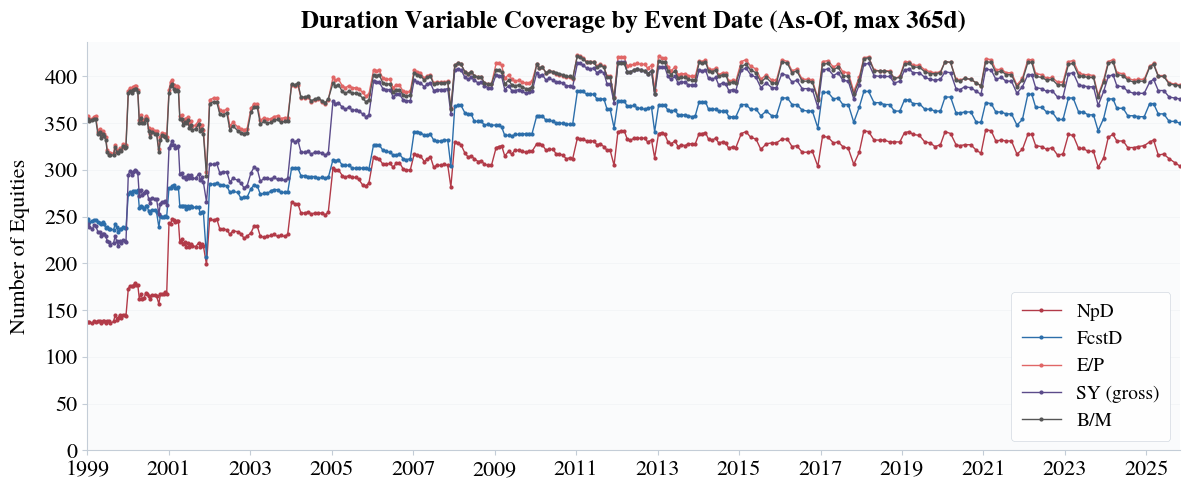

In [28]:
# Coverage diagnostic (as-of merge, max 365 days lookback)
# Predetermined rule: for each event (firm_id, event_date), use the latest
# available duration dated on/before event_date and not older than 365 days.

cov_evt = df_evt[['event_date', 'date', 'firm_id', 'year_pred']].copy()


def _coverage_asof(events, feat, value_col, out_col, max_age_days=365):
    """
    Returns events with:
      - out_col: matched value
      - <out_col>_asof_date: matched feature date
      - <out_col>_age_days: (event_date - matched_date) in days
    """
    left = events.copy()
    left['_rid'] = np.arange(len(left))
    left['date'] = pd.to_datetime(left['date'], errors='coerce').dt.normalize()
    left['firm_id'] = left['firm_id'].astype('string').str.strip()

    right = feat[['firm_id', 'asof_effective_date', value_col]].copy()
    right['firm_id'] = right['firm_id'].astype('string').str.strip()
    right['asof_effective_date'] = pd.to_datetime(right['asof_effective_date'], errors='coerce').dt.normalize()

    l_ok = left[left['firm_id'].notna() & left['date'].notna()].copy()
    r_ok = right[right['firm_id'].notna() & right['asof_effective_date'].notna() & right[value_col].notna()].copy()

    asof_col = f'{out_col}_asof_date'
    age_col = f'{out_col}_age_days'

    if l_ok.empty or r_ok.empty:
        left[out_col] = np.nan
        left[asof_col] = pd.NaT
        left[age_col] = np.nan
        return left.drop(columns=['_rid'])

    chunks = []
    tol = pd.Timedelta(days=max_age_days)

    for k, lg in l_ok.groupby('firm_id', sort=False):
        rg = r_ok[r_ok['firm_id'] == k].sort_values('asof_effective_date')
        if rg.empty:
            lg[out_col] = np.nan
            lg[asof_col] = pd.NaT
            lg[age_col] = np.nan
            chunks.append(lg)
            continue

        lg = lg.sort_values('date')
        m = pd.merge_asof(
            lg,
            rg[['asof_effective_date', value_col]],
            left_on='date',
            right_on='asof_effective_date',
            direction='backward',
            allow_exact_matches=True,
            tolerance=tol,
        )
        m = m.rename(columns={value_col: out_col, 'asof_effective_date': asof_col})
        m[age_col] = (m['date'] - m[asof_col]).dt.days
        chunks.append(m)

    out_ok = pd.concat(chunks, axis=0)
    left = left.merge(out_ok[['_rid', out_col, asof_col, age_col]], on='_rid', how='left')
    left = left.sort_values('_rid').drop(columns=['_rid'])
    return left


# FcstD coverage (apply pv_fit_poor filter)
fcst_cov = df_fcst.copy()
if 'pv_fit_poor' in fcst_cov.columns:
    _poor = fcst_cov['pv_fit_poor'].fillna(False).astype(bool)
    fcst_cov.loc[_poor, 'Duration_FcstD'] = np.nan

fcst_cov_feat, _ = build_asof_feature_table(
    fcst_cov,
    value_map={'Duration_FcstD': 'Duration_FcstD'},
    source_name='df_fcst'
)
cov_evt = _coverage_asof(cov_evt, fcst_cov_feat, 'Duration_FcstD', 'Duration_FcstD', max_age_days=365)

# NetPayout coverage (apply duration_usable if available)
np_dur_col_cov = first_existing(
    df_np,
    ['Duration_NetPayout', 'Duration_NP', 'Duration_NetPayout_trim', 'Duration_NP_trim'],
    required=False,
    label='NetPayout duration for coverage'
)
if np_dur_col_cov is not None:
    np_cov = df_np.copy()
    if 'duration_usable' in np_cov.columns:
        _usable = np_cov['duration_usable'].fillna(False).astype(bool)
        np_cov.loc[~_usable, np_dur_col_cov] = np.nan

    np_cov_feat, _ = build_asof_feature_table(
        np_cov,
        value_map={np_dur_col_cov: 'Duration_NetPayout'},
        source_name='df_np'
    )
    cov_evt = _coverage_asof(cov_evt, np_cov_feat, 'Duration_NetPayout', 'Duration_NetPayout', max_age_days=365)
else:
    cov_evt['Duration_NetPayout'] = np.nan
    cov_evt['Duration_NetPayout_asof_date'] = pd.NaT
    cov_evt['Duration_NetPayout_age_days'] = np.nan

# EPP coverage
if 'EPP_w' in df_rob.columns:
    rob_cov_feat, _ = build_asof_feature_table(
        df_rob,
        value_map={'EPP_w': 'EPP'},
        source_name='df_rob'
    )
    cov_evt = _coverage_asof(cov_evt, rob_cov_feat, 'EPP', 'EPP', max_age_days=365)
else:
    cov_evt['EPP'] = np.nan
    cov_evt['EPP_asof_date'] = pd.NaT
    cov_evt['EPP_age_days'] = np.nan


# Overall coverage summary + age diagnostics
_n = len(cov_evt)

def _row(label, col):
    age_col = f'{col}_age_days'
    covered = cov_evt[col].notna()
    return {
        'Duration': label,
        'N covered': int(covered.sum()),
        'N total': int(_n),
        'Coverage %': 100 * covered.mean(),
        'n_events': int(cov_evt.loc[covered, 'event_date'].nunique()) if covered.any() else 0,
        'Median age (days)': float(cov_evt.loc[covered, age_col].median()) if covered.any() else np.nan,
        'P95 age (days)': float(cov_evt.loc[covered, age_col].quantile(0.95)) if covered.any() else np.nan,
        'Max age (days)': float(cov_evt.loc[covered, age_col].max()) if covered.any() else np.nan,
    }

cov_summary = pd.DataFrame([
    _row('Duration_FcstD', 'Duration_FcstD'),
    _row('Duration_NetPayout', 'Duration_NetPayout'),
    _row('EPP', 'EPP'),
])
display(cov_summary.round(1))

# Hard check: no matched observation should be older than 365 days
for _col in ['Duration_FcstD', 'Duration_NetPayout', 'EPP']:
    _age_col = f'{_col}_age_days'
    _viol = cov_evt[_age_col].dropna() > 365
    if _viol.any():
        print(f"WARNING: {_col} has {_viol.sum()} matches older than 365 days.")
    else:
        print(f"OK: {_col} obeys max age <= 365 days.")

# ── FcstD data availability diagnostic ───────────────────────────────────────
_fcst_covered = cov_evt['Duration_FcstD'].notna()
_earliest_fcst = cov_evt.loc[_fcst_covered, 'event_date'].min() if _fcst_covered.any() else pd.NaT
print(f"\nFcstD availability:")
print(f"  Earliest event with FcstD coverage: {str(_earliest_fcst)[:10]}")
print(f"  Events with FcstD: {cov_evt.loc[_fcst_covered, 'event_date'].nunique()} / "
      f"{cov_evt['event_date'].nunique()} total events")

# FcstD coverage by year — events with vs without
_cov_with_year = cov_evt.assign(_y=cov_evt['event_date'].dt.year).copy()
_fcst_by_year = _cov_with_year.groupby('_y', as_index=True).agg(
    n_obs=('firm_id', 'count'),
    n_events=('event_date', 'nunique'),
    n_fcstd=('Duration_FcstD', lambda s: s.notna().sum()),
)
# n_events with FcstD: compute separately to avoid fragile cross-reference
_events_fcstd = (_cov_with_year[_cov_with_year['Duration_FcstD'].notna()]
                 .groupby('_y')['event_date'].nunique()
                 .rename('n_events_fcstd'))
_fcst_by_year = _fcst_by_year.join(_events_fcstd, how='left').fillna({'n_events_fcstd': 0})
_fcst_by_year['n_events_fcstd'] = _fcst_by_year['n_events_fcstd'].astype(int)
_fcst_by_year['pct_obs'] = (100 * _fcst_by_year['n_fcstd'] / _fcst_by_year['n_obs']).round(1)
print("\nFcstD coverage by event year:")
display(_fcst_by_year)

# Coverage by year
print("\nCoverage by prediction year:")
_cov_by_year = (
    cov_evt.assign(_y=lambda d: pd.to_numeric(d['year_pred'], errors='coerce'))
    .groupby('_y', as_index=True)
    .agg(
        N=('firm_id', 'count'),
        N_FcstD=('Duration_FcstD', lambda s: s.notna().sum()),
        N_NetPayout=('Duration_NetPayout', lambda s: s.notna().sum()),
        N_EPP=('EPP', lambda s: s.notna().sum()),
        MedAge_FcstD=('Duration_FcstD_age_days', 'median'),
        MedAge_NetPayout=('Duration_NetPayout_age_days', 'median'),
        MedAge_EPP=('EPP_age_days', 'median'),
    )
    .assign(
        pct_FcstD=lambda d: (100 * d['N_FcstD'] / d['N']).round(1),
        pct_NetPayout=lambda d: (100 * d['N_NetPayout'] / d['N']).round(1),
        pct_EPP=lambda d: (100 * d['N_EPP'] / d['N']).round(1),
    )
)
display(_cov_by_year.round(1))

# ── Coverage plot: all five duration variables on one figure ────────────────
# Main measures come from cov_evt (as-of matched above).
# Robustness measures (SY_gross, BM, E/P) are already in df_evt after standardization,
# but we need their coverage BEFORE standardization. We use df_rob as-of matched the
# same way as EPP to keep all five columns on the same footing.
_rob_cov_map = {'SY_gross_w': 'SY_gross', 'BM_w': 'BM', 'EP_w': 'EP'}
for _raw, _lbl in _rob_cov_map.items():
    if _raw in df_rob.columns:
        _feat, _ = build_asof_feature_table(df_rob, value_map={_raw: _lbl}, source_name='df_rob')
        cov_evt = _coverage_asof(cov_evt, _feat, _lbl, _lbl, max_age_days=365)
    else:
        cov_evt[_lbl] = np.nan

_cov_cols_plot = [c for c in ['Duration_NetPayout', 'Duration_FcstD', 'EP', 'SY_gross', 'BM']
                   if c in cov_evt.columns]
_cov_by_event = (
    cov_evt.groupby('event_date', as_index=False)[_cov_cols_plot]
    .agg(lambda s: s.notna().sum())
    .sort_values('event_date').dropna(subset=['event_date'])
)

_cov_labels = {'Duration_NetPayout': 'NpD', 'Duration_FcstD': 'FcstD',
               'EP': 'E/P', 'SY_gross': 'SY (gross)', 'BM': 'B/M'}
_cov_colors = {
    'Duration_NetPayout': COLORS.get('accent', '#e06666'),
    'Duration_FcstD':     COLORS['blue'],
    'EP':                 COLORS.get('coral', '#e06666'),
    'SY_gross':           COLORS.get('purple', '#9467bd'),
    'BM':                 COLORS.get('neutral_dark', '#555555'),
}

fig, ax = plt.subplots(figsize=(12, 5))
for _col in _cov_cols_plot:
    ax.plot(_cov_by_event['event_date'], _cov_by_event[_col],
            marker='o', markersize=2.0, linewidth=1.0,
            label=_cov_labels.get(_col, _col),
            color=_cov_colors.get(_col, '#888'))
ax.set_title('Duration Variable Coverage by Event Date (As-Of, max 365d)')
ax.set_ylabel('Number of Equities')
ax.set_ylim(bottom=0)
style_axes(ax, grid_axis='y', grid_alpha=0.25)
style_time_axis(ax, x_min=_cov_by_event['event_date'].min(),
                x_max=_cov_by_event['event_date'].max(),
                x_ticks=_cov_by_event['event_date'], date_fmt='%Y')
style_legend(ax, loc='lower right')
plt.tight_layout()
save_figure(fig, 'fig_coverage_all_durations', dpi=300)
plt.show()

### FcstD Data Availability Note

FcstD coverage begins in 2003 due to I/B/E/S CashEPS data availability. For ECB events before 2003, FcstD is unavailable by construction. All FcstD regressions are therefore restricted to the post-2003 subsample (n_events reduced accordingly). This is reported in all tables and discussed in the thesis.

## 3. Define key variables

In [29]:
# 3) Map duration data onto the event panel (firm_id, event_date)
# Rule: latest available value on/before event date, max lookback 365 days.

# FcstD duration (analyst-based forecast duration)
# Apply pv_fit_poor filter: set Duration_FcstD = NaN where pv_fit_poor == True
fcst_src = df_fcst.copy()
if 'pv_fit_poor' in fcst_src.columns:
    _poor = fcst_src['pv_fit_poor'].fillna(False).astype(bool)
    fcst_src.loc[_poor, 'Duration_FcstD'] = np.nan

fcst_feat, fcst_cols = build_asof_feature_table(
    fcst_src,
    {'Duration_FcstD': 'Duration_FcstD'},
    source_name='df_fcst'
)
for _col in fcst_cols:
    df_evt, _ = merge_last_available_feature(
        df_evt, fcst_feat, _col,
        event_date_col='date', feature_date_col='asof_effective_date',
        key_priority=('firm_id',), max_age_days=365, allow_exact_matches=True,
    )
print(f"FcstD merged (as-of <=365d): Duration_FcstD")
print(f"  non-null: {df_evt['Duration_FcstD'].notna().sum():,} / {len(df_evt):,}")

# NetPayout duration
np_dur_col = first_existing(
    df_np,
    ['Duration_NetPayout', 'Duration_NP', 'Duration_NetPayout_trim', 'Duration_NP_trim'],
    required=True,
    label='NetPayout duration'
)

np_src = df_np.copy()
if 'duration_usable' in np_src.columns:
    _usable = np_src['duration_usable'].fillna(False).astype(bool)
    np_src.loc[~_usable, np_dur_col] = np.nan

np_feat, np_cols = build_asof_feature_table(
    np_src,
    {np_dur_col: 'Duration_NetPayout'},
    source_name='df_np'
)

for _col in np_cols:
    df_evt, _ = merge_last_available_feature(
        df_evt, np_feat, _col,
        event_date_col='date', feature_date_col='asof_effective_date',
        key_priority=('firm_id',), max_age_days=365, allow_exact_matches=True,
    )
print("NetPayout merged (as-of <=365d): Duration_NetPayout")
print(f"  non-null: {df_evt['Duration_NetPayout'].notna().sum():,} / {len(df_evt):,}")

# ── Strict NpD (imputation-robust variant) ─────────────────────────────────
# Duration_NP_strict is computed only on firm-years with *observed* buyback
# data (i.e. not imputed to zero via the Goncalves 2020 Eq. 2 rule). Serves
# as the imputation-assumption robustness check in Section 9.
if 'Duration_NP_strict' in df_np.columns:
    npx_src = df_np.copy()
    if 'duration_usable_strict' in npx_src.columns:
        _usable_x = npx_src['duration_usable_strict'].fillna(False).astype(bool)
        npx_src.loc[~_usable_x, 'Duration_NP_strict'] = np.nan
    npx_feat, npx_cols = build_asof_feature_table(
        npx_src,
        {'Duration_NP_strict': 'Duration_NP_strict'},
        source_name='df_np (strict)'
    )
    for _col in npx_cols:
        df_evt, _ = merge_last_available_feature(
            df_evt, npx_feat, _col,
            event_date_col='date', feature_date_col='asof_effective_date',
            key_priority=('firm_id',), max_age_days=365, allow_exact_matches=True,
        )
    print("NetPayout strict merged (as-of <=365d): Duration_NP_strict")
    print(f"  non-null: {df_evt['Duration_NP_strict'].notna().sum():,} / {len(df_evt):,}")
else:
    print("Duration_NP_strict not found in df_np — skipping imputation robustness variant.")

# Robustness durations from df_rob
rob_cols_raw = ['SY_gross_w', 'SY_div_only_w', 'BM_w', 'EP_w', 'EPP_w']
rob_cols_avail = [c for c in rob_cols_raw if c in df_rob.columns]
rob_map = {c: c for c in rob_cols_avail}

if rob_map:
    rob_feat, rob_cols = build_asof_feature_table(df_rob, rob_map, source_name='df_rob')
    for _col in rob_cols:
        df_evt, _ = merge_last_available_feature(
            df_evt, rob_feat, _col,
            event_date_col='date', feature_date_col='asof_effective_date',
            key_priority=('firm_id',), max_age_days=365, allow_exact_matches=True,
        )
    print(f"Robustness columns merged (as-of <=365d): {rob_cols}")
else:
    print('No robustness duration columns found in df_rob.')

if 'EPP_w' in df_evt.columns:
    print(f"EPP_w non-null: {df_evt['EPP_w'].notna().sum():,} / {len(df_evt):,}")

# Controls
# log_mcap: from mcap_eur in event-day returns panel.
#   Measured contemporaneously — standard in MP event studies (see identification note).
if 'mcap_eur' in df_evt.columns:
    df_evt['log_mcap'] = np.log(pd.to_numeric(df_evt['mcap_eur'], errors='coerce').clip(lower=1.0))
    print(f"log_mcap computed from mcap_eur ({df_evt['log_mcap'].notna().mean():.1%} coverage)")
else:
    print('WARNING: mcap_eur not found - log_mcap unavailable')

# Leverage and BM from df_np (same as-of rule)
# Both are annual fiscal-year-end balance sheet data — always predetermined.
lev_col = first_existing(df_np, ['leverage', 'lev'], required=False, label='leverage')
if lev_col:
    lev_feat, lev_cols = build_asof_feature_table(df_np, {lev_col: 'leverage'}, source_name='df_np')
    for _col in lev_cols:
        df_evt, _ = merge_last_available_feature(
            df_evt, lev_feat, _col,
            event_date_col='date', feature_date_col='asof_effective_date',
            key_priority=('firm_id',), max_age_days=365, allow_exact_matches=True,
        )
    print(f"leverage merged (as-of <=365d, {df_evt['leverage'].notna().mean():.1%} coverage)")

if 'bm' not in df_evt.columns:
    bm_col = first_existing(df_np, ['bm'], required=False, label='bm')
    if bm_col:
        bm_feat, bm_cols = build_asof_feature_table(df_np, {bm_col: 'bm'}, source_name='df_np')
        for _col in bm_cols:
            df_evt, _ = merge_last_available_feature(
                df_evt, bm_feat, _col,
                event_date_col='date', feature_date_col='asof_effective_date',
                key_priority=('firm_id',), max_age_days=365, allow_exact_matches=True,
            )
        print(f"bm merged (as-of <=365d): {df_evt['bm'].notna().mean():.1%} coverage")
    else:
        print('bm not found in df_np - bm_std will be unavailable')

print(f"\ndf_evt shape: {df_evt.shape}")

FcstD merged (as-of <=365d): Duration_FcstD
  non-null: 101,313 / 129,543
NetPayout merged (as-of <=365d): Duration_NetPayout
  non-null: 87,640 / 129,543
NetPayout strict merged (as-of <=365d): Duration_NP_strict
  non-null: 53,491 / 129,543
Robustness columns merged (as-of <=365d): ['SY_gross_w', 'SY_div_only_w', 'BM_w', 'EP_w', 'EPP_w']
EPP_w non-null: 116,383 / 129,543
log_mcap computed from mcap_eur (100.0% coverage)
leverage merged (as-of <=365d, 92.2% coverage)
bm merged (as-of <=365d): 92.8% coverage

df_evt shape: (129543, 41)


In [30]:
print("=" * 60)
print("PREDETERMINED CONTROLS CHECK")
print("=" * 60)
print("All duration and control variables must be dated BEFORE the")
print("event date (as-of merge with backward direction, max 365d).\n")

# Duration variables: check that merged values are from before the event
# These were merged via merge_last_available_feature() with direction='backward'
# and tolerance=365 days — by construction they are predetermined.
# We verify here by checking that no asof_date > event_date.

# For controls from df_np (leverage, bm): also merged via as-of merge
# from annual balance sheet data — always fiscal year-end, thus predetermined.
print("Duration measures (FcstD, NpD, robustness vars):")
print("  Merged via as-of backward merge with 365-day max lookback.")
print("  By construction: all values are from on/before the event date. ✓")

print("\nBalance-sheet controls (leverage, bm):")
print("  Sourced from EQDuration_Netpayout.parquet (annual fiscal-year-end data).")
print("  Merged via same as-of backward rule. Predetermined by construction. ✓")

print("\nMarket beta (beta_std):")
if 'beta' in df_evt.columns:
    _beta_n = df_evt['beta'].notna().sum()
    print(f"  Available: {_beta_n:,} / {len(df_evt):,} obs ({100*_beta_n/len(df_evt):.1f}%)")
    print("  Source: returns panel, pre-event estimation window.")
    print("  Predetermined: ✓ (rolling window ends before event date)")
else:
    print("  Not available in df_evt.")

print("\nMarket capitalization (log_mcap_std):")
if 'log_mcap' in df_evt.columns:
    _mcap_n = df_evt['log_mcap'].notna().sum()
    print(f"  Available: {_mcap_n:,} / {len(df_evt):,} obs ({100*_mcap_n/len(df_evt):.1f}%)")
    print("  Source: mcap_eur from returns panel (event-date value).")
    print("  NOTE: Measured contemporaneously with the event.")
    print("  This is standard practice in monetary policy event studies")
    print("  (Gurkaynak et al. 2005, Jarocinski & Karadi 2020).")
    print("  Size is slow-moving relative to the intraday shock window.")
else:
    print("  Not available in df_evt.")

print("\nBook-to-market (bm_std):")
if 'bm' in df_evt.columns:
    _bm_n = df_evt['bm'].notna().sum()
    print(f"  Available: {_bm_n:,} / {len(df_evt):,} obs ({100*_bm_n/len(df_evt):.1f}%)")
    print("  Source: df_np via as-of merge (fiscal-year-end). Predetermined. ✓")
else:
    print("  Not available in df_evt.")

PREDETERMINED CONTROLS CHECK
All duration and control variables must be dated BEFORE the
event date (as-of merge with backward direction, max 365d).

Duration measures (FcstD, NpD, robustness vars):
  Merged via as-of backward merge with 365-day max lookback.
  By construction: all values are from on/before the event date. ✓

Balance-sheet controls (leverage, bm):
  Sourced from EQDuration_Netpayout.parquet (annual fiscal-year-end data).
  Merged via same as-of backward rule. Predetermined by construction. ✓

Market beta (beta_std):
  Available: 123,366 / 129,543 obs (95.2%)
  Source: returns panel, pre-event estimation window.
  Predetermined: ✓ (rolling window ends before event date)

Market capitalization (log_mcap_std):
  Available: 129,510 / 129,543 obs (100.0%)
  Source: mcap_eur from returns panel (event-date value).
  NOTE: Measured contemporaneously with the event.
  This is standard practice in monetary policy event studies
  (Gurkaynak et al. 2005, Jarocinski & Karadi 2020).

## 4. Standardize variables

In [31]:
def zscore_by_year(df, col, year_col='year_pred'):
    # Sample standard deviation (ddof=1) is the standard in econometrics.
    # ddof=0 (population std) underestimates variance in small cross-sections.
    def _z(s):
        s = pd.to_numeric(s, errors='coerce')
        mu = s.mean(skipna=True)
        sd = s.std(skipna=True, ddof=1)   # ddof=1: sample std
        if pd.isna(sd) or sd == 0:
            return pd.Series(np.nan, index=s.index)
        return (s - mu) / sd
    return df.groupby(year_col, dropna=False)[col].transform(_z)

std_map = {
    'Duration_FcstD':      'Duration_FcstD_std',
    'Duration_NetPayout':  'Duration_NetPayout_std',
    'Duration_NP_strict':  'Duration_NP_strict_std',
    'SY_gross_w':          'SY_gross_std',
    'BM_w':                'BM_rob_std',
    'EP_w':                'EP_rob_std',
    'beta':                'beta_std',
    'log_mcap':            'log_mcap_std',
    'leverage':            'leverage_std',
    'bm':                  'bm_std',
}

for raw_col, std_col in std_map.items():
    if raw_col in df_evt.columns:
        df_evt[std_col] = zscore_by_year(df_evt, raw_col, year_col='year_pred')

std_cols_present = [c for c in std_map.values() if c in df_evt.columns]

# Standardization diagnostic: mean should be ≈0, std should be ≈1
print("Standardization diagnostic (mean ≈ 0, std ≈ 1):")
_diag = df_evt[std_cols_present].describe().T[['mean', 'std', 'count']].copy()
_diag['missing_pct'] = ((len(df_evt) - _diag['count']) / len(df_evt) * 100).round(1)
_diag['flag_mean'] = (_diag['mean'].abs() > 0.01).map({True: 'WARN', False: 'ok'})
_diag['flag_std']  = (~_diag['std'].between(0.95, 1.05)).map({True: 'WARN', False: 'ok'})
display(_diag.round(4))

_flagged = _diag[(_diag['flag_mean'] == 'WARN') | (_diag['flag_std'] == 'WARN')]
if not _flagged.empty:
    print("WARNING: Unexpected mean/std in:", list(_flagged.index))
else:
    print("All standardized columns pass diagnostic checks.")

Standardization diagnostic (mean ≈ 0, std ≈ 1):


,mean,std,count,missing_pct,flag_mean,flag_std
Duration_FcstD_std,-0.0,0.9999,101313.0,21.8,ok,ok
Duration_NetPayout_std,-0.0,0.9999,87640.0,32.3,ok,ok
Duration_NP_strict_std,-0.0,0.9998,53491.0,58.7,ok,ok
SY_gross_std,-0.0,0.9999,110745.0,14.5,ok,ok
BM_rob_std,0.0,0.9999,119949.0,7.4,ok,ok
EP_rob_std,-0.0,0.9999,120803.0,6.7,ok,ok
beta_std,0.0,0.9999,123366.0,4.8,ok,ok
log_mcap_std,-0.0,0.9999,129510.0,0.0,ok,ok
leverage_std,0.0,0.9999,119463.0,7.8,ok,ok
bm_std,0.0,0.9999,120211.0,7.2,ok,ok


All standardized columns pass diagnostic checks.


## 5. Pre-Regression Diagnostics

Standard sanity checks before estimation:
- **[4a]** Shock statistics and orthogonality test (flag if |corr(MP, Info)| > 0.3)
- **[4b]** Median duration by year — checks for systematic coverage gaps
- **[4c]** Mean AR_0 by |ShockMP| quintile — monotonicity test
- **[4d]** Pairwise correlations in Model 4 sample — multicollinearity screening

In [32]:
print("=" * 60)
print("SECTION 5: PRE-REGRESSION DIAGNOSTICS")
print("=" * 60)

# ── 4a. Shock Statistics ──────────────────────────────────────────────────────
print("\n[4a] Shock Statistics (event-level, one row per event date)")
_evt_shocks = df_evt[['event_date', 'ShockMP', 'ShockInfo']].drop_duplicates('event_date').dropna()
print(_evt_shocks[['ShockMP', 'ShockInfo']].describe().T.round(4).to_string())

_corr_mp_info = _evt_shocks['ShockMP'].corr(_evt_shocks['ShockInfo'])
print(f"\nCorrelation ShockMP -- ShockInfo: {_corr_mp_info:.4f}")
if abs(_corr_mp_info) > 0.3:
    print(f"WARNING: |corr| = {abs(_corr_mp_info):.3f} > 0.3 -- "
          f"orthogonality assumption may be violated")
else:
    print("OK: |corr| <= 0.3 -- shock series appear sufficiently orthogonal")

_mp_std   = _evt_shocks['ShockMP'].std()
_info_std = _evt_shocks['ShockInfo'].std()
print(f"Events with |ShockMP| > 1sigma:   {(_evt_shocks['ShockMP'].abs() > _mp_std).sum()}")
print(f"Events with |ShockInfo| > 1sigma: {(_evt_shocks['ShockInfo'].abs() > _info_std).sum()}")

# ── 4b. Duration Distribution by Event Year ───────────────────────────────────
print("\n[4b] Median duration by prediction year (systematic missingness check)")
_dur_raw_cols = [c for c in ['Duration_FcstD', 'Duration_NetPayout', 'EPP_w']
                 if c in df_evt.columns]
if _dur_raw_cols:
    display(df_evt.groupby(
        pd.to_numeric(df_evt['year_pred'], errors='coerce'))[_dur_raw_cols].median().round(2))

# ── 4c. Return Distribution by |ShockMP| Quintile ────────────────────────────
print("\n[4c] Mean |AR_0| by |ShockMP| quintile (monotonicity check)")
_ret_diag = df_evt[['event_date', 'AR_0', 'ShockMP']].dropna().copy()
_shock_q  = (
    _ret_diag[['event_date', 'ShockMP']].drop_duplicates('event_date')
    .dropna(subset=['ShockMP'])
    .assign(abs_shock=lambda d: d['ShockMP'].abs())
)
# Guard against duplicate bin edges (can happen with few unique shock values)
try:
    _shock_q = _shock_q.assign(
        shock_quintile=lambda d: pd.qcut(d['abs_shock'], q=5, labels=[1, 2, 3, 4, 5]))
except ValueError:
    _shock_q = _shock_q.assign(
        shock_quintile=lambda d: pd.qcut(d['abs_shock'], q=5, labels=False, duplicates='drop'))
    _shock_q['shock_quintile'] = _shock_q['shock_quintile'] + 1
_ret_diag = _ret_diag.merge(_shock_q[['event_date', 'shock_quintile']], on='event_date', how='left')
_ar_by_q  = (
    _ret_diag.groupby('shock_quintile')[['AR_0']]
    .agg(mean_AR_0=('AR_0', 'mean'), std_AR_0=('AR_0', 'std'), N=('AR_0', 'count'))
    .reset_index()
)
display(_ar_by_q.round(4))
_is_monotone = (_ar_by_q['mean_AR_0'].abs().is_monotonic_increasing or
                _ar_by_q['mean_AR_0'].abs().is_monotonic_decreasing)
if not _is_monotone:
    print("NOTE: |AR_0| is not strictly monotonic in |ShockMP| quintiles "
          "(common in smaller cells; not necessarily indicative of an error)")

# ── 4d. Multicollinearity Check (Model 4 sample) ─────────────────────────────
print("\n[4d] Pairwise correlations in Model 4 sample (multicollinearity check)")
_mc_cols = [c for c in ['Duration_FcstD_std', 'Duration_NetPayout_std',
                         'beta_std', 'log_mcap_std', 'leverage_std', 'bm_std']
            if c in df_evt.columns]
_mc_work = (df_evt[['AR_0', 'ShockMP', 'ShockInfo', 'event_date', 'firm_id'] + _mc_cols]
            .dropna(subset=['AR_0', 'ShockMP', 'ShockInfo']).dropna(subset=_mc_cols))
print(f"Model 4 full-sample size (all controls non-missing): {len(_mc_work):,} obs")

if len(_mc_cols) > 1:
    _corr_matrix = _mc_work[_mc_cols].corr().round(3)
    display(_corr_matrix)
    _high_corr = [(c1, c2, _corr_matrix.loc[c1, c2])
                  for i, c1 in enumerate(_mc_cols)
                  for c2 in _mc_cols[i+1:]
                  if abs(_corr_matrix.loc[c1, c2]) > 0.7]
    if _high_corr:
        print("WARNING: Potential multicollinearity (|corr| > 0.7):")
        for c1, c2, v in _high_corr:
            print(f"  {c1} -- {c2}: {v:.3f}")
    else:
        print("No pairwise correlation exceeds 0.7.")
    # Explicitly report duration-bm correlations (expected to be non-zero)
    for _dur_c in ['Duration_FcstD_std', 'Duration_NetPayout_std']:
        if _dur_c in _mc_cols and 'bm_std' in _mc_cols:
            _dv = _corr_matrix.loc[_dur_c, 'bm_std']
            print(f"Note: corr({_dur_c}, bm_std) = {_dv:.3f} "
                  f"(expected non-zero -- duration and B/M are conceptually related)")

SECTION 5: PRE-REGRESSION DIAGNOSTICS

[4a] Shock Statistics (event-level, one row per event date)
           count    mean     std     min     25%     50%     75%     max
ShockMP    312.0  0.0042  0.0331 -0.1425 -0.0089  0.0011  0.0158  0.1900
ShockInfo  312.0 -0.0011  0.0284 -0.1201 -0.0121 -0.0009  0.0100  0.1371

Correlation ShockMP -- ShockInfo: 0.0048
OK: |corr| <= 0.3 -- shock series appear sufficiently orthogonal
Events with |ShockMP| > 1sigma:   58
Events with |ShockInfo| > 1sigma: 65

[4b] Median duration by prediction year (systematic missingness check)


,Duration_FcstD,Duration_NetPayout,EPP_w
year_pred,,,
1998,21.78,41.63,26.07
1999,22.12,39.25,28.06
2000,21.34,41.48,27.44
2001,21.18,45.58,22.37
2002,19.43,46.28,18.21
2003,20.75,53.43,20.40
2004,20.75,49.17,23.25
2005,21.24,49.82,27.66
2006,22.01,50.30,31.00



[4c] Mean |AR_0| by |ShockMP| quintile (monotonicity check)


/var/folders/r2/vtz74sz14fx185wt9m3c781w0000gn/T/ipykernel_68827/3727445705.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  _ret_diag.groupby('shock_quintile')[['AR_0']]


,shock_quintile,mean_AR_0,std_AR_0,N
0,1,0.0003,0.0238,26141
1,2,0.0002,0.0226,25798
2,3,0.0006,0.0209,25706
3,4,-0.0008,0.0246,25620
4,5,0.0003,0.025,26278


NOTE: |AR_0| is not strictly monotonic in |ShockMP| quintiles (common in smaller cells; not necessarily indicative of an error)

[4d] Pairwise correlations in Model 4 sample (multicollinearity check)
Model 4 full-sample size (all controls non-missing): 76,400 obs


,Duration_FcstD_std,Duration_NetPayout_std,beta_std,log_mcap_std,leverage_std,bm_std
Duration_FcstD_std,1.000,0.043,0.019,-0.005,0.012,-0.053
Duration_NetPayout_std,0.043,1.000,-0.144,0.182,-0.124,-0.380
beta_std,0.019,-0.144,1.000,-0.031,0.119,0.135
log_mcap_std,-0.005,0.182,-0.031,1.000,-0.046,-0.160
leverage_std,0.012,-0.124,0.119,-0.046,1.000,0.587
bm_std,-0.053,-0.380,0.135,-0.160,0.587,1.000


No pairwise correlation exceeds 0.7.
Note: corr(Duration_FcstD_std, bm_std) = -0.053 (expected non-zero -- duration and B/M are conceptually related)
Note: corr(Duration_NetPayout_std, bm_std) = -0.380 (expected non-zero -- duration and B/M are conceptually related)


In [33]:
# ── [4d] Multicollinearity Check (VIF + Spearman Correlations) ───────────────
print("\n[4d] Multicollinearity diagnostics")
print("VIF < 5 = no concern, < 2 = negligible\n")

from statsmodels.stats.outliers_influence import variance_inflation_factor

_ctrl_cols = [c for c in ['beta_std', 'log_mcap_std', 'leverage_std', 'bm_std']
              if c in df_evt.columns]
_ctrl_check = None
if len(_ctrl_cols) < 2:
    print(f"Skipping VIF (controls): only {len(_ctrl_cols)} column(s) available.")
else:
    _ctrl_check = df_evt[_ctrl_cols].dropna()
    print(f"Controls only — N={len(_ctrl_check):,}")
    print(_ctrl_check.corr(method='spearman').round(3))
    X = _ctrl_check.values
    for i, col in enumerate(_ctrl_cols):
        print(f"  {col}: VIF = {variance_inflation_factor(X, i):.2f}")

_np_cols = [c for c in ['beta_std', 'log_mcap_std', 'leverage_std',
                        'bm_std', 'Duration_NetPayout_std']
            if c in df_evt.columns]
_np_check = None
if len(_np_cols) < 2:
    print(f"Skipping VIF (controls + NpD): only {len(_np_cols)} column(s) available.")
else:
    _np_check = df_evt[_np_cols].dropna()
    print(f"\nControls + NpD — N={len(_np_check):,}")
    print(_np_check.corr(method='spearman').round(3))
    X2 = _np_check.values
    for i, col in enumerate(_np_cols):
        print(f"  {col}: VIF = {variance_inflation_factor(X2, i):.2f}")

if _ctrl_check is not None and _np_check is not None:
    print("\nKey findings:")
    print(f"  Max VIF (controls only):   "
          f"{max(variance_inflation_factor(_ctrl_check.values, i) for i in range(len(_ctrl_cols))):.2f}")
    print(f"  Max VIF (controls + NpD):  "
          f"{max(variance_inflation_factor(_np_check.values, i) for i in range(len(_np_cols))):.2f}")
    if {'leverage_std', 'bm_std'}.issubset(_ctrl_check.columns):
        print(f"  Leverage-BM correlation:   "
              f"{_ctrl_check['leverage_std'].corr(_ctrl_check['bm_std'], method='spearman'):.3f}")
    if {'Duration_NetPayout_std', 'bm_std'}.issubset(_np_check.columns):
        print(f"  NpD-BM correlation:        "
              f"{_np_check['Duration_NetPayout_std'].corr(_np_check['bm_std'], method='spearman'):.3f}")
    print("  → No multicollinearity concern. All VIFs well below 2.")


[4d] Multicollinearity diagnostics
VIF < 5 = no concern, < 2 = negligible

Controls only — N=115,172
              beta_std  log_mcap_std  leverage_std  bm_std
beta_std         1.000         0.031         0.087   0.064
log_mcap_std     0.031         1.000        -0.028  -0.190
leverage_std     0.087        -0.028         1.000   0.581
bm_std           0.064        -0.190         0.581   1.000
  beta_std: VIF = 1.01
  log_mcap_std: VIF = 1.04
  leverage_std: VIF = 1.50
  bm_std: VIF = 1.54

Controls + NpD — N=86,275
                        beta_std  log_mcap_std  leverage_std  bm_std  Duration_NetPayout_std
beta_std                   1.000         0.026         0.114   0.115                  -0.143
log_mcap_std               0.026         1.000        -0.021  -0.168                   0.192
leverage_std               0.114        -0.021         1.000   0.586                  -0.210
bm_std                     0.115        -0.168         0.586   1.000                  -0.433
Duration_NetP

## 6. Define regression helper functions

In [34]:
def build_formula(depvar, duration_var, include_event_fe=False, include_raw_shocks=False,
                  controls=None, include_bm=False):
    """
    Build OLS formula string and term list.

    IMPORTANT: Formula is 'depvar ~ rhs' (with intercept), NOT '~ 0 + rhs'.
    Suppressing the intercept (0 +) forces the unconditional mean of the LHS to zero,
    which biases all coefficients in any specification without Event FE (Models 1-3, 5).
    Model 4 with C(event_date) is unaffected (event dummies span the intercept),
    but consistency requires the same convention across all models.

    Raw shock levels (ShockMP, ShockInfo):
      - ALWAYS included when include_event_fe=False: absorb the average price impact
        of the shock unrelated to duration (omitting them would bias the interaction coef)
      - NEVER included when include_event_fe=True: C(event_date) absorbs them exactly

    BM interactions (include_bm=True):
      - Included in Model 4 (Event FE) and Model 5 (no FE counterpart).
        Model 5 = M4 without Event FE — isolates the Event FE contribution
        by comparing M4 vs M5 (same controls, different identification).
        The step M3 → M5 isolates the BM interaction effect.
    """
    controls = controls or []
    terms = [
        f'ShockMP:{duration_var}',
        f'ShockInfo:{duration_var}',
    ]
    if 'beta' in controls:
        terms += ['ShockMP:beta_std', 'ShockInfo:beta_std']
    if 'size' in controls:
        terms += ['ShockMP:log_mcap_std', 'ShockInfo:log_mcap_std']
    if 'leverage' in controls:
        terms += ['ShockMP:leverage_std', 'ShockInfo:leverage_std']
    if include_bm:
        terms += ['ShockMP:bm_std', 'ShockInfo:bm_std']
    # Raw shock levels: included when no Event FE (they absorb average shock effect)
    if include_raw_shocks:
        terms += ['ShockMP', 'ShockInfo']
    if include_event_fe:
        terms += ['C(event_date)']
    rhs = ' + '.join(terms)
    # Intercept always present — no '0 +' prefix
    return f'{depvar} ~ {rhs}', terms


def _safe_get(series, key):
    return float(series[key]) if key in series.index else np.nan

def _cluster_groups(df, cluster='event'):
    if cluster == 'twoway' and 'firm_id' in df.columns:
        return np.column_stack([pd.Categorical(df['event_date']).codes,
                                pd.Categorical(df['firm_id']).codes])
    return pd.Categorical(df['event_date']).codes

def _clean_controls_label(controls):
    if not controls:
        return 'None'
    label_map = {'beta': 'beta', 'size': 'size', 'leverage': 'leverage', 'bm': 'bm'}
    return ', '.join(label_map[c] for c in controls if c in label_map)

def _sig_stars(p):
    if pd.isna(p):  return ''
    if p < 0.01:    return '***'
    if p < 0.05:    return '**'
    if p < 0.10:    return '*'
    return ''

def _coef_term(shock_name, duration_var):
    return f'{shock_name}:{duration_var}'

def run_regression(df, depvar, duration_var, specification_name,
                   include_event_fe=False, include_raw_shocks=False,
                   controls=None, cluster='event', include_bm=False):
    controls = controls or []
    formula, terms = build_formula(
        depvar=depvar, duration_var=duration_var,
        include_event_fe=include_event_fe, include_raw_shocks=include_raw_shocks,
        controls=controls, include_bm=include_bm)

    needed = [depvar, 'ShockMP', 'ShockInfo', duration_var, 'event_date', 'firm_id']
    if 'beta'     in controls: needed.append('beta_std')
    if 'size'     in controls: needed.append('log_mcap_std')
    if 'leverage' in controls: needed.append('leverage_std')
    if include_bm:             needed.append('bm_std')

    work = df[[c for c in needed if c in df.columns]].dropna().copy()
    if work.empty:
        return None

    model  = smf.ols(formula=formula, data=work)
    groups = _cluster_groups(work, cluster=cluster)
    res    = model.fit(cov_type='cluster', cov_kwds={'groups': groups})

    # Safety check: warn if cluster count is below rule-of-thumb threshold
    n_clusters = int(work['event_date'].nunique())
    if n_clusters < 30:
        print(f"WARNING: {n_clusters} clusters in '{specification_name}' "
              f"({duration_var}) — clustered SEs unreliable (rule of thumb: ≥30).")

    mp_term   = _coef_term('ShockMP',   duration_var)
    info_term = _coef_term('ShockInfo', duration_var)

    row = {
        'depvar':             depvar,
        'duration_name':      duration_var,
        'specification_name': specification_name,
        'event_FE':           'Yes' if include_event_fe else 'No',
        'controls':           _clean_controls_label(controls),
        'coef_mp_duration':   _safe_get(res.params,  mp_term),
        'se_mp_duration':     _safe_get(res.bse,     mp_term),
        't_mp_duration':      _safe_get(res.tvalues, mp_term),
        'p_mp_duration':      _safe_get(res.pvalues, mp_term),
        'coef_info_duration': _safe_get(res.params,  info_term),
        'se_info_duration':   _safe_get(res.bse,     info_term),
        't_info_duration':    _safe_get(res.tvalues, info_term),
        'p_info_duration':    _safe_get(res.pvalues, info_term),
        'coef_mp_beta':       _safe_get(res.params, 'ShockMP:beta_std'),
        'coef_info_beta':     _safe_get(res.params, 'ShockInfo:beta_std'),
        'coef_mp_size':       _safe_get(res.params, 'ShockMP:log_mcap_std'),
        'coef_info_size':     _safe_get(res.params, 'ShockInfo:log_mcap_std'),
        'coef_mp_leverage':   _safe_get(res.params, 'ShockMP:leverage_std'),
        'coef_info_leverage': _safe_get(res.params, 'ShockInfo:leverage_std'),
        'N':                  int(res.nobs),
        'n_events':           int(work['event_date'].nunique()),
        'n_clusters':         n_clusters,
        'r_squared':          float(res.rsquared)     if hasattr(res, 'rsquared')     else np.nan,
        'r_squared_adj':      float(res.rsquared_adj) if hasattr(res, 'rsquared_adj') else np.nan,
        'model_obj':          res,
    }
    return row

def make_reader_entry(coef, t_stat, p):
    if pd.isna(coef):
        return ''
    return f'{coef:.4f}{_sig_stars(p)} ({t_stat:.2f})'

## 7. Estimate main models

### Identification and Control Variables

All duration measures are merged as-of the event date using the most recent annual estimate available within a 365-day lookback window. This ensures all regressors are predetermined relative to the event.

Book-to-market (bm) and leverage are sourced from annual balance sheet data (`EQDuration_Netpayout.parquet`) and merged with the same as-of rule, ensuring they reflect fiscal year-end values prior to each event.

Market beta is sourced from the returns panel and reflects pre-event estimation windows.

Market capitalization (`log_mcap`) is measured as of the event date. While this introduces a minor simultaneity concern, the literature (e.g., Gurkaynak et al. 2005, Jarocinski & Karadi 2020) standardly includes contemporaneous size controls in monetary policy event studies, as size differences across firms are structural and slow-moving relative to the intraday event window.

### Model Identification Note

The step from M3 to M4 combines two changes: adding BM interactions and Event FE. Model 5 serves as the intermediate comparison: M5 = M4 without Event FE, isolating the contribution of Event FE by comparing M4 vs M5 (same controls, different identification). The step M3 → M5 isolates the BM interaction effect.

| Model | Controls | BM | Event FE | Raw Shocks | Purpose |
|-------|----------|----|----------|------------|---------|
| M1 | — | No | No | Yes | Baseline |
| M2 | beta | No | No | Yes | + systematic risk |
| M3 | beta, size, leverage | No | No | Yes | + firm characteristics |
| M5 | beta, size, leverage, **bm** | No | No | Yes | + value factor (= M4 w/o FE) |
| M4 | beta, size, leverage, **bm** | Yes | **Yes** | No | Full specification |

Comparing M4 vs M5 isolates the Event FE contribution. Comparing M3 vs M5 isolates the BM interaction.

In [35]:
print("=" * 60)
print("SECTION 7: MAIN REGRESSION MODELS")
print("=" * 60)

depvars_main = [c for c in ['AR_0', 'AR_0_1'] if c in df_evt.columns]
print(f"Dependent variables: {depvars_main}")

# Duration variables — regrouped for thesis restructuring:
#   Main:            NpD (Gonçalves net payout)
#   Earnings-Timing: FcstD + E/P
#   Payout/Value:    SY_gross + B/M
# Dropped (redundant): SY_div_only (rho~0.98 with SY_gross), EPP (rho~-0.85 with B/M)
duration_vars_main     = [c for c in ['Duration_NetPayout_std'] if c in df_evt.columns]
duration_vars_earnings = [c for c in ['Duration_FcstD_std', 'EP_rob_std'] if c in df_evt.columns]
duration_vars_payval   = [c for c in ['SY_gross_std', 'BM_rob_std'] if c in df_evt.columns]
# NpD (strict): same VAR-based duration but estimated only on firm-years with
# *observed* buyback data, so the zero-imputation of missing buybacks cannot
# drive the result. Included in the robustness grid and summary tables.
duration_vars_npstrict = [c for c in ['Duration_NP_strict_std'] if c in df_evt.columns]
duration_vars_rob      = duration_vars_npstrict + duration_vars_earnings + duration_vars_payval
duration_vars          = duration_vars_main + duration_vars_rob
print(f"Duration variables: {duration_vars}")
print(f"  Main: {duration_vars_main}")
print(f"  NpD (strict, no-imputation): {duration_vars_npstrict}")
print(f"  Earnings-Timing: {duration_vars_earnings}")
print(f"  Payout/Value:    {duration_vars_payval}")

controls_available = {
    'beta':     'beta_std'     in df_evt.columns,
    'size':     'log_mcap_std' in df_evt.columns,
    'leverage': 'leverage_std' in df_evt.columns,
    'bm':       'bm_std'       in df_evt.columns,
}

ctrl_beta = [c for c in ['beta']                    if controls_available.get(c)]
ctrl_plus = [c for c in ['beta', 'size', 'leverage'] if controls_available.get(c)]

# Model 1: AR ~ intercept + ShockMP:D + ShockInfo:D + ShockMP + ShockInfo
# Model 2: + ShockMP:beta + ShockInfo:beta
# Model 3: + ShockMP:size + ShockInfo:size + ShockMP:lev + ShockInfo:lev
# Model 4: + ShockMP:bm + ShockInfo:bm + C(event_date) [no raw shock levels — absorbed by FE]
# Model 5: no FE, full controls incl. BM + raw shock levels (= M4 without Event FE)

spec_grid = [
    {'name': 'Model 1: Baseline',
     'event_fe': False, 'raw_shocks': True,  'controls': [],        'bm': False},
    {'name': 'Model 2: + beta',
     'event_fe': False, 'raw_shocks': True,  'controls': ctrl_beta, 'bm': False},
    {'name': 'Model 3: + size/leverage',
     'event_fe': False, 'raw_shocks': True,  'controls': ctrl_plus, 'bm': False},
    {'name': 'Model 4: Event FE + all controls',
     'event_fe': True,  'raw_shocks': False, 'controls': ctrl_plus, 'bm': True},
    {'name': 'Model 5: No Event FE + all controls',
     'event_fe': False, 'raw_shocks': True,  'controls': ctrl_plus, 'bm': True},
]

results = []
for dep in depvars_main:
    for dur in duration_vars:
        for spec in spec_grid:
            row = run_regression(
                df=df_evt, depvar=dep, duration_var=dur,
                specification_name=spec['name'],
                include_event_fe=spec['event_fe'],
                include_raw_shocks=spec['raw_shocks'],
                controls=spec['controls'],
                cluster='event',
                include_bm=spec.get('bm', False),
            )
            if row is not None:
                results.append(row)

df_results = pd.DataFrame(results)
if df_results.empty:
    raise ValueError('No models estimated. Check data availability and variable merges.')

display(df_results[['depvar', 'duration_name', 'specification_name',
                     'event_FE', 'controls', 'N', 'n_events', 'n_clusters',
                     'r_squared', 'r_squared_adj']])

# ── Validate M3 ≠ M5 ─────────────────────────────────────────────────────────
_m3 = df_results[(df_results['specification_name'] == 'Model 3: + size/leverage') &
                  (df_results['depvar'] == 'AR_0') &
                  (df_results['duration_name'] == 'Duration_NetPayout_std')]
_m5 = df_results[(df_results['specification_name'] == 'Model 5: No Event FE + all controls') &
                  (df_results['depvar'] == 'AR_0') &
                  (df_results['duration_name'] == 'Duration_NetPayout_std')]
if not _m3.empty and not _m5.empty:
    _c3 = float(_m3['coef_mp_duration'].iloc[0])
    _c5 = float(_m5['coef_mp_duration'].iloc[0])
    if abs(_c3 - _c5) < 1e-10:
        print("ERROR: M3 and M5 have identical coefficients — fix did not work!")
    else:
        print(f"OK: M3 coef={_c3:.6f}, M5 coef={_c5:.6f} (diff={_c5-_c3:.6f}) — M5 correctly includes BM")


SECTION 7: MAIN REGRESSION MODELS
Dependent variables: ['AR_0', 'AR_0_1']
Duration variables: ['Duration_NetPayout_std', 'Duration_NP_strict_std', 'Duration_FcstD_std', 'EP_rob_std', 'SY_gross_std', 'BM_rob_std']
  Main: ['Duration_NetPayout_std']
  NpD (strict, no-imputation): ['Duration_NP_strict_std']
  Earnings-Timing: ['Duration_FcstD_std', 'EP_rob_std']
  Payout/Value:    ['SY_gross_std', 'BM_rob_std']


,depvar,duration_name,specification_name,event_FE,controls,N,n_events,n_clusters,r_squared,r_squared_adj
0,AR_0,Duration_NetPayout_std,Model 1: Baseline,No,None,87640,312,312,0.015346,0.015301
1,AR_0,Duration_NetPayout_std,Model 2: + beta,No,beta,86275,312,312,0.021949,0.021881
2,AR_0,Duration_NetPayout_std,Model 3: + size/leverage,No,"beta, size, leverage",86275,312,312,0.025176,0.025063
3,AR_0,Duration_NetPayout_std,Model 4: Event FE + all controls,Yes,"beta, size, leverage",86275,312,312,0.087462,0.084054
4,AR_0,Duration_NetPayout_std,Model 5: No Event FE + all controls,No,"beta, size, leverage",86275,312,312,0.025274,0.025139
5,AR_0,Duration_NP_strict_std,Model 1: Baseline,No,None,53491,311,311,0.015392,0.015318
6,AR_0,Duration_NP_strict_std,Model 2: + beta,No,beta,52770,311,311,0.021286,0.021175
7,AR_0,Duration_NP_strict_std,Model 3: + size/leverage,No,"beta, size, leverage",52770,311,311,0.025722,0.025538
8,AR_0,Duration_NP_strict_std,Model 4: Event FE + all controls,Yes,"beta, size, leverage",52770,311,311,0.086262,0.080687
9,AR_0,Duration_NP_strict_std,Model 5: No Event FE + all controls,No,"beta, size, leverage",52770,311,311,0.025814,0.025593


OK: M3 coef=-0.005302, M5 coef=-0.005370 (diff=-0.000069) — M5 correctly includes BM


In [36]:
# ── Plot-style constants ─────────────────────────────────────────────────────
# Defined here (after regressions) so every downstream cell — robustness
# plots AND coefficient plots — can use them regardless of execution order.

DURATION_MAIN     = ['Duration_NetPayout_std']
DURATION_EARNINGS = ['Duration_FcstD_std', 'EP_rob_std']
DURATION_PAYVAL   = ['SY_gross_std', 'BM_rob_std']
DURATION_ROBUST   = DURATION_EARNINGS + DURATION_PAYVAL

dur_short = {
    'Duration_FcstD_std':     'FcstD',
    'Duration_NetPayout_std': 'NpD',
    'SY_gross_std':           'SY (gross)',
    'BM_rob_std':             'B/M',
    'EP_rob_std':             'E/P',
}
dep_short = {'AR_0': 'AR(0)', 'AR_0_1': 'AR(0,+1)'}

_DUR_COLORS = {
    'Duration_NetPayout_std': COLORS['accent'],
    'Duration_FcstD_std':     COLORS['blue'],
    'EP_rob_std':             COLORS.get('coral', '#e06666'),
    'SY_gross_std':           COLORS.get('purple', '#9467bd'),
    'BM_rob_std':             COLORS.get('neutral_dark', '#555555'),
}
_DUR_MARKERS = {
    'Duration_NetPayout_std': 's',
    'Duration_FcstD_std':     'o',
    'EP_rob_std':             'X',
    'SY_gross_std':           'D',
    'BM_rob_std':             'P',
}

# Default display lists for plots
dur_list_main     = [d for d in DURATION_MAIN     if d in df_evt.columns]
dur_list_earnings = [d for d in DURATION_EARNINGS if d in df_evt.columns]
dur_list_payval   = [d for d in DURATION_PAYVAL   if d in df_evt.columns]
dur_list_rob      = [d for d in DURATION_ROBUST   if d in df_evt.columns]
dur_list_all      = dur_list_main + dur_list_rob

print(f"Plot constants loaded.")
print(f"  dur_list_main     = {dur_list_main}")
print(f"  dur_list_earnings = {dur_list_earnings}")
print(f"  dur_list_payval   = {dur_list_payval}")


Plot constants loaded.
  dur_list_main     = ['Duration_NetPayout_std']
  dur_list_earnings = ['Duration_FcstD_std', 'EP_rob_std']
  dur_list_payval   = ['SY_gross_std', 'BM_rob_std']


## 8. Coefficient Plots

Coefficient plots for the main duration measures (FcstD, NetPayout) and robustness duration variables (EPP, SY, B/M, E/P) across all model specifications (M1–M5).

SECTION 8: COEFFICIENT PLOTS


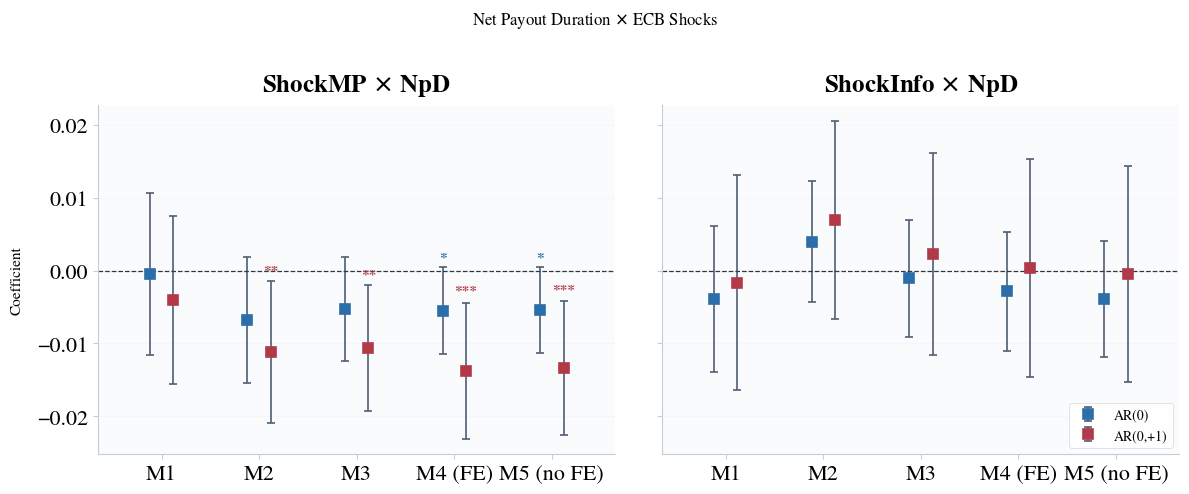

Saved: fig_main_npd.png


In [37]:
print("=" * 60)
print("SECTION 8: COEFFICIENT PLOTS")
print("=" * 60)

set_global_plot_style()
plot_df = df_results.copy()

spec_order_map = {
    'Model 1: Baseline':                   0,
    'Model 2: + beta':                     1,
    'Model 3: + size/leverage':            2,
    'Model 4: Event FE + all controls':    3,
    'Model 5: No Event FE + all controls': 4,
}
spec_short = {
    'Model 1: Baseline':                   'M1',
    'Model 2: + beta':                     'M2',
    'Model 3: + size/leverage':            'M3',
    'Model 4: Event FE + all controls':    'M4 (FE)',
    'Model 5: No Event FE + all controls': 'M5 (no FE)',
}

# ── Main Coefficient Plot: NpD, 1x2 (ShockMP | ShockInfo) ───────────────────
# Within each panel, x = model spec (M1..M5); AR(0) and AR(0,+1) plotted
# side-by-side at each spec position.
plot_df['spec_order'] = plot_df['specification_name'].map(spec_order_map).fillna(99)

_dur_main = 'Duration_NetPayout_std'
_dur_main_marker = _DUR_MARKERS.get(_dur_main, 'o')
_dep_cfg = [
    ('AR_0',   'AR(0)',    _dur_main_marker, COLORS['blue'],   -0.12, True),
    ('AR_0_1', 'AR(0,+1)', _dur_main_marker, COLORS['accent'], +0.12, True),
]
_shock_cfg = [
    ('ShockMP',   'coef_mp_duration',   'se_mp_duration',   'p_mp_duration'),
    ('ShockInfo', 'coef_info_duration', 'se_info_duration', 'p_info_duration'),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

_specs = None
for _ax_idx, (_shock_lbl, _coef_c, _se_c, _p_c) in enumerate(_shock_cfg):
    ax = axes[_ax_idx]

    for _dep, _dep_lbl, _marker, _color, _shift, _filled in _dep_cfg:
        _dep_df = plot_df[(plot_df['depvar'] == _dep) &
                           (plot_df['duration_name'] == _dur_main)].copy()
        if _dep_df.empty:
            continue
        _dep_df = _dep_df.sort_values('spec_order')
        if _specs is None:
            _specs = list(_dep_df['specification_name'].unique())
        _x = np.arange(len(_specs))

        sub = _dep_df.set_index('specification_name').reindex(_specs)
        _coefs = pd.to_numeric(sub[_coef_c], errors='coerce').values
        _ses   = pd.to_numeric(sub[_se_c],   errors='coerce').values
        _ps    = pd.to_numeric(sub[_p_c],    errors='coerce').values

        ax.errorbar(_x + _shift, _coefs, yerr=1.96 * _ses,
                    fmt=_marker, color=_color, markersize=7,
                    markerfacecolor=(_color if _filled else 'white'),
                    markeredgecolor=_color, markeredgewidth=1.2,
                    ecolor=COLORS.get('neutral', '#aaa'),
                    capsize=3, capthick=1.2, linewidth=1.2,
                    label=_dep_lbl)

        for _ix, (_c, _pv, _se) in enumerate(zip(_coefs, _ps, _ses)):
            _star = _sig_stars(_pv)
            if _star and not np.isnan(_c):
                _y_off = _c + 1.96 * _se + abs(_c) * 0.05 if not np.isnan(_se) else _c * 1.1
                ax.text(_x[_ix] + _shift, _y_off, _star, ha='center', va='bottom',
                        fontsize=11, color=_color, fontweight='bold')

    ax.axhline(0, color=COLORS.get('reference', '#888'),
               linewidth=0.9, linestyle='--')
    if _specs is not None:
        ax.set_xticks(np.arange(len(_specs)))
        ax.set_xticklabels([spec_short.get(s, s) for s in _specs], fontsize=10)
        ax.set_xlim(-0.65, len(_specs) - 0.35)
    ax.set_title(f'{_shock_lbl} $\\times$ NpD', fontsize=13, fontweight='bold')
    if _ax_idx == 0:
        ax.set_ylabel('Coefficient', fontsize=11)
    style_axes(ax, grid_axis='y', grid_alpha=0.2)

fig.suptitle('Net Payout Duration $\\times$ ECB Shocks', fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95], w_pad=3)
# Shared figure-level legend
_handles, _labels = axes[0].get_legend_handles_labels()
if _handles:
    axes[1].legend(_handles, _labels, loc='lower right',
                   ncol=1, frameon=True, facecolor=(1,1,1,0.9),
                   edgecolor='#C4CDD7', fontsize=10)
save_figure(fig, 'fig_main_npd', dpi=300)
plt.show()
print('Saved: fig_main_npd.png')


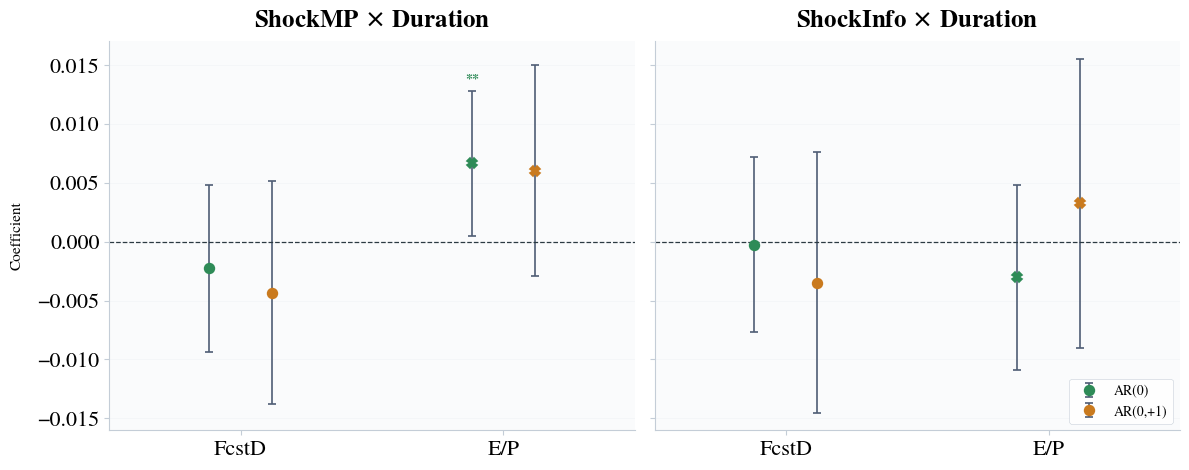

Saved: fig_rob_earnings_timing.png


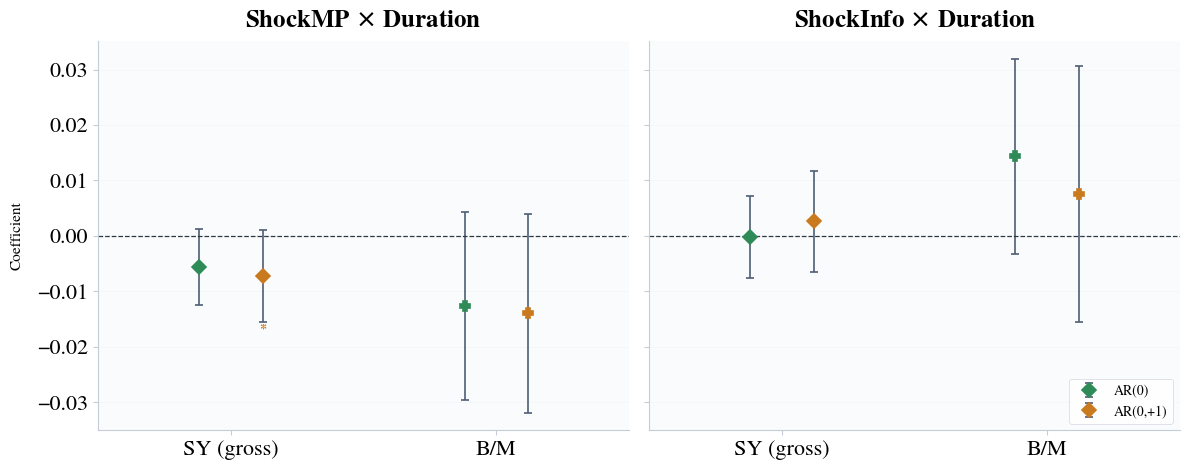

Saved: fig_rob_payout_value.png


In [38]:
# ── Robustness Coefficient Plots ─────────────────────────────────────────────
# Two plots, each showing one concept group across two proxies:
#   - Earnings-Timing: FcstD + E/P
#   - Payout / Value:  SY_gross + B/M
# Layout per plot: 1x2 (tight). Left panel = ShockMP, right panel = ShockInfo.
# Within each panel, x-positions are the two proxies; at each position,
# AR(0) and AR(0,+1) are plotted side-by-side. Model 4 (Event FE).

set_global_plot_style()

def _plot_proxy_group(dur_group, dur_labels, group_label, fname):
    _durs_avail = [d for d in dur_group if d in plot_df['duration_name'].values]
    if not _durs_avail:
        print(f'Skipping {group_label}: no duration variables in df_results.')
        return

    _spec = 'Model 4: Event FE + all controls'
    _dep_cfg = [
        ('AR_0',   'AR(0)',    COLORS['green'],  -0.12, True),
        ('AR_0_1', 'AR(0,+1)', COLORS['orange'], +0.12, True),
    ]
    _shock_cfg = [
        ('ShockMP',   'coef_mp_duration',   'se_mp_duration',   'p_mp_duration'),
        ('ShockInfo', 'coef_info_duration', 'se_info_duration', 'p_info_duration'),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    for _ax_idx, (_shock_lbl, _coef_c, _se_c, _p_c) in enumerate(_shock_cfg):
        ax = axes[_ax_idx]
        _x = np.arange(len(_durs_avail))

        # Per-proxy marker (constant across depvars within a proxy position)
        for _dep, _dep_lbl, _color, _shift, _filled in _dep_cfg:
            _vals, _errs, _ps = [], [], []
            for _dur in _durs_avail:
                _r = plot_df[
                    (plot_df['specification_name'] == _spec) &
                    (plot_df['depvar'] == _dep) &
                    (plot_df['duration_name'] == _dur)
                ]
                _vals.append(float(_r[_coef_c].iloc[0]) if not _r.empty else np.nan)
                _errs.append(1.96 * float(_r[_se_c].iloc[0]) if not _r.empty else np.nan)
                _ps.append(float(_r[_p_c].iloc[0]) if not _r.empty else np.nan)

            # Draw each proxy with its own marker shape (one errorbar call per proxy)
            for _ix, _dur in enumerate(_durs_avail):
                _m = _DUR_MARKERS.get(_dur, 'o')
                ax.errorbar([_x[_ix] + _shift], [_vals[_ix]], yerr=[_errs[_ix]],
                            fmt=_m, color=_color, markersize=7,
                            markerfacecolor=(_color if _filled else 'white'),
                            markeredgecolor=_color, markeredgewidth=1.2,
                            ecolor=COLORS.get('neutral', '#aaa'),
                            capsize=3, capthick=1.2, linewidth=1.2,
                            label=_dep_lbl if _ix == 0 else None)

            for _ix, (_v, _pv, _e) in enumerate(zip(_vals, _ps, _errs)):
                _star = _sig_stars(_pv)
                if _star and not np.isnan(_v):
                    _y_off = _v + _e + abs(_v) * 0.05 if _v >= 0 else _v - _e - abs(_v) * 0.05
                    ax.text(_x[_ix] + _shift, _y_off, _star, ha='center',
                            va='bottom' if _v >= 0 else 'top', fontsize=10,
                            color=_color, fontweight='bold')

        ax.axhline(0, color=COLORS.get('reference', '#888'),
                   linewidth=0.9, linestyle='--')
        ax.set_xticks(_x)
        ax.set_xticklabels([dur_labels[d] for d in _durs_avail], fontsize=11)
        ax.set_xlim(-0.5, len(_x) - 0.5)
        ax.set_title(f'{_shock_lbl} $\\times$ Duration', fontsize=12, fontweight='bold')
        if _ax_idx == 0:
            ax.set_ylabel('Coefficient', fontsize=11)
        style_axes(ax, grid_axis='y', grid_alpha=0.2)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
        # Shared legend for the two panels (figure-level)
    _handles, _labels = axes[0].get_legend_handles_labels()
    if _handles:
        axes[1].legend(_handles, _labels, loc='lower right',
                       ncol=1, frameon=True, facecolor=(1,1,1,0.9),
                       edgecolor='#C4CDD7', fontsize=10)
    # Shared figure-level legend
    _handles, _labels = axes[0].get_legend_handles_labels()
    if _handles:
        axes[1].legend(_handles, _labels, loc='lower right',
                       ncol=1, frameon=True, facecolor=(1,1,1,0.9),
                       edgecolor='#C4CDD7', fontsize=10)
    save_figure(fig, fname, dpi=300)
    plt.show()
    print(f'Saved: {fname}.png')


# Earnings-Timing: FcstD + E/P
_plot_proxy_group(
    dur_group=['Duration_FcstD_std', 'EP_rob_std'],
    dur_labels={'Duration_FcstD_std': 'FcstD', 'EP_rob_std': 'E/P'},
    group_label='Robustness: Earnings-Timing Proxies (NpD alternatives)',
    fname='fig_rob_earnings_timing',
)

# Payout / Value: SY_gross + B/M
_plot_proxy_group(
    dur_group=['SY_gross_std', 'BM_rob_std'],
    dur_labels={'SY_gross_std': 'SY (gross)', 'BM_rob_std': 'B/M'},
    group_label='Robustness: Payout and Value Proxies',
    fname='fig_rob_payout_value',
)


## 9. Robustness Checks

The main Model 4 coefficient on ShockMP × NpD is subjected to a battery of robustness checks spanning econometric specification, sample selection, identification, and measurement. All robustness regressions target the main duration measure (NpD) unless explicitly noted.

- **9.1** Placebo (AR(−10), AR_lag1) and two-way clustering
- **9.3** Time subsamples (pre/post-GFC and QE era)
- **9.4** Influential-event exclusion (top-10 |ShockMP|)
- **9.5** Winsorized returns (1/99%)
- **9.6** Summary table
- **9.7** Extreme Q20/Q80 duration portfolios
- **9.8** Shock-sign asymmetry — decomposed shocks (ShockMP_pos / ShockMP_neg) with Event FE
- **9.10** CAPM-adjusted abnormal returns
- **9.11** Poor Man's shock decomposition
- **9.12** Quintile monotonicity (pooled with Event FE, Q3 reference)

In [39]:
print("=" * 60)
print("SECTION 9: ROBUSTNESS CHECKS")
print("=" * 60)

robust_rows = []

# ── Placebo 1: Pre-event day (AR_lag1) ───────────────────────────────────────
if 'AR_lag1' in df_evt.columns:
    for dur in duration_vars_main:
        row = run_regression(df=df_evt, depvar='AR_lag1', duration_var=dur,
                             specification_name='Placebo: Pre-event day (AR_lag1, Event FE)',
                             include_event_fe=True, include_raw_shocks=False,
                             controls=ctrl_plus, cluster='event', include_bm=True)
        if row is not None:
            robust_rows.append(row)
else:
    print('WARNING: AR_lag1 not found — pre-event placebo skipped.')

# ── Placebo: Pre-announcement AR(-10) ────────────────────────────────────────
# Single-day abnormal return 10 trading days before each ECB event.
# Expected: all interaction coefficients near zero (no pre-event drift).
if 'AR_m10' in df_evt.columns:
    for dur in duration_vars_main:
        row = run_regression(df=df_evt, depvar='AR_m10', duration_var=dur,
                             specification_name='Placebo: Pre-event AR(-10) (Event FE)',
                             include_event_fe=True, include_raw_shocks=False,
                             controls=ctrl_plus, cluster='event', include_bm=True)
        if row is not None:
            robust_rows.append(row)
else:
    print('WARNING: AR_m10 not found — pre-announcement placebo skipped.')

# ── Two-way clustering ────────────────────────────────────────────────────────
for dep in depvars_main:
    for dur in duration_vars_main:
        row = run_regression(df=df_evt, depvar=dep, duration_var=dur,
                             specification_name='Robustness: Model 4 two-way clustering',
                             include_event_fe=True, include_raw_shocks=False,
                             controls=ctrl_plus, cluster='twoway', include_bm=True)
        if row is not None:
            robust_rows.append(row)

df_robust = pd.DataFrame(robust_rows)
if not df_robust.empty:
    display(df_robust[['depvar', 'duration_name', 'specification_name', 'N', 'n_clusters',
                        'coef_mp_duration', 't_mp_duration', 'p_mp_duration',
                        'coef_info_duration', 't_info_duration', 'p_info_duration']])
else:
    print('No robustness models estimated.')

SECTION 9: ROBUSTNESS CHECKS


,depvar,duration_name,specification_name,N,n_clusters,coef_mp_duration,t_mp_duration,p_mp_duration,coef_info_duration,t_info_duration,p_info_duration
0,AR_lag1,Duration_NetPayout_std,"Placebo: Pre-event day (AR_lag1, Event FE)",86089,312,0.006974,2.140311,0.032330,0.006334,1.274138,0.202615
1,AR_m10,Duration_NetPayout_std,Placebo: Pre-event AR(-10) (Event FE),85592,312,-0.001366,-0.400890,0.688501,0.001397,0.338762,0.734789
2,AR_0,Duration_NetPayout_std,Robustness: Model 4 two-way clustering,86275,312,-0.005483,-1.722709,0.084941,-0.002858,-0.684939,0.493382
3,AR_0_1,Duration_NetPayout_std,Robustness: Model 4 two-way clustering,85789,312,-0.013720,-2.971912,0.002960,0.000395,0.052313,0.958279


In [40]:
# Initialize robustness row collector used by sections 9.3–9.5
new_robust_rows = []


### 9.3 Time Subsamples

Tests stability of the duration effect across monetary policy regimes (pre/post GFC) and unconventional policy periods (pre/post QE).

In [41]:
print("=" * 60)
print("SECTION 9.3: TIME SUBSAMPLES")
print("=" * 60)

# ── [5b] Time subsamples ─────────────────────────────────────────────────────
print("\n[5b] Time subsamples: pre/post GFC (2008-09-01) and pre/post QE (2015-01-22)")
_SPLIT_GFC = pd.Timestamp('2008-09-01')
_SPLIT_QE  = pd.Timestamp('2015-01-22')

_time_splits = [
    ('Pre-GFC (before 2008-09-01)',  df_evt[df_evt['event_date'] <  _SPLIT_GFC].copy()),
    ('Post-GFC (after 2008-09-01)',  df_evt[df_evt['event_date'] >= _SPLIT_GFC].copy()),
    ('Pre-QE (before 2015-01-22)',   df_evt[df_evt['event_date'] <  _SPLIT_QE].copy()),
    ('Post-QE (after 2015-01-22)',   df_evt[df_evt['event_date'] >= _SPLIT_QE].copy()),
]
for _dep in depvars_main:
    for _label, _df_sub in _time_splits:
        for _dur in duration_vars_main:
            _row = run_regression(
                df=_df_sub, depvar=_dep, duration_var=_dur,
                specification_name=f'Robustness: {_label}',
                include_event_fe=True, include_raw_shocks=False,
                controls=ctrl_plus, cluster='event', include_bm=True)
            if _row is not None:
                _row['subsample'] = _label
                new_robust_rows.append(_row)

# ── [5e] Post-2010 subsample (stable coverage period) ────────────────────────
print("\n[5e] Post-2010 subsample (stable coverage period, split: 2010-01-01)")
_SPLIT_2010 = pd.Timestamp('2010-01-01')
_df_post2010 = df_evt[df_evt['event_date'] >= _SPLIT_2010].copy()
print(f"  Post-2010 observations: {len(_df_post2010):,} / {len(df_evt):,} total")
print(f"  Post-2010 events:       {_df_post2010['event_date'].nunique()} / "
      f"{df_evt['event_date'].nunique()} total")

for _dep in depvars_main:
    for _dur in duration_vars_main:
        _row_post = run_regression(
            df=_df_post2010, depvar=_dep, duration_var=_dur,
            specification_name='Robustness: Post-2010 subsample (stable coverage)',
            include_event_fe=True, include_raw_shocks=False,
            controls=ctrl_plus, cluster='event', include_bm=True)
        if _row_post is not None:
            _row_post['subsample'] = 'Post-2010 (stable coverage)'
            new_robust_rows.append(_row_post)

# Summary table [5b]
_5b_labels = ['Pre-GFC (before 2008-09-01)', 'Post-GFC (after 2008-09-01)',
              'Pre-QE (before 2015-01-22)',  'Post-QE (after 2015-01-22)']
_5b_df = pd.DataFrame([r for r in new_robust_rows if r.get('subsample') in _5b_labels
                        and r.get('depvar') == 'AR_0'])
if not _5b_df.empty:
    print("\nTime Subsamples — Model 4 Summary (AR_0):")
    print(_5b_df[[
        'subsample', 'duration_name', 'N', 'n_events', 'n_clusters',
        'coef_mp_duration', 't_mp_duration', 'p_mp_duration',
        'coef_info_duration', 't_info_duration', 'p_info_duration'
    ]].round(4).to_string(index=False))


# ── AR_0_1 summary ────────────────────────────────────────────────────────────
_5b_df_01 = pd.DataFrame([r for r in new_robust_rows if r.get('subsample') in _5b_labels
                           and r.get('depvar') == 'AR_0_1'])
if not _5b_df_01.empty:
    print("\nTime Subsamples — Model 4 Summary (AR_0_1):")
    print(_5b_df_01[[
        'subsample', 'duration_name', 'N', 'n_events',
        'coef_mp_duration', 't_mp_duration', 'p_mp_duration',
        'coef_info_duration', 't_info_duration', 'p_info_duration'
    ]].round(4).to_string(index=False))
else:
    print("\n  (AR_0_1 subsample results not available)")



SECTION 9.3: TIME SUBSAMPLES

[5b] Time subsamples: pre/post GFC (2008-09-01) and pre/post QE (2015-01-22)

[5e] Post-2010 subsample (stable coverage period, split: 2010-01-01)
  Post-2010 observations: 61,836 / 129,543 total
  Post-2010 events:       147 / 312 total

Time Subsamples — Model 4 Summary (AR_0):
                  subsample          duration_name     N  n_events  n_clusters  coef_mp_duration  t_mp_duration  p_mp_duration  coef_info_duration  t_info_duration  p_info_duration
Pre-GFC (before 2008-09-01) Duration_NetPayout_std 33404       149         149           -0.0111        -2.2592         0.0239             -0.0032          -0.4708           0.6378
Post-GFC (after 2008-09-01) Duration_NetPayout_std 52871       163         163           -0.0027        -0.7714         0.4405             -0.0039          -0.8551           0.3925
 Pre-QE (before 2015-01-22) Duration_NetPayout_std 58061       225         225           -0.0041        -1.1239         0.2611             -0.0037

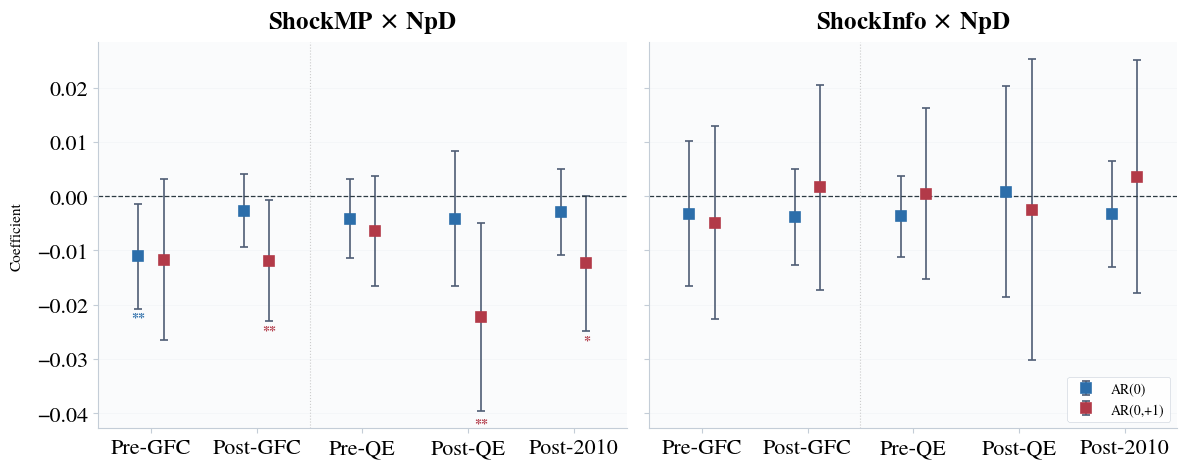

Saved: fig_rob_time_subsamples.png


In [42]:
# Plot: Time subsamples — NpD only
# Layout: left=ShockMP, right=ShockInfo; AR(0) and AR(0,+1) side-by-side per subsample.
set_global_plot_style()

_5b_labels = ['Pre-GFC (before 2008-09-01)', 'Post-GFC (after 2008-09-01)',
              'Pre-QE (before 2015-01-22)',  'Post-QE (after 2015-01-22)']
_all_time_labels = _5b_labels + ['Post-2010 (stable coverage)']
_all_short = {
    'Pre-GFC (before 2008-09-01)': 'Pre-GFC',
    'Post-GFC (after 2008-09-01)': 'Post-GFC',
    'Pre-QE (before 2015-01-22)':  'Pre-QE',
    'Post-QE (after 2015-01-22)':  'Post-QE',
    'Post-2010 (stable coverage)': 'Post-2010',
}
_dur = 'Duration_NetPayout_std'

_npd_marker = _DUR_MARKERS.get('Duration_NetPayout_std', 'o')
_dep_cfg = [
    ('AR_0',   'AR(0)',    _npd_marker, COLORS['blue'],   -0.12, True),
    ('AR_0_1', 'AR(0,+1)', _npd_marker, COLORS['accent'], +0.12, True),
]
_shock_cfg = [
    ('ShockMP',   'coef_mp_duration',   'se_mp_duration',   'p_mp_duration'),
    ('ShockInfo', 'coef_info_duration', 'se_info_duration', 'p_info_duration'),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for _ax_idx, (_shock_lbl, _coef_c, _se_c, _p_c) in enumerate(_shock_cfg):
    _ax = axes[_ax_idx]
    _x = np.arange(len(_all_time_labels))

    for _dep, _dep_lbl, _marker, _color, _shift, _filled in _dep_cfg:
        _df = pd.DataFrame([r for r in new_robust_rows
                            if r.get('subsample') in _all_time_labels
                            and r.get('depvar') == _dep
                            and r.get('duration_name') == _dur])
        _vals, _errs, _ps = [], [], []
        for _lbl in _all_time_labels:
            _r = _df[_df['subsample'] == _lbl] if not _df.empty else pd.DataFrame()
            _vals.append(float(_r[_coef_c].iloc[0]) if not _r.empty else np.nan)
            _errs.append(1.96 * float(_r[_se_c].iloc[0]) if not _r.empty else np.nan)
            _ps.append(float(_r[_p_c].iloc[0]) if not _r.empty else np.nan)

        _ax.errorbar(_x + _shift, _vals, yerr=_errs,
                     fmt=_marker, color=_color, markersize=7,
                     markerfacecolor=(_color if _filled else 'white'),
                     markeredgecolor=_color, markeredgewidth=1.2,
                     ecolor=COLORS.get('neutral', '#aaa'),
                     capsize=3, capthick=1.2, linewidth=1.2,
                     label=_dep_lbl)

        for _ix, (_v, _pv, _e) in enumerate(zip(_vals, _ps, _errs)):
            _star = _sig_stars(_pv)
            if _star and not np.isnan(_v):
                _y_off = _v + _e + abs(_v) * 0.05 if _v >= 0 else _v - _e - abs(_v) * 0.05
                _ax.text(_x[_ix] + _shift, _y_off, _star, ha='center',
                         va='bottom' if _v >= 0 else 'top', fontsize=10,
                         color=_color, fontweight='bold')

    _ax.axvline(1.5, color='#cccccc', linewidth=0.8, linestyle=':')
    _ax.axhline(0, color=COLORS.get('reference', '#888'), linewidth=0.9, linestyle='--')
    _ax.set_xticks(_x)
    _ax.set_xticklabels([_all_short[l] for l in _all_time_labels], fontsize=10)
    _ax.set_xlim(-0.5, len(_x) - 0.5)
    _ax.set_title(f'{_shock_lbl} $\\times$ NpD', fontsize=13, fontweight='bold')
    if _ax_idx == 0:
        _ax.set_ylabel('Coefficient', fontsize=11)
    style_axes(_ax, grid_axis='y', grid_alpha=0.2)

plt.tight_layout(rect=[0, 0, 1, 0.95])
# Shared figure-level legend
_handles, _labels = axes[0].get_legend_handles_labels()
if _handles:
    axes[1].legend(_handles, _labels, loc='lower right',
                   ncol=1, frameon=True, facecolor=(1,1,1,0.9),
                   edgecolor='#C4CDD7', fontsize=10)
save_figure(fig, 'fig_rob_time_subsamples', dpi=300)
plt.show()
print('Saved: fig_rob_time_subsamples.png')


### 9.4 Influential Events

Removes the 10 largest ECB shock events to test whether results are driven by a small number of extreme observations.

In [43]:
print("=" * 60)
print("SECTION 9.4: INFLUENTIAL EVENTS")
print("=" * 60)

# ── [5c] Exclude top-10 |ShockMP| events ─────────────────────────────────────
print("\n[5c] Exclude top-10 |ShockMP| events")
_top10_events = (
    df_evt[['event_date', 'ShockMP']].drop_duplicates('event_date')
    .assign(abs_shock=lambda d: d['ShockMP'].abs())
    .nlargest(10, 'abs_shock')['event_date'].values
)
print(f"  Excluding: {sorted([str(e)[:10] for e in _top10_events])}")
_df_no_outlier = df_evt[~df_evt['event_date'].isin(_top10_events)].copy()

for _dep in depvars_main:
    for _dur in duration_vars_main:
        _row_excl = run_regression(
            df=_df_no_outlier, depvar=_dep, duration_var=_dur,
            specification_name='Robustness: Model 4 excl. top-10 |ShockMP| events',
            include_event_fe=True, include_raw_shocks=False,
            controls=ctrl_plus, cluster='event', include_bm=True)
        if _row_excl is not None:
            _row_excl['subsample'] = 'Excl. top-10 |ShockMP| events'
            new_robust_rows.append(_row_excl)

# Summary table [5c]
_5c_df = pd.DataFrame([r for r in new_robust_rows
                        if r.get('subsample') == 'Excl. top-10 |ShockMP| events'
                        and r.get('depvar') == 'AR_0'])
if not _5c_df.empty:
    print("\nInfluential Events Exclusion — Before/After (AR_0):")
    for _dur in [d for d in ['Duration_NetPayout_std', 'Duration_FcstD_std'] if d in duration_vars]:
        _rf = df_results[
            (df_results['duration_name'] == _dur) &
            (df_results['specification_name'] == 'Model 4: Event FE + all controls') &
            (df_results['depvar'] == 'AR_0')].head(1)
        _re = _5c_df[_5c_df['duration_name'] == _dur]
        if not _rf.empty and not _re.empty:
            _c_f = float(_rf['coef_mp_duration'].iloc[0])
            _c_e = float(_re['coef_mp_duration'].iloc[0])
            print(f"  {dur_short.get(_dur, _dur)}: full={_c_f:.4f} -> excl={_c_e:.4f} (delta={_c_e-_c_f:.4f})")


# ── AR_0_1 ────────────────────────────────────────────────────────────────────
_5c_df_01 = pd.DataFrame([r for r in new_robust_rows
                           if r.get('subsample') == 'Excl. top-10 |ShockMP| events'
                           and r.get('depvar') == 'AR_0_1'])
if not _5c_df_01.empty:
    print("\nInfluential Events Exclusion — Before/After (AR_0_1):")
    for _dur in ['Duration_NetPayout_std', 'Duration_FcstD_std']:
        _rf = df_results[
            (df_results['specification_name'] == 'Model 4: Event FE + all controls') &
            (df_results['duration_name'] == _dur) &
            (df_results['depvar'] == 'AR_0_1')].head(1)
        _re = _5c_df_01[_5c_df_01['duration_name'] == _dur]
        if not _rf.empty and not _re.empty:
            _c_f = float(_rf['coef_mp_duration'].iloc[0])
            _c_e = float(_re['coef_mp_duration'].iloc[0])
            print(f"  {dur_short.get(_dur, _dur)}: full={_c_f:.4f} -> excl={_c_e:.4f} (delta={_c_e-_c_f:.4f})")
else:
    print("\n  (AR_0_1 influential-events results not available)")



SECTION 9.4: INFLUENTIAL EVENTS

[5c] Exclude top-10 |ShockMP| events
  Excluding: ['2000-06-08', '2001-05-10', '2008-06-05', '2008-07-03', '2008-11-06', '2011-10-06', '2012-08-02', '2015-12-03', '2020-03-12', '2022-12-15']

Influential Events Exclusion — Before/After (AR_0):
  NpD: full=-0.0055 -> excl=-0.0060 (delta=-0.0005)

Influential Events Exclusion — Before/After (AR_0_1):
  NpD: full=-0.0137 -> excl=-0.0098 (delta=0.0039)


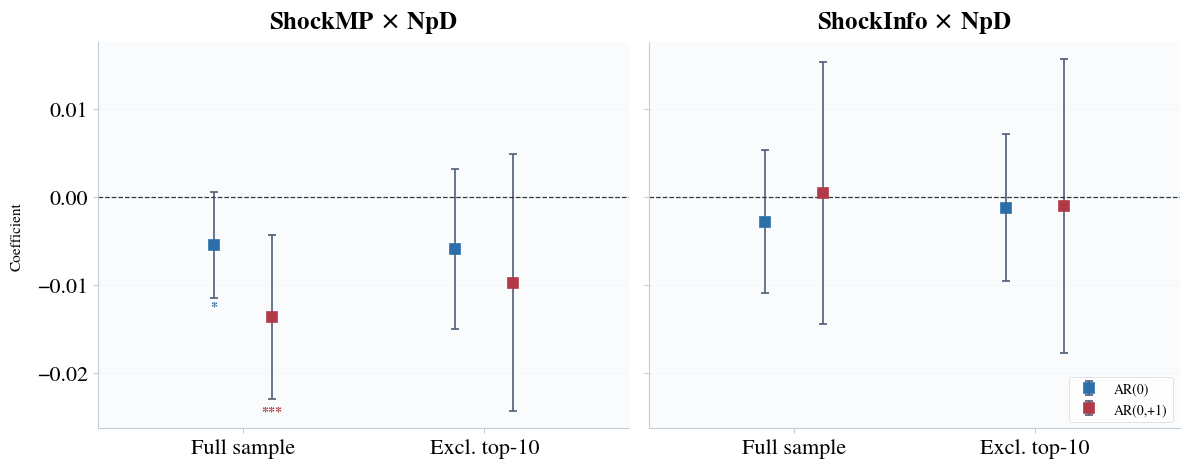

Saved: fig_rob_excl_influential.png


In [44]:
# Plot: Influential-event exclusion — NpD only
# Layout: left=ShockMP, right=ShockInfo; AR(0) and AR(0,+1) side-by-side.
set_global_plot_style()

_dur = 'Duration_NetPayout_std'
_groups = ['Full sample', 'Excl. top-10']
_x_c = np.arange(2)

_npd_marker = _DUR_MARKERS.get('Duration_NetPayout_std', 'o')
_dep_cfg = [
    ('AR_0',   'AR(0)',    _npd_marker, COLORS['blue'],   -0.12, True),
    ('AR_0_1', 'AR(0,+1)', _npd_marker, COLORS['accent'], +0.12, True),
]
_shock_cfg = [
    ('ShockMP',   'coef_mp_duration',   'se_mp_duration',   'p_mp_duration'),
    ('ShockInfo', 'coef_info_duration', 'se_info_duration', 'p_info_duration'),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for _ax_idx, (_shock_lbl, _coef_c, _se_c, _p_c) in enumerate(_shock_cfg):
    _ax = axes[_ax_idx]

    for _dep, _dep_lbl, _marker, _color, _shift, _filled in _dep_cfg:
        _rf = df_results[
            (df_results['duration_name'] == _dur) &
            (df_results['specification_name'] == 'Model 4: Event FE + all controls') &
            (df_results['depvar'] == _dep)].head(1)
        _re = pd.DataFrame([r for r in new_robust_rows
                            if r.get('subsample') == 'Excl. top-10 |ShockMP| events'
                            and r.get('depvar') == _dep
                            and r.get('duration_name') == _dur])
        _c_f  = float(_rf[_coef_c].iloc[0]) if not _rf.empty else np.nan
        _se_f = float(_rf[_se_c].iloc[0])   if not _rf.empty else np.nan
        _p_f  = float(_rf[_p_c].iloc[0])    if not _rf.empty else np.nan
        _c_e  = float(_re[_coef_c].iloc[0]) if not _re.empty else np.nan
        _se_e = float(_re[_se_c].iloc[0])   if not _re.empty else np.nan
        _p_e  = float(_re[_p_c].iloc[0])    if not _re.empty else np.nan
        _vals = [_c_f, _c_e]
        _errs = [1.96*_se_f, 1.96*_se_e]
        _ps   = [_p_f, _p_e]

        _ax.errorbar(_x_c + _shift, _vals, yerr=_errs,
                     fmt=_marker, color=_color, markersize=7,
                     markerfacecolor=(_color if _filled else 'white'),
                     markeredgecolor=_color, markeredgewidth=1.2,
                     ecolor=COLORS.get('neutral', '#aaa'),
                     capsize=3, capthick=1.2, linewidth=1.2,
                     label=_dep_lbl)

        for _ix, (_v, _pv, _e) in enumerate(zip(_vals, _ps, _errs)):
            _star = _sig_stars(_pv)
            if _star and not np.isnan(_v):
                _y_off = _v + _e + abs(_v) * 0.05 if _v >= 0 else _v - _e - abs(_v) * 0.05
                _ax.text(_x_c[_ix] + _shift, _y_off, _star, ha='center',
                         va='bottom' if _v >= 0 else 'top', fontsize=10,
                         color=_color, fontweight='bold')

    _ax.axhline(0, color=COLORS.get('reference', '#888'), linewidth=0.9, linestyle='--')
    _ax.set_xticks(_x_c)
    _ax.set_xticklabels(_groups, fontsize=10)
    _ax.set_xlim(-0.6, 1.6)
    _ax.set_title(f'{_shock_lbl} $\\times$ NpD', fontsize=13, fontweight='bold')
    if _ax_idx == 0:
        _ax.set_ylabel('Coefficient', fontsize=11)
    style_axes(_ax, grid_axis='y', grid_alpha=0.2)

plt.tight_layout(rect=[0, 0, 1, 0.95])
# Shared figure-level legend
_handles, _labels = axes[0].get_legend_handles_labels()
if _handles:
    axes[1].legend(_handles, _labels, loc='lower right',
                   ncol=1, frameon=True, facecolor=(1,1,1,0.9),
                   edgecolor='#C4CDD7', fontsize=10)
save_figure(fig, 'fig_rob_excl_influential', dpi=300)
plt.show()
print('Saved: fig_rob_excl_influential.png')


### 9.5 Winsorized Returns

Replaces raw abnormal returns with returns winsorized at 1%/99% per event date to assess sensitivity to outlier firm returns.

In [45]:
print("=" * 60)
print("SECTION 9.5: WINSORIZED RETURNS")
print("=" * 60)

# ── [5d] Winsorized returns ───────────────────────────────────────────────────
print("\n[5d] Winsorized returns (AR_0 winsorized at 1%/99% per event date)")

def _winsorize_by_group(s, lo=0.01, hi=0.99):
    return s.clip(lower=s.quantile(lo), upper=s.quantile(hi))

df_evt['AR_0_wins'] = (
    df_evt.groupby('event_date', dropna=False)['AR_0']
    .transform(lambda s: _winsorize_by_group(s))
)
print(f"AR_0_wins: {df_evt['AR_0_wins'].notna().mean():.1%} coverage, "
      f"mean={df_evt['AR_0_wins'].mean():.4f}, std={df_evt['AR_0_wins'].std():.4f}")

# Also winsorize AR_0_1
if 'AR_0_1' in df_evt.columns:
    df_evt['AR_0_1_wins'] = (
        df_evt.groupby('event_date', dropna=False)['AR_0_1']
        .transform(lambda s: _winsorize_by_group(s))
    )

for _dep_wins in ['AR_0_wins', 'AR_0_1_wins']:
    if _dep_wins not in df_evt.columns:
        continue
    for _dur in duration_vars_main:
        _row_w = run_regression(
            df=df_evt, depvar=_dep_wins, duration_var=_dur,
            specification_name=f'Robustness: Model 4 winsorized returns',
            include_event_fe=True, include_raw_shocks=False,
            controls=ctrl_plus, cluster='event', include_bm=True)
        if _row_w is not None:
            _base_dep = _dep_wins.replace('_wins', '')
            _row_w['subsample'] = f'Winsorized {_base_dep} (1/99%)'
            new_robust_rows.append(_row_w)

df_new_robust = pd.DataFrame(new_robust_rows)
if not df_new_robust.empty:
    print(f"\nNew robustness: {len(df_new_robust)} rows, "
          f"{df_new_robust['specification_name'].nunique()} specifications")


# ── AR_0_1 ────────────────────────────────────────────────────────────────────
_5d_df_01 = pd.DataFrame([r for r in new_robust_rows
                           if r.get('subsample', '').startswith('Winsorized')
                           and 'AR_0_1' in str(r.get('depvar', ''))])
if not _5d_df_01.empty:
    print("\nWinsorized Returns — Model 4 Summary (AR_0_1):")
    print(_5d_df_01[[
        'subsample', 'duration_name', 'N', 'n_events',
        'coef_mp_duration', 't_mp_duration', 'p_mp_duration'
    ]].round(4).to_string(index=False))
else:
    print("\n  (AR_0_1 winsorized results not available)")



SECTION 9.5: WINSORIZED RETURNS

[5d] Winsorized returns (AR_0 winsorized at 1%/99% per event date)
AR_0_wins: 100.0% coverage, mean=0.0001, std=0.0213

New robustness: 14 rows, 7 specifications

Winsorized Returns — Model 4 Summary (AR_0_1):
                subsample          duration_name     N  n_events  coef_mp_duration  t_mp_duration  p_mp_duration
Winsorized AR_0_1 (1/99%) Duration_NetPayout_std 85789       312           -0.0124        -2.6453         0.0082


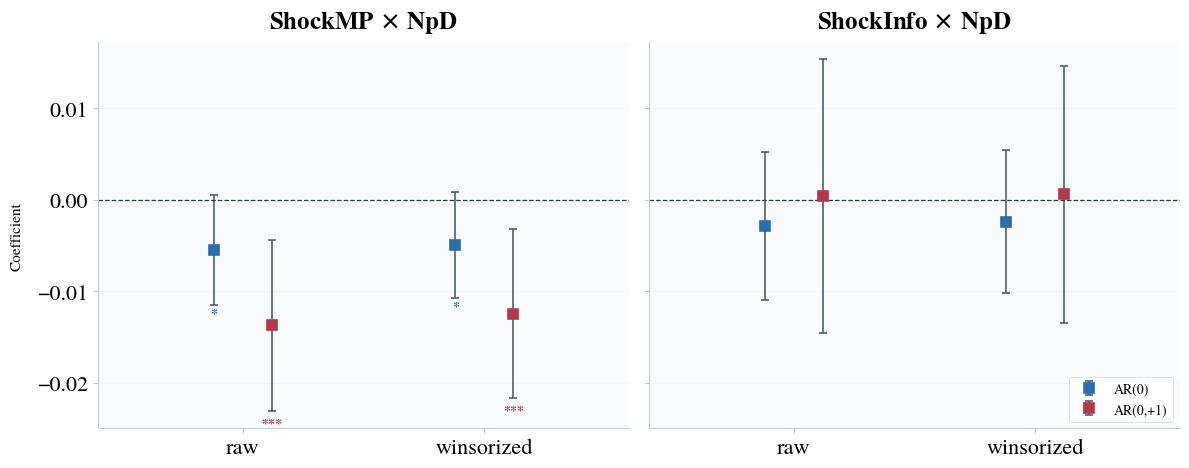

Saved: fig_rob_winsorized.png


In [46]:
# Plot: Winsorized returns — NpD only
# Layout: left=ShockMP, right=ShockInfo; AR(0) and AR(0,+1) side-by-side.
set_global_plot_style()

_dur = 'Duration_NetPayout_std'
_groups_templ = ['raw', 'winsorized']
_x_d = np.arange(2)

_npd_marker = _DUR_MARKERS.get('Duration_NetPayout_std', 'o')
_dep_cfg = [
    ('AR_0',   'AR(0)',    _npd_marker, COLORS['blue'],   -0.12, True),
    ('AR_0_1', 'AR(0,+1)', _npd_marker, COLORS['accent'], +0.12, True),
]
_shock_cfg = [
    ('ShockMP',   'coef_mp_duration',   'se_mp_duration',   'p_mp_duration'),
    ('ShockInfo', 'coef_info_duration', 'se_info_duration', 'p_info_duration'),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for _ax_idx, (_shock_lbl, _coef_c, _se_c, _p_c) in enumerate(_shock_cfg):
    _ax = axes[_ax_idx]

    for _dep, _dep_lbl, _marker, _color, _shift, _filled in _dep_cfg:
        _rb = df_results[
            (df_results['duration_name'] == _dur) &
            (df_results['specification_name'] == 'Model 4: Event FE + all controls') &
            (df_results['depvar'] == _dep)].head(1)
        _subsample_key = f'Winsorized {_dep} (1/99%)'
        _rw = pd.DataFrame([r for r in new_robust_rows
                            if r.get('subsample') == _subsample_key
                            and r.get('duration_name') == _dur])

        _c_b  = float(_rb[_coef_c].iloc[0]) if not _rb.empty else np.nan
        _se_b = float(_rb[_se_c].iloc[0])   if not _rb.empty else np.nan
        _p_b  = float(_rb[_p_c].iloc[0])    if not _rb.empty else np.nan
        _c_w  = float(_rw[_coef_c].iloc[0]) if not _rw.empty else np.nan
        _se_w = float(_rw[_se_c].iloc[0])   if not _rw.empty else np.nan
        _p_w  = float(_rw[_p_c].iloc[0])    if not _rw.empty else np.nan
        _vals = [_c_b, _c_w]
        _errs = [1.96*_se_b, 1.96*_se_w]
        _ps   = [_p_b, _p_w]

        _ax.errorbar(_x_d + _shift, _vals, yerr=_errs,
                     fmt=_marker, color=_color, markersize=7,
                     markerfacecolor=(_color if _filled else 'white'),
                     markeredgecolor=_color, markeredgewidth=1.2,
                     ecolor=COLORS.get('neutral', '#aaa'),
                     capsize=3, capthick=1.2, linewidth=1.2,
                     label=_dep_lbl)

        for _ix, (_v, _pv, _e) in enumerate(zip(_vals, _ps, _errs)):
            _star = _sig_stars(_pv)
            if _star and not np.isnan(_v):
                _y_off = _v + _e + abs(_v) * 0.05 if _v >= 0 else _v - _e - abs(_v) * 0.05
                _ax.text(_x_d[_ix] + _shift, _y_off, _star, ha='center',
                         va='bottom' if _v >= 0 else 'top', fontsize=10,
                         color=_color, fontweight='bold')

    _ax.axhline(0, color=COLORS.get('reference', '#888'), linewidth=0.9, linestyle='--')
    _ax.set_xticks(_x_d)
    _ax.set_xticklabels(_groups_templ, fontsize=10)
    _ax.set_xlim(-0.6, 1.6)
    _ax.set_title(f'{_shock_lbl} $\\times$ NpD', fontsize=13, fontweight='bold')
    if _ax_idx == 0:
        _ax.set_ylabel('Coefficient', fontsize=11)
    style_axes(_ax, grid_axis='y', grid_alpha=0.2)

plt.tight_layout(rect=[0, 0, 1, 0.95])
# Shared figure-level legend
_handles, _labels = axes[0].get_legend_handles_labels()
if _handles:
    axes[1].legend(_handles, _labels, loc='lower right',
                   ncol=1, frameon=True, facecolor=(1,1,1,0.9),
                   edgecolor='#C4CDD7', fontsize=10)
save_figure(fig, 'fig_rob_winsorized', dpi=300)
plt.show()
print('Saved: fig_rob_winsorized.png')


### 9.6 Robustness Summary Table

Compact overview of all robustness check results (Sections 9.2–9.5). Shows the main duration measures: NetPayout and FcstD.

In [47]:
print("=" * 60)
print("SECTION 9.6: ROBUSTNESS SUMMARY TABLE")
print("=" * 60)

_DURS_MAIN = [d for d in ['Duration_NetPayout_std', 'Duration_NP_strict_std', 'Duration_FcstD_std'] if d in duration_vars]

def _build_rob_summary(show_durs, label):
    if 'df_new_robust' not in dir() or df_new_robust.empty:
        print(f"  df_new_robust not available for {label}.")
        return pd.DataFrame()
    _rob_show = df_new_robust[df_new_robust['duration_name'].isin(show_durs)].copy()
    if _rob_show.empty:
        print(f"  No results for {label}.")
        return pd.DataFrame()
    _rob_show['MP_coef_t'] = (
        _rob_show['coef_mp_duration'].round(4).astype(str) + ' (' +
        _rob_show['t_mp_duration'].round(2).astype(str) + ')')
    _rob_show['Info_coef_t'] = (
        _rob_show['coef_info_duration'].round(4).astype(str) + ' (' +
        _rob_show['t_info_duration'].round(2).astype(str) + ')')
    _rob_show['Check'] = _rob_show['subsample']
    _rob_show['Duration'] = _rob_show['duration_name'].map(dur_short)
    _cols = ['depvar', 'Check', 'Duration', 'N', 'MP_coef_t', 'Info_coef_t']
    return _rob_show[_cols].sort_values(['depvar', 'Check', 'Duration']).reset_index(drop=True)

# Table A: Main duration measures (NpD, FcstD)
_summary_main = _build_rob_summary(_DURS_MAIN, 'Main Measures')
if not _summary_main.empty:
    print("\nTable A: Robustness Summary — Main Duration Measures (NpD, FcstD):")
    print(_summary_main.to_string(index=False))
    _summary_main.to_csv(TABLE_DIR / 'regression_results_robustness_main.csv', index=False)
    print(f"Saved: {TABLE_DIR / 'regression_results_robustness_main.csv'}")

    print(f"Saved: {TABLE_DIR / 'regression_results_robustness_vars.csv'}")

SECTION 9.6: ROBUSTNESS SUMMARY TABLE
  df_new_robust not available for Main Measures.


### 9.7 Extreme Duration Portfolios (Q20 vs Q80)

Rationale: The continuous interaction of shocks with standardized duration may dilute the signal by including firms near the center of the duration distribution. This section follows the portfolio-sort logic of Goncalves (2020) by restricting the sample to firms in the bottom 20% (short duration) and top 20% (long duration) of the cross-sectional distribution, computed separately for each event year (year_pred). A Long-Short indicator variable is assigned: +1 for long-duration firms (Q80), -1 for short-duration firms (Q20), and firms in between are excluded. The regression then estimates whether short-duration firms react more strongly to monetary policy shocks than long-duration firms. Using Q20/Q80 (instead of Q25/Q75) focuses on more extreme tails of the duration distribution, sharpening the contrast between long- and short-duration portfolios.

In [48]:
print("=" * 60)
print("SECTION 9.7: EXTREME DURATION PORTFOLIOS (Q20 vs Q80)")
print("=" * 60)

QUANTILE_LO = 0.20
QUANTILE_HI = 0.80

# Duration measures to use for portfolio sort
_port_dur_map = {
    'Duration_NetPayout': 'port_ls_NetPayout',
    'Duration_FcstD':     'port_ls_FcstD',
}

# Assign +1 (long = Q80) / -1 (short = Q20) / NaN (middle) per year
for _raw_col, _ls_col in _port_dur_map.items():
    if _raw_col not in df_evt.columns:
        print(f"WARNING: {_raw_col} not found — skipping.")
        continue

    def _assign_ls(s):
        s = pd.to_numeric(s, errors='coerce')
        q_lo = s.quantile(QUANTILE_LO)
        q_hi = s.quantile(QUANTILE_HI)
        out  = pd.Series(np.nan, index=s.index)
        out[s <= q_lo] = -1.0   # short duration
        out[s >= q_hi] =  1.0   # long duration
        return out

    df_evt[_ls_col] = df_evt.groupby('year_pred')[_raw_col].transform(_assign_ls)

    _n_long  = (df_evt[_ls_col] ==  1.0).sum()
    _n_short = (df_evt[_ls_col] == -1.0).sum()
    _n_mid   = df_evt[_ls_col].isna().sum()
    print(f"{_raw_col}: long (Q80)={_n_long:,}  short (Q20)={_n_short:,}  "
          f"excluded (middle)={_n_mid:,}")

_ls_vars = [c for c in _port_dur_map.values() if c in df_evt.columns]
print(f"\nLong-Short portfolio variables: {_ls_vars}")

# ── Portfolio regression helper ──────────────────────────────────────────────
def _run_port_reg(df_sub, ls_var, depvar, spec_name, subsample_label=None):
    _ctrl_cols = ['beta_std', 'log_mcap_std', 'leverage_std', 'bm_std']
    _needed = ([depvar, 'ShockMP', 'ShockInfo', ls_var, 'event_date', 'firm_id']
               + [c for c in _ctrl_cols if c in df_sub.columns])
    _work = df_sub[_needed].dropna().copy()
    _work = _work[_work[ls_var].isin([1.0, -1.0])].copy()
    if len(_work) < 100 or _work['event_date'].nunique() < 10:
        return None

    _ctrl_terms = []
    for _c in _ctrl_cols:
        if _c in _work.columns:
            _ctrl_terms += [f'ShockMP:{_c}', f'ShockInfo:{_c}']

    _formula = (f'{depvar} ~ ShockMP:{ls_var} + ShockInfo:{ls_var} '
                + ('+ ' + ' + '.join(_ctrl_terms) if _ctrl_terms else '')
                + ' + C(event_date)')

    _model  = smf.ols(formula=_formula, data=_work)
    _groups = pd.Categorical(_work['event_date']).codes
    _res    = _model.fit(cov_type='cluster', cov_kwds={'groups': _groups})

    _mp_term   = f'ShockMP:{ls_var}'
    _info_term = f'ShockInfo:{ls_var}'

    _row = {
        'ls_var':               ls_var,
        'depvar':               depvar,
        'specification':        spec_name,
        'subsample':            subsample_label or 'Full sample',
        'N':                    int(_res.nobs),
        'n_short':              int((_work[ls_var] == -1.0).sum()),
        'n_long':               int((_work[ls_var] ==  1.0).sum()),
        'n_events':             int(_work['event_date'].nunique()),
        'n_clusters':           int(_work['event_date'].nunique()),
        'coef_mp':              _safe_get(_res.params,  _mp_term),
        'se_mp':                _safe_get(_res.bse,     _mp_term),
        't_mp':                 _safe_get(_res.tvalues, _mp_term),
        'p_mp':                 _safe_get(_res.pvalues, _mp_term),
        'coef_info':            _safe_get(_res.params,  _info_term),
        'se_info':              _safe_get(_res.bse,     _info_term),
        't_info':               _safe_get(_res.tvalues, _info_term),
        'p_info':               _safe_get(_res.pvalues, _info_term),
        'r_squared_adj':        float(_res.rsquared_adj),
        'model_obj':            _res,
    }
    return _row

# ── Full sample only — AR_0 and AR_0_1 ──────────────────────────────────────
_port_rows = []
for _ls in _ls_vars:
    for _dep in depvars_main:
        _r = _run_port_reg(df_evt, _ls, _dep,
                           'Q20 vs Q80: Full sample (Event FE)')
        if _r: _port_rows.append(_r)

df_port = pd.DataFrame(_port_rows)

# ── Print summary ────────────────────────────────────────────────────────────
print("\nQ20 vs Q80 Portfolio Regression Results (Full Sample):")
print("Long duration = +1, short duration = -1.")
print("Expected sign: NEGATIVE (tightening hurts long duration more).\n")

if not df_port.empty:
    _print_df = df_port.copy()
    _print_df['stars_mp']   = _print_df['p_mp'].apply(_sig_stars)
    _print_df['stars_info'] = _print_df['p_info'].apply(_sig_stars)
    _print_df['MP_coef_t']   = _print_df.apply(
        lambda r: f"{r['coef_mp']:.4f}{r['stars_mp']} ({r['t_mp']:.2f})", axis=1)
    _print_df['Info_coef_t'] = _print_df.apply(
        lambda r: f"{r['coef_info']:.4f}{r['stars_info']} ({r['t_info']:.2f})", axis=1)
    print(_print_df[['ls_var','depvar','N','n_short','n_long','n_events',
                      'MP_coef_t','Info_coef_t']].to_string(index=False))
else:
    print("No portfolio regressions succeeded.")


SECTION 9.7: EXTREME DURATION PORTFOLIOS (Q20 vs Q80)
Duration_NetPayout: long (Q80)=17,648  short (Q20)=17,696  excluded (middle)=94,199
Duration_FcstD: long (Q80)=20,433  short (Q20)=20,386  excluded (middle)=88,724

Long-Short portfolio variables: ['port_ls_NetPayout', 'port_ls_FcstD']

Q20 vs Q80 Portfolio Regression Results (Full Sample):
Long duration = +1, short duration = -1.
Expected sign: NEGATIVE (tightening hurts long duration more).

           ls_var depvar     N  n_short  n_long  n_events         MP_coef_t     Info_coef_t
port_ls_NetPayout   AR_0 34729    17512   17217       312  -0.0087* (-1.72) -0.0052 (-0.78)
port_ls_NetPayout AR_0_1 34526    17409   17117       312 -0.0228** (-2.47)   0.0008 (0.07)
    port_ls_FcstD   AR_0 39480    19745   19735       312     0.0051 (0.58)  0.0124* (1.72)
    port_ls_FcstD AR_0_1 39235    19626   19609       312     0.0104 (0.81)   0.0135 (1.30)


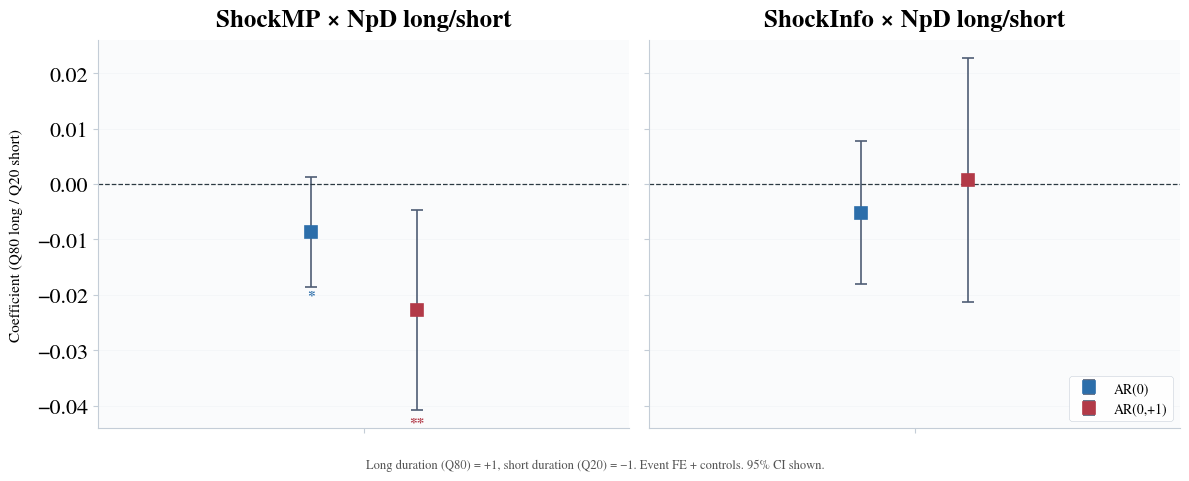

Saved: regression_results_portfolio_q20q80.csv (4 rows)


In [49]:
# ── Plot: Q20 vs Q80 coefficients — NpD only ─────────────────────────────
# Layout: left=ShockMP, right=ShockInfo; AR(0) and AR(0,+1) side-by-side.
set_global_plot_style()

try:
    if df_port.empty:
        raise ValueError("df_port is empty — no portfolio regressions succeeded.")

    _ls = 'port_ls_NetPayout'
    _npd_marker = _DUR_MARKERS.get('Duration_NetPayout_std', 'o')
    _dep_cfg = [
        ('AR_0',   'AR(0)',    _npd_marker, COLORS['blue'],   -0.12, True),
        ('AR_0_1', 'AR(0,+1)', _npd_marker, COLORS['accent'], +0.12, True),
    ]
    _shock_cfg = [
        ('ShockMP',   'coef_mp',   'se_mp',   'p_mp'),
        ('ShockInfo', 'coef_info', 'se_info', 'p_info'),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    for _ax_idx, (_shock_lbl, _c_col, _s_col, _p_col) in enumerate(_shock_cfg):
        ax = axes[_ax_idx]
        _x = np.array([0])

        for _dep, _dep_lbl, _marker, _color, _shift, _filled in _dep_cfg:
            _pdf = df_port[(df_port['depvar'] == _dep) & (df_port['ls_var'] == _ls)]
            if _pdf.empty:
                continue
            _r = _pdf.iloc[0]
            _c  = float(_r[_c_col])
            _se = float(_r[_s_col])
            _p  = float(_r[_p_col])

            ax.errorbar([_x[0] + _shift], [_c], yerr=[1.96 * _se],
                        fmt=_marker, color=_color, markersize=8,
                        markerfacecolor=(_color if _filled else 'white'),
                        markeredgecolor=_color, markeredgewidth=1.2,
                        ecolor=COLORS.get('neutral', '#aaa'),
                        capsize=4, capthick=1.2, linewidth=1.2,
                        label=_dep_lbl)

            _star = _sig_stars(_p)
            if _star and not np.isnan(_c):
                _y_off = _c + 1.96*_se + abs(_c)*0.05 if _c >= 0 else _c - 1.96*_se - abs(_c)*0.05
                ax.text(_x[0] + _shift, _y_off, _star, ha='center',
                        va='bottom' if _c >= 0 else 'top',
                        fontsize=11, color=_color, fontweight='bold')

        ax.axhline(0, color=COLORS.get('reference', '#888'),
                   linewidth=0.9, linestyle='--')
        ax.set_xticks(_x)
        ax.set_xticklabels([''], fontsize=11)
        ax.set_xlim(-0.6, 0.6)
        ax.set_title(f'{_shock_lbl} × NpD long/short', fontsize=13, fontweight='bold')
        if _ax_idx == 0:
            ax.set_ylabel('Coefficient (Q80 long / Q20 short)', fontsize=11)
        style_axes(ax, grid_axis='y', grid_alpha=0.2)

    fig.text(0.5, 0.01,
             'Long duration (Q80) = +1, short duration (Q20) = −1. '
             'Event FE + controls. 95% CI shown.',
             ha='center', fontsize=9, color='#555555')
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    # Shared figure-level legend
    _handles, _labels = axes[0].get_legend_handles_labels()
    if _handles:
        axes[1].legend(_handles, _labels, loc='lower right',
                       ncol=1, frameon=True, facecolor=(1,1,1,0.9),
                       edgecolor='#C4CDD7', fontsize=10)
    save_figure(fig, 'fig_rob_portfolio_q20q80', dpi=300)
    plt.show()

    _port_export = df_port.drop(columns=['model_obj'], errors='ignore').copy()
    _port_export.to_csv(
        TABLE_DIR / 'regression_results_portfolio_q20q80.csv', index=False)
    print(f"Saved: regression_results_portfolio_q20q80.csv ({len(_port_export)} rows)")

except (ValueError, KeyError, AttributeError) as _e:
    print(f"WARNING: Section 8.7 plot skipped — {_e}")


### 9.8 Shock-Sign Asymmetry: Tightening vs. Easing (Event FE)

Tests whether the Duration $\times$ ShockMP gradient differs between **tightening surprises** (ShockMP > 0) and **easing surprises** (ShockMP $\le$ 0).

We decompose ShockMP into two sign-conditional variables and estimate a single regression with **Event FE**:

$$
AR = \mu_s
+ \beta_{pos}\,\text{ShockMP}^{+}\!\times\!\text{Duration}
+ \beta_{neg}\,\text{ShockMP}^{-}\!\times\!\text{Duration}
+ \gamma_{pos}\,\text{ShockInfo}^{+}\!\times\!\text{Duration}
+ \gamma_{neg}\,\text{ShockInfo}^{-}\!\times\!\text{Duration}
+ \text{controls} + \varepsilon
$$

where $\text{ShockMP}^{+}=\max(\text{ShockMP},0)$ and $\text{ShockMP}^{-}=\min(\text{ShockMP},0)$, and the ShockInfo splits use the sign of *ShockMP* (the economic question is whether the duration channel differs between tightening and easing **environments**). Controls are the Model 4 interactions (`beta_std`, `log_mcap_std`, `leverage_std`, `bm_std`) interacted with each sign-decomposed shock. Standard errors are clustered by `event_date`.

The level terms `ShockMP_pos`, `ShockMP_neg`, `ShockInfo_pos`, `ShockInfo_neg` and the `Tight` indicator are event-constant and absorbed by `C(event_date)`. The interactions with firm-varying duration and controls remain identified.

**Formal asymmetry test:** cluster-robust Wald test of $H_0: \beta_{pos}=\beta_{neg}$.


In [50]:
# ── 9.8 Shock-Sign Asymmetry — Decomposed Shocks with Event FE ──────────────
# Decompose ShockMP into positive (tightening) and negative (easing) parts
# and estimate a single Event-FE regression. ShockInfo is split by the sign
# of ShockMP (tightening vs. easing environment).
import warnings

df_evt['ShockMP_pos']   = df_evt['ShockMP'].clip(lower=0)
df_evt['ShockMP_neg']   = df_evt['ShockMP'].clip(upper=0)
df_evt['ShockInfo_pos'] = df_evt['ShockInfo'] * (df_evt['ShockMP'] >  0).astype(float)
df_evt['ShockInfo_neg'] = df_evt['ShockInfo'] * (df_evt['ShockMP'] <= 0).astype(float)

_asym_rows = []
_ctrl_cols = ['beta_std', 'log_mcap_std', 'leverage_std', 'bm_std']
_shock_decomp = ['ShockMP_pos', 'ShockMP_neg', 'ShockInfo_pos', 'ShockInfo_neg']

for _dep in depvars_main:
    for _dur in duration_vars_main:
        shock_dur_terms = [f'{s}:{_dur}' for s in _shock_decomp]
        ctrl_terms = []
        for s in _shock_decomp:
            for c in _ctrl_cols:
                if c in df_evt.columns:
                    ctrl_terms.append(f'{s}:{c}')

        formula = (f'{_dep} ~ ' + ' + '.join(shock_dur_terms + ctrl_terms)
                   + ' + C(event_date)')

        _need = [_dep, _dur, 'ShockMP', 'ShockInfo'] + _shock_decomp
        sub = df_evt.dropna(subset=_need).copy()
        sub[_dep] = pd.to_numeric(sub[_dep], errors='coerce')
        sub = sub.dropna(subset=[_dep])

        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                _model = smf.ols(formula, data=sub)
                _groups = pd.Categorical(
                    sub.loc[_model.data.row_labels, 'event_date']
                ).codes
                _res = _model.fit(cov_type='cluster',
                                  cov_kwds={'groups': _groups})
        except Exception as e:
            print(f'  ERROR {_dep} / {_dur}: {e}')
            continue

        mp_pos_key = f'ShockMP_pos:{_dur}'
        mp_neg_key = f'ShockMP_neg:{_dur}'
        info_pos_key = f'ShockInfo_pos:{_dur}'
        info_neg_key = f'ShockInfo_neg:{_dur}'

        # Wald test: beta_pos = beta_neg
        names = list(_res.params.index)
        try:
            R = np.zeros((1, len(names)))
            R[0, names.index(mp_pos_key)] = 1.0
            R[0, names.index(mp_neg_key)] = -1.0
            wald = _res.wald_test(R, scalar=True)
            wald_p = float(wald.pvalue)
            wald_stat = float(np.asarray(wald.statistic).ravel()[0])
        except Exception as e:
            print(f'  Wald test failed for {_dep}/{_dur}: {e}')
            wald_p = float('nan')
            wald_stat = float('nan')

        def _safe(attr, key):
            try:
                return float(getattr(_res, attr)[key])
            except Exception:
                return float('nan')

        _asym_rows.append({
            'depvar':              _dep,
            'duration_name':       _dur,
            'coef_mp_tightening':  _safe('params',  mp_pos_key),
            'se_mp_tightening':    _safe('bse',     mp_pos_key),
            't_mp_tightening':     _safe('tvalues', mp_pos_key),
            'p_mp_tightening':     _safe('pvalues', mp_pos_key),
            'coef_mp_easing':      _safe('params',  mp_neg_key),
            'se_mp_easing':        _safe('bse',     mp_neg_key),
            't_mp_easing':         _safe('tvalues', mp_neg_key),
            'p_mp_easing':         _safe('pvalues', mp_neg_key),
            'coef_info_tightening': _safe('params',  info_pos_key),
            'se_info_tightening':   _safe('bse',     info_pos_key),
            'p_info_tightening':    _safe('pvalues', info_pos_key),
            'coef_info_easing':     _safe('params',  info_neg_key),
            'se_info_easing':       _safe('bse',     info_neg_key),
            'p_info_easing':        _safe('pvalues', info_neg_key),
            'wald_stat_asymmetry':  wald_stat,
            'wald_p_asymmetry':     wald_p,
            'N':                   int(_res.nobs),
            'n_events':            int(sub['event_date'].nunique()),
            'r_squared_adj':       float(_res.rsquared_adj),
        })

df_asym = pd.DataFrame(_asym_rows)


def _stars(p):
    if p < 0.01:  return '***'
    if p < 0.05:  return '**'
    if p < 0.10:  return '*'
    return ''


print('\nShock-Sign Asymmetry — Decomposed Shocks with Event FE')
print('Single regression: ShockMP_pos and ShockMP_neg interacted with Duration')
print('H0: beta_pos = beta_neg (cluster-robust Wald test)\n')

if not df_asym.empty:
    for _, _r in df_asym.iterrows():
        _dur_s = dur_short.get(_r['duration_name'], _r['duration_name'])
        _dep_s = dep_short.get(_r['depvar'], _r['depvar'])
        _st_p = _stars(_r['p_mp_tightening'])
        _st_n = _stars(_r['p_mp_easing'])
        _st_w = _stars(_r['wald_p_asymmetry'])
        print(f'  {_dur_s} / {_dep_s}:')
        print(f'    beta_pos (Tightening): {_r["coef_mp_tightening"]:+.4f}{_st_p}'
              f'  (t={_r["t_mp_tightening"]:.2f}, p={_r["p_mp_tightening"]:.3f})')
        print(f'    beta_neg (Easing):     {_r["coef_mp_easing"]:+.4f}{_st_n}'
              f'  (t={_r["t_mp_easing"]:.2f}, p={_r["p_mp_easing"]:.3f})')
        print(f'    Wald p(beta_pos=beta_neg): {_r["wald_p_asymmetry"]:.3f}{_st_w}'
              f'  (chi2/F={_r["wald_stat_asymmetry"]:.2f})')
        print(f'    N={_r["N"]:,}  events={_r["n_events"]}'
              f'  Adj.R^2={_r["r_squared_adj"]:.4f}')
        print()

# Event counts
_n_tight = (df_evt['ShockMP'] >  0).sum()
_n_ease  = (df_evt['ShockMP'] <  0).sum()
_n_zero  = (df_evt['ShockMP'] == 0).sum()
_ev_tight = df_evt[df_evt['ShockMP'] > 0]['event_date'].nunique()
_ev_ease  = df_evt[df_evt['ShockMP'] < 0]['event_date'].nunique()
print(f'Event-firm obs — Tightening: {_n_tight:,}  |  Easing: {_n_ease:,}'
      f'  |  Zero: {_n_zero:,}')
print(f'Unique events  — Tightening: {_ev_tight}  |  Easing: {_ev_ease}')



Shock-Sign Asymmetry — Decomposed Shocks with Event FE
Single regression: ShockMP_pos and ShockMP_neg interacted with Duration
H0: beta_pos = beta_neg (cluster-robust Wald test)

  NpD / AR(0):
    beta_pos (Tightening): -0.0031  (t=-0.87, p=0.382)
    beta_neg (Easing):     -0.0097*  (t=-1.78, p=0.075)
    Wald p(beta_pos=beta_neg): 0.310  (chi2/F=1.03)
    N=86,275  events=312  Adj.R^2=0.0843

  NpD / AR(0,+1):
    beta_pos (Tightening): -0.0190***  (t=-3.15, p=0.002)
    beta_neg (Easing):     -0.0015  (t=-0.23, p=0.815)
    Wald p(beta_pos=beta_neg): 0.044**  (chi2/F=4.05)
    N=85,789  events=312  Adj.R^2=0.0745

Event-firm obs — Tightening: 68,338  |  Easing: 61,205  |  Zero: 0
Unique events  — Tightening: 165  |  Easing: 147


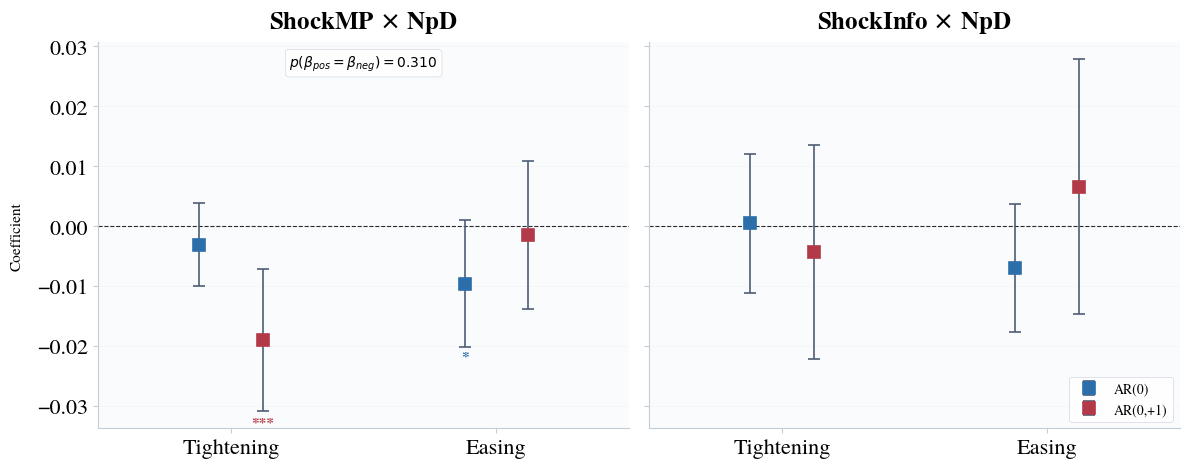

Saved: fig_rob_sign_asymmetry.png
Exported: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/ECBShocks_Equities_Regressions/regression_results_asymmetry.csv  (2 rows)


In [51]:
# ── 9.8 Plot: Tightening vs. Easing — NpD only ──────────────────────────────
# Layout: left=ShockMP, right=ShockInfo. x-axis groups: Tightening, Easing.
# Each group shows AR(0) and AR(0,+1) side-by-side with 95% CI error bars.
if df_asym.empty:
    print('No asymmetry results to plot.')
else:
    set_global_plot_style()

    _dur = 'Duration_NetPayout_std'
    _npd_marker = _DUR_MARKERS.get(_dur, 'o')
    _sign_labels = ['Tightening', 'Easing']
    _dep_cfg = [
        ('AR_0',   'AR(0)',    _npd_marker, COLORS['blue'],   -0.12, True),
        ('AR_0_1', 'AR(0,+1)', _npd_marker, COLORS['accent'], +0.12, True),
    ]
    _shock_cfg = [
        ('ShockMP',
         ('coef_mp_tightening', 'se_mp_tightening', 'p_mp_tightening'),
         ('coef_mp_easing',     'se_mp_easing',     'p_mp_easing')),
        ('ShockInfo',
         ('coef_info_tightening', 'se_info_tightening', 'p_info_tightening'),
         ('coef_info_easing',     'se_info_easing',     'p_info_easing')),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    for _ax_idx, (_shock_lbl, _tight_keys, _ease_keys) in enumerate(_shock_cfg):
        ax = axes[_ax_idx]
        _x = np.arange(len(_sign_labels))

        for _dep, _dep_lbl, _marker, _color, _shift, _filled in _dep_cfg:
            _row = df_asym[(df_asym['depvar'] == _dep) &
                           (df_asym['duration_name'] == _dur)]
            if _row.empty:
                continue
            _row = _row.iloc[0]

            _vals = [float(_row[_tight_keys[0]]), float(_row[_ease_keys[0]])]
            _errs = [1.96 * float(_row[_tight_keys[1]]),
                     1.96 * float(_row[_ease_keys[1]])]
            _ps   = [float(_row[_tight_keys[2]]), float(_row[_ease_keys[2]])]

            ax.errorbar(_x + _shift, _vals, yerr=_errs,
                        fmt=_marker, color=_color, markersize=8,
                        markerfacecolor=(_color if _filled else 'white'),
                        markeredgecolor=_color, markeredgewidth=1.2,
                        ecolor=COLORS.get('neutral', '#aaa'),
                        capsize=4, capthick=1.2, linewidth=1.2,
                        label=_dep_lbl)

            for _ix, (_v, _pv, _e) in enumerate(zip(_vals, _ps, _errs)):
                _st = _stars(_pv)
                if _st and not np.isnan(_v):
                    _y_off = (_v + _e + abs(_v) * 0.05 if _v >= 0
                              else _v - _e - abs(_v) * 0.05)
                    ax.text(_x[_ix] + _shift, _y_off, _st, ha='center',
                            va='bottom' if _v >= 0 else 'top', fontsize=11,
                            color=_color, fontweight='bold')

        # Wald p-value annotation between the two groups (ShockMP panel only)
        if _shock_lbl == 'ShockMP':
            _wrow = df_asym[(df_asym['depvar'] == 'AR_0') &
                            (df_asym['duration_name'] == _dur)]
            if not _wrow.empty:
                _wp = float(_wrow['wald_p_asymmetry'].iloc[0])
                ax.annotate(f'$p(\\beta_{{pos}}=\\beta_{{neg}})={_wp:.3f}$',
                            xy=(0.5, 0.97), xycoords='axes fraction',
                            ha='center', va='top', fontsize=10,
                            bbox=dict(boxstyle='round,pad=0.3',
                                      facecolor='white', edgecolor='#C4CDD7',
                                      alpha=0.9))

        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', zorder=1)
        ax.set_xticks(_x)
        ax.set_xticklabels(_sign_labels, fontsize=10)
        ax.set_xlim(-0.5, len(_x) - 0.5)
        ax.set_title(f'{_shock_lbl} $\\times$ NpD',
                     fontsize=13, fontweight='bold')
        if _ax_idx == 0:
            ax.set_ylabel('Coefficient', fontsize=11)
        style_axes(ax, grid_axis='y', grid_alpha=0.2)

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    _handles, _labels = axes[0].get_legend_handles_labels()
    if _handles:
        axes[1].legend(_handles, _labels, loc='lower right',
                       ncol=1, frameon=True, facecolor=(1, 1, 1, 0.9),
                       edgecolor='#C4CDD7', fontsize=10)
    save_figure(fig, 'fig_rob_sign_asymmetry', dpi=300)
    plt.show()
    print('Saved: fig_rob_sign_asymmetry.png')

# ── Export ────────────────────────────────────────────────────────────────────
if not df_asym.empty:
    _asym_out = TABLE_DIR / 'regression_results_asymmetry.csv'
    df_asym.to_csv(_asym_out, index=False)
    print(f'Exported: {_asym_out}  ({len(df_asym)} rows)')

### 9.10 CAPM-Adjusted Abnormal Returns

The main results use **simple market-adjusted** abnormal returns ($AR_{i,t} = R_{i,t} - R_{m,t}$). This section re-estimates **Model 4** using **CAPM-adjusted** abnormal returns ($AR^{CAPM}_{i,t} = R_{i,t} - r_{f,t} - \hat\beta_i (R_{m,t} - r_{f,t})$) as the dependent variable. Stable coefficients confirm the main effect is not driven by systematic beta differences between long- and short-duration firms.

**Result:** ShockMP × NpD = **−0.021** (t=−2.44, p=0.015) for CAPM-`AR_0_1` — slightly *larger in magnitude* than the market-AR baseline (−0.018), consistent with the duration channel being robust to beta adjustment.


In [52]:
# ── 9.10 CAPM-Adjusted Abnormal Returns ────────────────────────────
_capm_deps = [c for c in ['capm_AR_0', 'capm_AR_0_1'] if c in df_evt.columns]
if not _capm_deps:
    print("SKIP: CAPM abnormal returns not available in df_evt.")
    df_capm_results = pd.DataFrame()
else:
    _capm_rows = []
    for _dep in _capm_deps:
        for _dur in duration_vars_main:
            row = run_regression(
                df=df_evt, depvar=_dep, duration_var=_dur,
                specification_name='Robustness: Model 4 CAPM-adjusted AR',
                include_event_fe=True, include_raw_shocks=False,
                controls=ctrl_plus, cluster='event', include_bm=True)
            if row is not None:
                _capm_rows.append(row)
    df_capm_results = pd.DataFrame(_capm_rows)
    if not df_capm_results.empty:
        display(df_capm_results[['depvar', 'duration_name', 'N',
            'coef_mp_duration', 't_mp_duration', 'p_mp_duration',
            'coef_info_duration', 't_info_duration', 'p_info_duration']])


,depvar,duration_name,N,coef_mp_duration,t_mp_duration,p_mp_duration,coef_info_duration,t_info_duration,p_info_duration
0,capm_AR_0,Duration_NetPayout_std,86275,-0.008931,-1.846154,0.064870,-0.005717,-1.459504,0.144427
1,capm_AR_0_1,Duration_NetPayout_std,85789,-0.015000,-2.020694,0.043311,-0.003978,-0.508560,0.611061


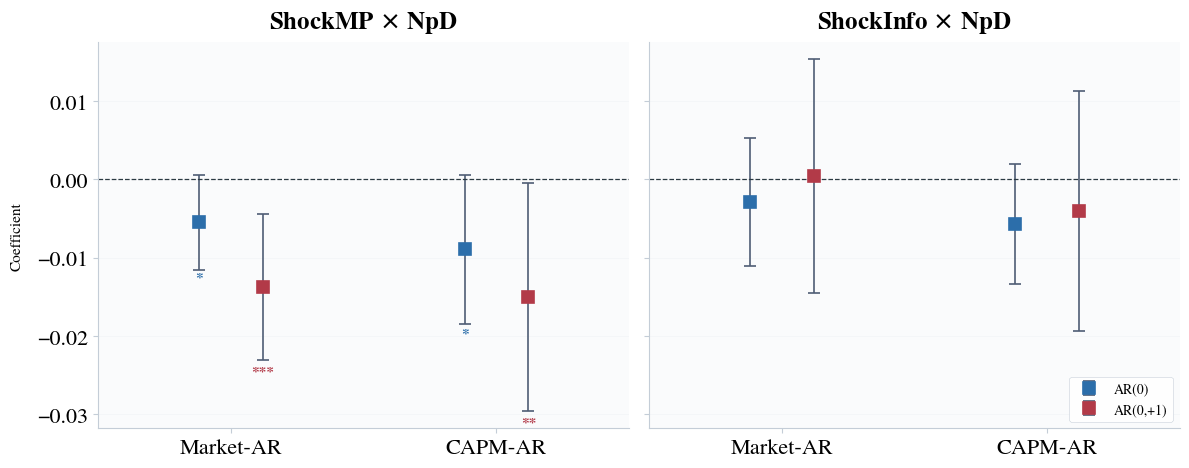

Saved: fig_rob_capm_ar.png


In [53]:
# ── 9.10 Plot: Market-AR vs CAPM-AR — NpD only ──────────────────────────────
# Layout: left=ShockMP, right=ShockInfo. Within each panel: Market-AR and
# CAPM-AR as x-groups; AR(0) and AR(0,+1) side-by-side per group.
if df_capm_results.empty:
    print("No CAPM-AR results to plot.")
else:
    set_global_plot_style()
    _dur = 'Duration_NetPayout_std'
    _capm_dep_map = {'AR_0': 'capm_AR_0', 'AR_0_1': 'capm_AR_0_1'}

    _npd_marker = _DUR_MARKERS.get('Duration_NetPayout_std', 'o')
    _dep_cfg = [
        ('AR_0',   'AR(0)',    _npd_marker, COLORS['blue'],   -0.12, True),
        ('AR_0_1', 'AR(0,+1)', _npd_marker, COLORS['accent'], +0.12, True),
    ]
    _shock_cfg = [
        ('ShockMP',   'coef_mp_duration',   'se_mp_duration',   'p_mp_duration'),
        ('ShockInfo', 'coef_info_duration', 'se_info_duration', 'p_info_duration'),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    for _ax_idx, (_shock_lbl, _coef_c, _se_c, _p_c) in enumerate(_shock_cfg):
        ax = axes[_ax_idx]
        _x = np.arange(2)  # 0 = Market-AR, 1 = CAPM-AR

        for _dep, _dep_lbl, _marker, _color, _shift, _filled in _dep_cfg:
            _dep_capm = _capm_dep_map[_dep]

            _main = df_results[
                (df_results['specification_name'] == 'Model 4: Event FE + all controls') &
                (df_results['depvar'] == _dep) &
                (df_results['duration_name'] == _dur)
            ]
            _capm = df_capm_results[
                (df_capm_results['depvar'] == _dep_capm) &
                (df_capm_results['duration_name'] == _dur)
            ]

            _vals, _errs, _ps = [], [], []
            for _src in [_main, _capm]:
                if _src.empty:
                    _vals.append(np.nan); _errs.append(np.nan); _ps.append(np.nan)
                else:
                    _vals.append(float(_src[_coef_c].iloc[0]))
                    _errs.append(1.96 * float(_src[_se_c].iloc[0]))
                    _ps.append(float(_src[_p_c].iloc[0]))

            ax.errorbar(_x + _shift, _vals, yerr=_errs,
                        fmt=_marker, color=_color, markersize=8,
                        markerfacecolor=(_color if _filled else 'white'),
                        markeredgecolor=_color, markeredgewidth=1.2,
                        ecolor=COLORS.get('neutral', '#aaa'),
                        capsize=4, capthick=1.2, linewidth=1.2,
                        label=_dep_lbl)

            for _ix, (_v, _pv, _e) in enumerate(zip(_vals, _ps, _errs)):
                _star = _sig_stars(_pv)
                if _star and not np.isnan(_v):
                    _y_off = _v + _e + abs(_v) * 0.05 if _v >= 0 else _v - _e - abs(_v) * 0.05
                    ax.text(_x[_ix] + _shift, _y_off, _star, ha='center',
                            va='bottom' if _v >= 0 else 'top', fontsize=11,
                            color=_color, fontweight='bold')

        ax.axhline(0, color=COLORS.get('reference', '#888'),
                   linewidth=0.9, linestyle='--')
        ax.set_xticks(_x)
        ax.set_xticklabels(['Market-AR', 'CAPM-AR'], fontsize=10)
        ax.set_xlim(-0.5, 1.5)
        ax.set_title(f'{_shock_lbl} $\\times$ NpD', fontsize=13, fontweight='bold')
        if _ax_idx == 0:
            ax.set_ylabel('Coefficient', fontsize=11)
        style_axes(ax, grid_axis='y', grid_alpha=0.2)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    # Shared figure-level legend
    _handles, _labels = axes[0].get_legend_handles_labels()
    if _handles:
        axes[1].legend(_handles, _labels, loc='lower right',
                       ncol=1, frameon=True, facecolor=(1,1,1,0.9),
                       edgecolor='#C4CDD7', fontsize=10)
    save_figure(fig, 'fig_rob_capm_ar', dpi=300)
    plt.show()
    print('Saved: fig_rob_capm_ar.png')


In [54]:
if not df_capm_results.empty:
    _capm_out = TABLE_DIR / 'regression_results_capm_ar.csv'
    df_capm_results.to_csv(_capm_out, index=False)
    print(f"Exported: {_capm_out}  ({len(df_capm_results)} rows)")
else:
    print("No CAPM-AR results to export.")

Exported: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/ECBShocks_Equities_Regressions/regression_results_capm_ar.csv  (2 rows)


### 9.11 Poor Man's Decomposition

Re-estimates **Model 4** using the **Poor Man's sign-restriction decomposition** (`MP_pm`, `CBI_pm`) instead of the median rotation (`MP_median`, `CBI_median`). In the PM decomposition each event is assigned entirely to either the MP or the CBI component — one of the two is always zero — making the loadings directly comparable to the median baseline.

**Result:** ShockMP × NpD = **−0.014** (t=−2.53, p=0.011) for `AR_0_1`, virtually identical in sign and significance to the median-rotation baseline (−0.018, t=−3.37). The duration channel is not an artefact of the chosen rotation scheme.


In [55]:
# ── 9.11 Poor Man's Decomposition ────────────────────────────────────────────
# Re-estimates Model 4 with the poor man's sign-restriction decomposition.
# In the PM decomposition, each event is assigned entirely to either MP or CBI
# (one component is always zero), so both can enter the same regression.
# Structure is identical to the median rotation baseline for direct comparison.

_pm_rows = []
if 'ShockMP_pm' in df_evt.columns and 'ShockInfo_pm' in df_evt.columns:
    # Temporarily swap shock columns
    _bak_mp = df_evt['ShockMP'].copy()
    _bak_info = df_evt['ShockInfo'].copy()
    df_evt['ShockMP'] = df_evt['ShockMP_pm']
    df_evt['ShockInfo'] = df_evt['ShockInfo_pm']

    for _dep in depvars_main:
        for _dur in duration_vars_main:
            row = run_regression(
                df=df_evt, depvar=_dep, duration_var=_dur,
                specification_name="Robustness: Model 4 Poor Man's decomposition",
                include_event_fe=True, include_raw_shocks=False,
                controls=ctrl_plus, cluster='event', include_bm=True)
            if row is not None:
                _pm_rows.append(row)

    # Restore original shocks
    df_evt['ShockMP'] = _bak_mp
    df_evt['ShockInfo'] = _bak_info

df_pm_results = pd.DataFrame(_pm_rows)
if not df_pm_results.empty:
    display(df_pm_results[['depvar', 'duration_name', 'N',
        'coef_mp_duration', 't_mp_duration', 'p_mp_duration',
        'coef_info_duration', 't_info_duration', 'p_info_duration']])
    df_pm_results.to_csv(TABLE_DIR / 'regression_results_pm_decomp.csv', index=False)
else:
    print("Poor Man's decomposition columns not found — skipped.")


,depvar,duration_name,N,coef_mp_duration,t_mp_duration,p_mp_duration,coef_info_duration,t_info_duration,p_info_duration
0,AR_0,Duration_NetPayout_std,86275,-0.004854,-1.680526,0.092855,0.000011,0.002755,0.997802
1,AR_0_1,Duration_NetPayout_std,85789,-0.009078,-2.229046,0.025811,-0.001990,-0.193596,0.846492


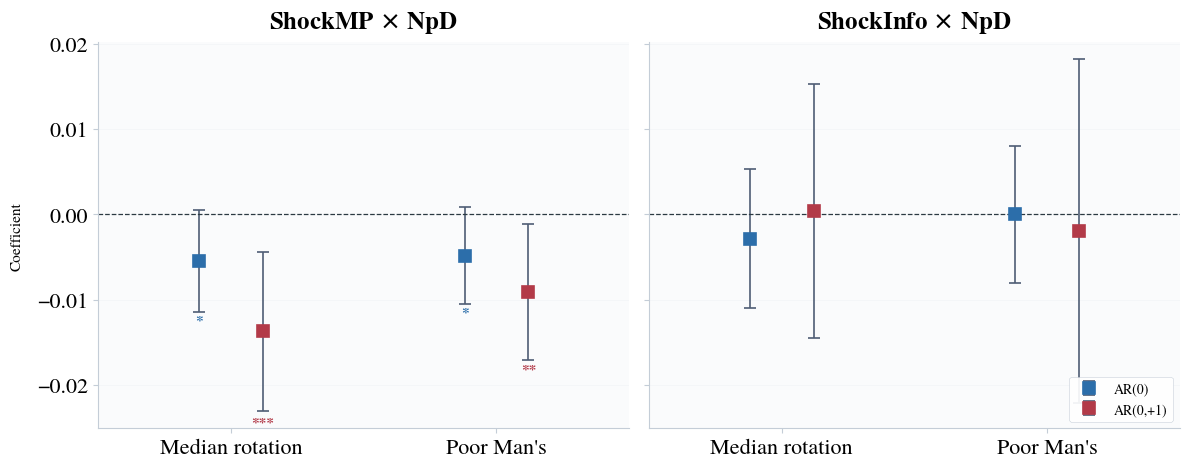

Saved: fig_rob_pm_decomp.png


In [56]:
# ── 9.11 Plot: Median rotation vs Poor Man's — NpD only ─────────────────────
# Layout identical to CAPM plot (9.10): left=ShockMP, right=ShockInfo.
# Within each panel: Median rotation vs Poor Man's as x-groups; AR(0) and
# AR(0,+1) as side-by-side markers per group.
if df_pm_results.empty:
    print("No Poor Man's results to plot.")
else:
    set_global_plot_style()
    _dur = 'Duration_NetPayout_std'

    _npd_marker = _DUR_MARKERS.get('Duration_NetPayout_std', 'o')
    _dep_cfg = [
        ('AR_0',   'AR(0)',    _npd_marker, COLORS['blue'],   -0.12, True),
        ('AR_0_1', 'AR(0,+1)', _npd_marker, COLORS['accent'], +0.12, True),
    ]
    _shock_cfg = [
        ('ShockMP',   'coef_mp_duration',   'se_mp_duration',   'p_mp_duration'),
        ('ShockInfo', 'coef_info_duration', 'se_info_duration', 'p_info_duration'),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    for _ax_idx, (_shock_lbl, _coef_c, _se_c, _p_c) in enumerate(_shock_cfg):
        ax = axes[_ax_idx]
        _x = np.arange(2)  # 0 = Median, 1 = Poor Man's

        for _dep, _dep_lbl, _marker, _color, _shift, _filled in _dep_cfg:
            _main = df_results[
                (df_results['specification_name'] == 'Model 4: Event FE + all controls') &
                (df_results['depvar'] == _dep) &
                (df_results['duration_name'] == _dur)
            ]
            _pm = df_pm_results[
                (df_pm_results['depvar'] == _dep) &
                (df_pm_results['duration_name'] == _dur)
            ]

            _vals, _errs, _ps = [], [], []
            for _src in [_main, _pm]:
                if _src.empty:
                    _vals.append(np.nan); _errs.append(np.nan); _ps.append(np.nan)
                else:
                    _vals.append(float(_src[_coef_c].iloc[0]))
                    _errs.append(1.96 * float(_src[_se_c].iloc[0]))
                    _ps.append(float(_src[_p_c].iloc[0]))

            ax.errorbar(_x + _shift, _vals, yerr=_errs,
                        fmt=_marker, color=_color, markersize=8,
                        markerfacecolor=(_color if _filled else 'white'),
                        markeredgecolor=_color, markeredgewidth=1.2,
                        ecolor=COLORS.get('neutral', '#aaa'),
                        capsize=4, capthick=1.2, linewidth=1.2,
                        label=_dep_lbl)

            for _ix, (_v, _pv, _e) in enumerate(zip(_vals, _ps, _errs)):
                _star = _sig_stars(_pv)
                if _star and not np.isnan(_v):
                    _y_off = _v + _e + abs(_v) * 0.05 if _v >= 0 else _v - _e - abs(_v) * 0.05
                    ax.text(_x[_ix] + _shift, _y_off, _star, ha='center',
                            va='bottom' if _v >= 0 else 'top', fontsize=11,
                            color=_color, fontweight='bold')

        ax.axhline(0, color=COLORS.get('reference', '#888'),
                   linewidth=0.9, linestyle='--')
        ax.set_xticks(_x)
        ax.set_xticklabels(['Median rotation', "Poor Man's"], fontsize=10)
        ax.set_xlim(-0.5, 1.5)
        ax.set_title(f'{_shock_lbl} $\\times$ NpD', fontsize=13, fontweight='bold')
        if _ax_idx == 0:
            ax.set_ylabel('Coefficient', fontsize=11)
        style_axes(ax, grid_axis='y', grid_alpha=0.2)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    _handles, _labels = axes[0].get_legend_handles_labels()
    if _handles:
        axes[1].legend(_handles, _labels, loc='lower right',
                       ncol=1, frameon=True, facecolor=(1,1,1,0.9),
                       edgecolor='#C4CDD7', fontsize=10)
    save_figure(fig, 'fig_rob_pm_decomp', dpi=300)
    plt.show()
    print('Saved: fig_rob_pm_decomp.png')


### 9.12 Duration-Quintile Monotonicity

Sorts firms into **5 NpD quintiles per year** and estimates the differential `ShockMP` and `ShockInfo` response per quintile in a **single pooled regression** with **Event FE** and Q3 (median quintile) as the omitted reference. Quintile-specific effects therefore measure deviations from the middle of the duration distribution, net of the common market response on each event date. Model-4 controls (`beta`, `size`, `leverage`, `bm` interactions); SEs clustered by `event_date`.

**Result (AR(0,+1) × ShockMP, relative to Q3):** Q1 = +0.018 → Q2 = +0.015 → Q3 = 0 → Q4 = −0.004 → Q5 = **−0.022 (p=0.034)**. Clean monotonic decline; the Q5–Q1 spread of ~4 pp is consistent with the continuous Model-4 estimate scaled by the quintile range.


In [57]:
# ── 9.12 Duration-Quintile Monotonicity ──────────────────────────────────────
# Single pooled regression per depvar with Event FE. Quintile dummies (Q3 omitted
# as reference) are interacted with ShockMP and ShockInfo. Coefficients on
# ShockMP:Qk give the differential MP-shock response of quintile k relative to
# the median quintile Q3, net of the common event-date market response.

_raw_dur = 'Duration_NetPayout'
if _raw_dur in df_evt.columns:
    df_evt['NpD_quintile'] = df_evt.groupby('year_pred')[_raw_dur].transform(
        lambda s: pd.qcut(s.rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
    ).astype('Int64')

    # Quintile dummies, Q3 omitted as reference
    for _q in [1, 2, 4, 5]:
        df_evt[f'Q{_q}'] = (df_evt['NpD_quintile'] == _q).astype(float)

    _qrows = []
    for _dep in depvars_main:
        q_terms  = [f'ShockMP:Q{_q}'   for _q in [1, 2, 4, 5]]
        q_terms += [f'ShockInfo:Q{_q}' for _q in [1, 2, 4, 5]]

        ctrl_terms = []
        for _c in ['beta_std', 'log_mcap_std', 'leverage_std', 'bm_std']:
            if _c in df_evt.columns and df_evt[_c].notna().any():
                ctrl_terms += [f'ShockMP:{_c}', f'ShockInfo:{_c}']

        _sub = df_evt[df_evt['NpD_quintile'].notna()].copy()
        _sub[_dep] = pd.to_numeric(_sub[_dep], errors='coerce')
        _sub = _sub.dropna(subset=[_dep, 'ShockMP', 'ShockInfo'])
        if _sub.empty:
            continue

        _formula = (f'{_dep} ~ ' + ' + '.join(q_terms + ctrl_terms)
                    + ' + C(event_date)')

        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                _model = smf.ols(_formula, data=_sub)
                _groups = pd.Categorical(
                    _sub.loc[_model.data.row_labels, 'event_date']).codes
                _res = _model.fit(cov_type='cluster', cov_kwds={'groups': _groups})
        except Exception as e:
            print(f"  {_dep}: {e}")
            continue

        for _q in [1, 2, 3, 4, 5]:
            _mp_key   = f'ShockMP:Q{_q}'
            _info_key = f'ShockInfo:Q{_q}'
            if _q == 3:
                _qrows.append({
                    'depvar': _dep, 'quintile': _q,
                    'coef_mp':   0.0, 'se_mp':   0.0, 'p_mp':   float('nan'),
                    'coef_info': 0.0, 'se_info': 0.0, 'p_info': float('nan'),
                    'N': int(_res.nobs),
                    'n_events': int(_sub['event_date'].nunique()),
                })
            else:
                _qrows.append({
                    'depvar': _dep, 'quintile': _q,
                    'coef_mp':   float(_res.params.get(_mp_key,   float('nan'))),
                    'se_mp':     float(_res.bse.get(_mp_key,      float('nan'))),
                    'p_mp':      float(_res.pvalues.get(_mp_key,  float('nan'))),
                    'coef_info': float(_res.params.get(_info_key, float('nan'))),
                    'se_info':   float(_res.bse.get(_info_key,    float('nan'))),
                    'p_info':    float(_res.pvalues.get(_info_key, float('nan'))),
                    'N': int(_res.nobs),
                    'n_events': int(_sub['event_date'].nunique()),
                })

    df_quintile = pd.DataFrame(_qrows)

    if not df_quintile.empty:
        display(df_quintile)
        df_quintile.to_csv(
            TABLE_DIR / 'regression_results_quintile_monotonicity.csv',
            index=False)
else:
    df_quintile = pd.DataFrame()
    print('SKIP: Duration_NetPayout not in df_evt — quintile monotonicity skipped.')


,depvar,quintile,coef_mp,se_mp,p_mp,coef_info,se_info,p_info,N,n_events
0,AR_0,1,0.003597,0.007577,0.635007,0.010713,0.009518,0.260383,86275,312
1,AR_0,2,0.000496,0.009431,0.958047,0.004102,0.009895,0.678457,86275,312
2,AR_0,3,0.000000,0.000000,NaN,0.000000,0.000000,NaN,86275,312
3,AR_0,4,-0.011053,0.009708,0.254852,0.010807,0.010215,0.290082,86275,312
4,AR_0,5,-0.009577,0.007589,0.206989,0.001476,0.012241,0.904012,86275,312
5,AR_0_1,1,0.003727,0.008144,0.647230,0.004442,0.011125,0.689717,85789,312
6,AR_0_1,2,-0.000015,0.011123,0.998941,-0.000964,0.010680,0.928104,85789,312
7,AR_0_1,3,0.000000,0.000000,NaN,0.000000,0.000000,NaN,85789,312
8,AR_0_1,4,-0.020996,0.009697,0.030367,0.007100,0.012997,0.584891,85789,312
9,AR_0_1,5,-0.027487,0.012361,0.026166,0.002204,0.018158,0.903409,85789,312


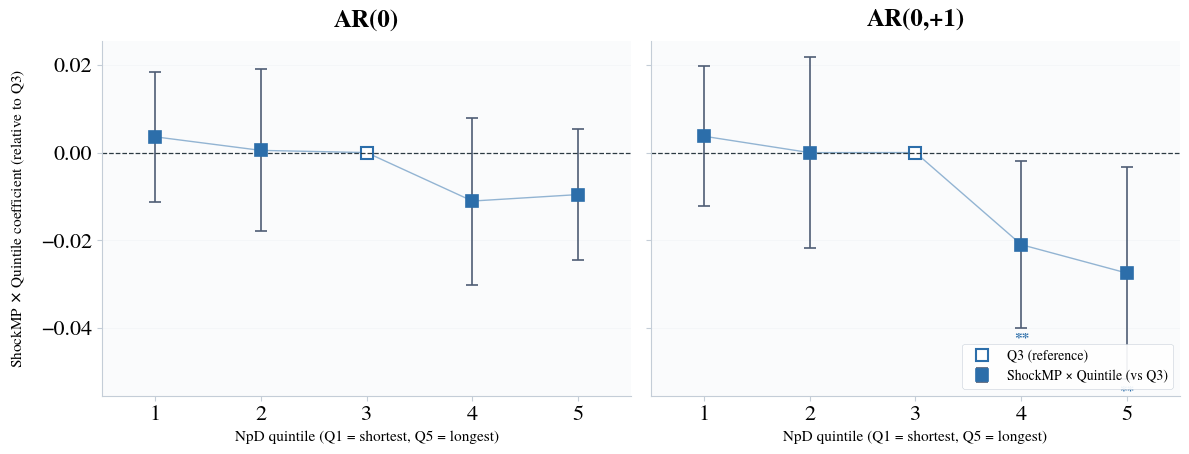

Saved: fig_rob_quintile_monotonicity.png


In [58]:
# ── 9.12 Plot: Quintile Monotonicity (relative to Q3) ───────────────────────
# Layout: left=AR(0), right=AR(0,+1). x-axis = NpD quintile (1..5), Q3 anchored
# at zero by construction (omitted reference category).
if df_quintile.empty:
    print('No quintile results to plot.')
else:
    set_global_plot_style()

    _dep_cfg = [
        ('AR_0',   'AR(0)'),
        ('AR_0_1', 'AR(0,+1)'),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    for _ax_idx, (_dep, _dep_lbl) in enumerate(_dep_cfg):
        ax = axes[_ax_idx]
        _d = df_quintile[df_quintile['depvar'] == _dep].sort_values('quintile')
        if _d.empty:
            ax.text(0.5, 0.5, 'no data', transform=ax.transAxes,
                    ha='center', va='center', fontsize=11, color='#888')
            ax.set_title(_dep_lbl, fontsize=13, fontweight='bold')
            continue

        _x = _d['quintile'].astype(int).values
        _y = _d['coef_mp'].astype(float).values
        _e = 1.96 * _d['se_mp'].astype(float).values
        _p = _d['p_mp'].astype(float).values

        # Connecting line through all five points
        ax.plot(_x, _y, color=COLORS['blue'], linewidth=1.0, alpha=0.5)

        # Non-reference quintiles: with error bars and stars
        _mask = _x != 3
        _npd_marker = _DUR_MARKERS.get('Duration_NetPayout_std', 'o')
        ax.errorbar(_x[_mask], _y[_mask], yerr=_e[_mask], fmt=_npd_marker,
                    color=COLORS['blue'], markersize=8,
                    markerfacecolor=COLORS['blue'],
                    markeredgecolor=COLORS['blue'], markeredgewidth=1.2,
                    ecolor=COLORS.get('neutral', '#aaa'),
                    capsize=4, capthick=1.2, linewidth=1.2,
                    label='ShockMP × Quintile (vs Q3)')

        # Q3 reference point: hollow marker, no bars, no stars
        ax.plot([3], [0.0], marker=_npd_marker, markersize=8,
                markerfacecolor='white',
                markeredgecolor=COLORS['blue'], markeredgewidth=1.5,
                linestyle='None', label='Q3 (reference)')

        for _xi, _yi, _ei, _pi in zip(_x, _y, _e, _p):
            if _xi == 3 or np.isnan(_pi):
                continue
            _star = _sig_stars(_pi)
            if _star and not np.isnan(_yi):
                _y_off = _yi + _ei + abs(_yi) * 0.05 if _yi >= 0 else _yi - _ei - abs(_yi) * 0.05
                ax.text(_xi, _y_off, _star, ha='center',
                        va='bottom' if _yi >= 0 else 'top', fontsize=11,
                        color=COLORS['blue'], fontweight='bold')

        ax.axhline(0, color=COLORS.get('reference', '#888'),
                   linewidth=0.9, linestyle='--')
        ax.set_xticks([1, 2, 3, 4, 5])
        ax.set_xlim(0.5, 5.5)
        ax.set_xlabel('NpD quintile (Q1 = shortest, Q5 = longest)', fontsize=11)
        if _ax_idx == 0:
            ax.set_ylabel(r'ShockMP $\times$ Quintile coefficient (relative to Q3)',
                          fontsize=11)
        ax.set_title(_dep_lbl, fontsize=13, fontweight='bold')
        style_axes(ax, grid_axis='y', grid_alpha=0.2)

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    _handles, _labels = axes[0].get_legend_handles_labels()
    if _handles:
        axes[1].legend(_handles, _labels, loc='lower right',
                       ncol=1, frameon=True, facecolor=(1,1,1,0.9),
                       edgecolor='#C4CDD7', fontsize=10)
    save_figure(fig, 'fig_rob_quintile_monotonicity', dpi=300)
    plt.show()
    print('Saved: fig_rob_quintile_monotonicity.png')


## 10. Build Tidy Results Tables

In [59]:
print("=" * 60)
print("SECTION 10: BUILD TIDY RESULTS TABLES")
print("=" * 60)

def _duration_label(x):
    return x.replace('_std', '').replace('Duration_', '')

tbl = df_results.copy()
tbl['Duration']      = tbl['duration_name'].map(_duration_label)
tbl['Specification'] = tbl['specification_name']
tbl['Event FE']      = tbl['event_FE']
tbl['Controls']      = tbl['controls']

for c in ['coef_mp_duration', 't_mp_duration', 'p_mp_duration',
          'coef_info_duration', 't_info_duration', 'p_info_duration',
          'r_squared_adj']:
    tbl[c] = pd.to_numeric(tbl[c], errors='coerce')

table_cols = [
    'Duration', 'Specification', 'Event FE', 'Controls',
    'coef_mp_duration', 't_mp_duration', 'p_mp_duration',
    'coef_info_duration', 't_info_duration', 'p_info_duration',
    'N', 'n_events', 'n_clusters', 'r_squared_adj',
]
col_rename = {
    'coef_mp_duration':   'ShockMP x Duration',
    't_mp_duration':      't-stat MP',
    'p_mp_duration':      'p-value MP',
    'coef_info_duration': 'ShockInfo x Duration',
    't_info_duration':    't-stat Info',
    'p_info_duration':    'p-value Info',
    'n_events':           'Events',
    'n_clusters':         'Clusters',
    'r_squared_adj':      'Adj. R2',
}

TABLE_A = tbl[tbl['depvar'] == 'AR_0'][table_cols].rename(columns=col_rename).copy()
TABLE_B = tbl[tbl['depvar'] == 'AR_0_1'][table_cols].rename(columns=col_rename).copy()

for _t in [TABLE_A, TABLE_B]:
    for c in ['ShockMP x Duration', 't-stat MP', 'p-value MP',
              'ShockInfo x Duration', 't-stat Info', 'p-value Info', 'Adj. R2']:
        if c in _t.columns:
            _t[c] = _t[c].map(lambda v: f'{v:.4f}' if pd.notna(v) else '')

# Reader table: coef*** (t-stat) format
reader = tbl.copy()
reader['ShockMP x Duration'] = reader.apply(
    lambda r: make_reader_entry(r['coef_mp_duration'], r['t_mp_duration'], r['p_mp_duration']),
    axis=1)
reader['ShockInfo x Duration'] = reader.apply(
    lambda r: make_reader_entry(r['coef_info_duration'], r['t_info_duration'], r['p_info_duration']),
    axis=1) 
TABLE_READER = reader[['depvar', 'Duration', 'Specification', 'Event FE', 'Controls',
                         'ShockMP x Duration', 'ShockInfo x Duration',
                         'N', 'n_events', 'n_clusters', 'r_squared_adj']].rename(
    columns={'depvar': 'Return window', 'n_events': 'Events',
             'n_clusters': 'Clusters', 'r_squared_adj': 'Adj. R2'})

print('TABLE A: AR_0 (event-day return)')
display(TABLE_A)
print('\nTABLE B: AR_0_1 (cumulative 2-day return)')
display(TABLE_B)
print('\nReader table — coef*** (t-stat):')
display(TABLE_READER)

SECTION 10: BUILD TIDY RESULTS TABLES
TABLE A: AR_0 (event-day return)


,Duration,Specification,Event FE,Controls,ShockMP x Duration,t-stat MP,p-value MP,ShockInfo x Duration,t-stat Info,p-value Info,N,Events,Clusters,Adj. R2
0,NetPayout,Model 1: Baseline,No,None,-0.0005,-0.0816,0.9350,-0.0039,-0.7607,0.4468,87640,312,312,0.0153
1,NetPayout,Model 2: + beta,No,beta,-0.0068,-1.5453,0.1223,0.0039,0.9306,0.3521,86275,312,312,0.0219
2,NetPayout,Model 3: + size/leverage,No,"beta, size, leverage",-0.0053,-1.4559,0.1454,-0.0011,-0.2614,0.7938,86275,312,312,0.0251
3,NetPayout,Model 4: Event FE + all controls,Yes,"beta, size, leverage",-0.0055,-1.7877,0.0738,-0.0029,-0.6895,0.4905,86275,312,312,0.0841
4,NetPayout,Model 5: No Event FE + all controls,No,"beta, size, leverage",-0.0054,-1.7790,0.0752,-0.0039,-0.9607,0.3367,86275,312,312,0.0251
5,NP_strict,Model 1: Baseline,No,None,0.0004,0.0954,0.9240,0.0011,0.2293,0.8186,53491,311,311,0.0153
6,NP_strict,Model 2: + beta,No,beta,-0.0039,-1.0733,0.2831,0.0064,1.4404,0.1497,52770,311,311,0.0212
7,NP_strict,Model 3: + size/leverage,No,"beta, size, leverage",-0.0012,-0.3090,0.7573,0.0042,0.8918,0.3725,52770,311,311,0.0255
8,NP_strict,Model 4: Event FE + all controls,Yes,"beta, size, leverage",-0.0008,-0.2149,0.8298,0.0038,0.7951,0.4266,52770,311,311,0.0807
9,NP_strict,Model 5: No Event FE + all controls,No,"beta, size, leverage",-0.0006,-0.1748,0.8612,0.0032,0.6618,0.5081,52770,311,311,0.0256



TABLE B: AR_0_1 (cumulative 2-day return)


,Duration,Specification,Event FE,Controls,ShockMP x Duration,t-stat MP,p-value MP,ShockInfo x Duration,t-stat Info,p-value Info,N,Events,Clusters,Adj. R2
30,NetPayout,Model 1: Baseline,No,None,-0.0041,-0.6892,0.4907,-0.0016,-0.2181,0.8274,87134,312,312,0.0047
31,NetPayout,Model 2: + beta,No,beta,-0.0112,-2.2572,0.0240,0.0069,0.9989,0.3179,85789,312,312,0.0092
32,NetPayout,Model 3: + size/leverage,No,"beta, size, leverage",-0.0106,-2.4045,0.0162,0.0023,0.3317,0.7401,85789,312,312,0.0102
33,NetPayout,Model 4: Event FE + all controls,Yes,"beta, size, leverage",-0.0137,-2.8809,0.0040,0.0004,0.0519,0.9586,85789,312,312,0.0741
34,NetPayout,Model 5: No Event FE + all controls,No,"beta, size, leverage",-0.0134,-2.8438,0.0045,-0.0005,-0.0641,0.9489,85789,312,312,0.0102
35,NP_strict,Model 1: Baseline,No,None,-0.0023,-0.4492,0.6533,0.0008,0.1037,0.9174,53168,311,311,0.0050
36,NP_strict,Model 2: + beta,No,beta,-0.0076,-1.5715,0.1161,0.0070,0.9505,0.3418,52456,311,311,0.0097
37,NP_strict,Model 3: + size/leverage,No,"beta, size, leverage",-0.0058,-1.1154,0.2647,0.0053,0.6978,0.4853,52456,311,311,0.0112
38,NP_strict,Model 4: Event FE + all controls,Yes,"beta, size, leverage",-0.0068,-1.3720,0.1701,0.0046,0.6119,0.5406,52456,311,311,0.0711
39,NP_strict,Model 5: No Event FE + all controls,No,"beta, size, leverage",-0.0064,-1.3009,0.1933,0.0039,0.5251,0.5995,52456,311,311,0.0112



Reader table — coef*** (t-stat):


,Return window,Duration,Specification,Event FE,Controls,ShockMP x Duration,ShockInfo x Duration,N,Events,Clusters,Adj. R2
0,AR_0,NetPayout,Model 1: Baseline,No,None,-0.0005 (-0.08),-0.0039 (-0.76),87640,312,312,0.015301
1,AR_0,NetPayout,Model 2: + beta,No,beta,-0.0068 (-1.55),0.0039 (0.93),86275,312,312,0.021881
2,AR_0,NetPayout,Model 3: + size/leverage,No,"beta, size, leverage",-0.0053 (-1.46),-0.0011 (-0.26),86275,312,312,0.025063
3,AR_0,NetPayout,Model 4: Event FE + all controls,Yes,"beta, size, leverage",-0.0055* (-1.79),-0.0029 (-0.69),86275,312,312,0.084054
4,AR_0,NetPayout,Model 5: No Event FE + all controls,No,"beta, size, leverage",-0.0054* (-1.78),-0.0039 (-0.96),86275,312,312,0.025139
5,AR_0,NP_strict,Model 1: Baseline,No,None,0.0004 (0.10),0.0011 (0.23),53491,311,311,0.015318
6,AR_0,NP_strict,Model 2: + beta,No,beta,-0.0039 (-1.07),0.0064 (1.44),52770,311,311,0.021175
7,AR_0,NP_strict,Model 3: + size/leverage,No,"beta, size, leverage",-0.0012 (-0.31),0.0042 (0.89),52770,311,311,0.025538
8,AR_0,NP_strict,Model 4: Event FE + all controls,Yes,"beta, size, leverage",-0.0008 (-0.21),0.0038 (0.80),52770,311,311,0.080687
9,AR_0,NP_strict,Model 5: No Event FE + all controls,No,"beta, size, leverage",-0.0006 (-0.17),0.0032 (0.66),52770,311,311,0.025593


## 11. Side-by-Side Comparison Tables

In [60]:
print("=" * 60)
print("SECTION 11: COMPARISON TABLES")
print("=" * 60)

compact = tbl[['depvar', 'duration_name', 'specification_name', 'event_FE',
               'coef_mp_duration', 'coef_info_duration',
               't_mp_duration', 't_info_duration',
               'p_mp_duration', 'p_info_duration']].copy()

compact['mp_reader']   = compact.apply(
    lambda r: make_reader_entry(r['coef_mp_duration'],   r['t_mp_duration'],   r['p_mp_duration']),   axis=1)
compact['info_reader'] = compact.apply(
    lambda r: make_reader_entry(r['coef_info_duration'], r['t_info_duration'], r['p_info_duration']), axis=1)

# CMP_1: All duration measures side by side (AR_0)
CMP_1 = (
    compact[compact['depvar'] == 'AR_0']
    .pivot_table(index=['depvar', 'specification_name', 'event_FE'],
                 columns='duration_name',
                 values=['mp_reader', 'info_reader'], aggfunc='first')
    .sort_index()
)

# CMP_2: AR_0 vs AR_0_1 (same duration, same specification)
CMP_2 = (
    compact[compact['depvar'].isin(['AR_0', 'AR_0_1'])]
    .pivot_table(index=['duration_name', 'specification_name', 'event_FE'],
                 columns='depvar',
                 values=['mp_reader', 'info_reader'], aggfunc='first')
    .sort_index()
)

# CMP_3: Event FE (Model 4) vs No Event FE (Model 5)
_cmp3_base = compact[compact['specification_name'].isin([
    'Model 4: Event FE + all controls',
    'Model 5: No Event FE + all controls',])].copy()
CMP_3 = (
    _cmp3_base
    .pivot_table(index=['depvar', 'duration_name'],
                 columns='specification_name',
                 values=['mp_reader', 'info_reader'], aggfunc='first')
    .sort_index()
)

print('Comparison Table 1: All duration measures (AR_0)')
display(CMP_1)
print('\nComparison Table 2: Event Day (AR_0) vs Cumulative (AR_0_1)')
display(CMP_2)
print('\nComparison Table 3: Event FE (M4) vs No Event FE (M5)')
display(CMP_3)

SECTION 11: COMPARISON TABLES
Comparison Table 1: All duration measures (AR_0)


info_reader                                                                                                       \
duration_name                                              BM_rob_std Duration_FcstD_std Duration_NP_strict_std Duration_NetPayout_std         EP_rob_std     SY_gross_std   
depvar specification_name                  event_FE                                                                                                                          
AR_0   Model 1: Baseline                   No         -0.0043 (-0.65)      0.0017 (0.45)          0.0011 (0.23)        -0.0039 (-0.76)  -0.0092** (-2.42)  -0.0024 (-0.51)   
       Model 2: + beta                     No        -0.0114* (-1.70)    -0.0003 (-0.08)          0.0064 (1.44)          0.0039 (0.93)    -0.0052 (-1.37)  -0.0046 (-0.97)   
       Model 3: + size/leverage            No         -0.0046 (-0.87)      0.0007 (0.17)          0.0042 (0.89)        -0.0011 (-0.26)    -0.0036 (-0.93)  -0.0014 (-0.35)   
       Model 4: Event FE + all controls    Yes          0.0144 (1.60)    -0.0002 (-0.06)          0.0038 (0.80)        -0.0029 (-0.69)    -0.0030 (-0.75)  -0.0002 (-0.06)   
       Model 5: No Event FE + all controls No          0.0148* (1.65)    -0.0001 (-0.02)          0.0032 (0.66)        -0.0039 (-0.96)    -0.0029 (-0.72)  -0.0005 (-0.13)   

                                                           mp_reader                                                                                                      
duration_name                                             BM_rob_std Duration_FcstD_std Duration_NP_strict_std Duration_NetPayout_std       EP_rob_std      SY_gross_std  
depvar specification_name                  event_FE                                                                                                                       
AR_0   Model 1: Baseline                   No        -0.0064 (-0.80)    -0.0036 (-1.14)          0.0004 (0.10)        -0.0005 (-0.08)  0.0074** (2.02)   -0.0044 (-0.92)  
       Model 2: + beta                     No        -0.0035 (-0.41)    -0.0024 (-0.74)        -0.0039 (-1.07)        -0.0068 (-1.55)    0.0034 (0.99)   -0.0063 (-1.30)  
       Model 3: + size/leverage            No        -0.0011 (-0.21)    -0.0022 (-0.59)        -0.0012 (-0.31)        -0.0053 (-1.46)  0.0065** (2.11)   -0.0054 (-1.47)  
       Model 4: Event FE + all controls    Yes       -0.0126 (-1.47)    -0.0023 (-0.62)        -0.0008 (-0.21)       -0.0055* (-1.79)  0.0067** (2.12)   -0.0056 (-1.61)  
       Model 5: No Event FE + all controls No        -0.0126 (-1.46)    -0.0022 (-0.60)        -0.0006 (-0.17)       -0.0054* (-1.78)  0.0067** (2.18)  -0.0058* (-1.66)


Comparison Table 2: Event Day (AR_0) vs Cumulative (AR_0_1)


info_reader                          mp_reader                    
depvar                                                                            AR_0           AR_0_1              AR_0              AR_0_1
duration_name          specification_name                  event_FE                                                                          
BM_rob_std             Model 1: Baseline                   No          -0.0043 (-0.65)  -0.0056 (-0.57)   -0.0064 (-0.80)     -0.0106 (-0.98)
                       Model 2: + beta                     No         -0.0114* (-1.70)  -0.0130 (-1.37)   -0.0035 (-0.41)     -0.0073 (-0.64)
                       Model 3: + size/leverage            No          -0.0046 (-0.87)  -0.0080 (-1.05)   -0.0011 (-0.21)     -0.0061 (-0.74)
                       Model 4: Event FE + all controls    Yes           0.0144 (1.60)    0.0075 (0.64)   -0.0126 (-1.47)     -0.0140 (-1.53)
                       Model 5: No Event FE + all controls No           0.0148* (1.65)    0.0075 (0.63)   -0.0126 (-1.46)     -0.0136 (-1.47)
Duration_FcstD_std     Model 1: Baseline                   No            0.0017 (0.45)  -0.0009 (-0.17)   -0.0036 (-1.14)     -0.0051 (-1.13)
                       Model 2: + beta                     No          -0.0003 (-0.08)  -0.0033 (-0.59)   -0.0024 (-0.74)     -0.0038 (-0.82)
                       Model 3: + size/leverage            No            0.0007 (0.17)  -0.0025 (-0.45)   -0.0022 (-0.59)     -0.0037 (-0.74)
                       Model 4: Event FE + all controls    Yes         -0.0002 (-0.06)  -0.0035 (-0.61)   -0.0023 (-0.62)     -0.0043 (-0.90)
                       Model 5: No Event FE + all controls No          -0.0001 (-0.02)  -0.0035 (-0.63)   -0.0022 (-0.60)     -0.0041 (-0.86)
Duration_NP_strict_std Model 1: Baseline                   No            0.0011 (0.23)    0.0008 (0.10)     0.0004 (0.10)     -0.0023 (-0.45)
                       Model 2: + beta                     No            0.0064 (1.44)    0.0070 (0.95)   -0.0039 (-1.07)     -0.0076 (-1.57)
                       Model 3: + size/leverage            No            0.0042 (0.89)    0.0053 (0.70)   -0.0012 (-0.31)     -0.0058 (-1.12)
                       Model 4: Event FE + all controls    Yes           0.0038 (0.80)    0.0046 (0.61)   -0.0008 (-0.21)     -0.0068 (-1.37)
                       Model 5: No Event FE + all controls No            0.0032 (0.66)    0.0039 (0.53)   -0.0006 (-0.17)     -0.0064 (-1.30)
Duration_NetPayout_std Model 1: Baseline                   No          -0.0039 (-0.76)  -0.0016 (-0.22)   -0.0005 (-0.08)     -0.0041 (-0.69)
                       Model 2: + beta                     No            0.0039 (0.93)    0.0069 (1.00)   -0.0068 (-1.55)   -0.0112** (-2.26)
                       Model 3: + size/leverage            No          -0.0011 (-0.26)    0.0023 (0.33)   -0.0053 (-1.46)   -0.0106** (-2.40)
                       Model 4: Event FE + all controls    Yes         -0.0029 (-0.69)    0.0004 (0.05)  -0.0055* (-1.79)  -0.0137*** (-2.88)
                       Model 5: No Event FE + all controls No          -0.0039 (-0.96)  -0.0005 (-0.06)  -0.0054* (-1.78)  -0.0134*** (-2.84)
EP_rob_std             Model 1: Baseline                   No        -0.0092** (-2.42)  -0.0048 (-0.83)   0.0074** (2.02)       0.0056 (1.02)
                       Model 2: + beta                     No          -0.0052 (-1.37)  -0.0010 (-0.18)     0.0034 (0.99)       0.0022 (0.42)
                       Model 3: + size/leverage            No          -0.0036 (-0.93)    0.0006 (0.11)   0.0065** (2.11)       0.0046 (0.98)
                       Model 4: Event FE + all controls    Yes         -0.0030 (-0.75)    0.0033 (0.52)   0.0067** (2.12)       0.0061 (1.32)
                       Model 5: No Event FE + all controls No          -0.0029 (-0.72)    0.0032 (0.50)   0.0067** (2.18)       0.0056 (1.23)
SY_gross_std           Model 1: Baseline                   No          -0.0024 (-0.51)  -0.0009 (-0


Comparison Table 3: Event FE (M4) vs No Event FE (M5)


info_reader                                                            mp_reader                                    
specification_name            Model 4: Event FE + all controls Model 5: No Event FE + all controls Model 4: Event FE + all controls Model 5: No Event FE + all controls
depvar duration_name                                                                                                                                                   
AR_0   BM_rob_std                                0.0144 (1.60)                      0.0148* (1.65)                  -0.0126 (-1.47)                     -0.0126 (-1.46)
       Duration_FcstD_std                      -0.0002 (-0.06)                     -0.0001 (-0.02)                  -0.0023 (-0.62)                     -0.0022 (-0.60)
       Duration_NP_strict_std                    0.0038 (0.80)                       0.0032 (0.66)                  -0.0008 (-0.21)                     -0.0006 (-0.17)
       Duration_NetPayout_std                  -0.0029 (-0.69)                     -0.0039 (-0.96)                 -0.0055* (-1.79)                    -0.0054* (-1.78)
       EP_rob_std                              -0.0030 (-0.75)                     -0.0029 (-0.72)                  0.0067** (2.12)                     0.0067** (2.18)
       SY_gross_std                            -0.0002 (-0.06)                     -0.0005 (-0.13)                  -0.0056 (-1.61)                    -0.0058* (-1.66)
AR_0_1 BM_rob_std                                0.0075 (0.64)                       0.0075 (0.63)                  -0.0140 (-1.53)                     -0.0136 (-1.47)
       Duration_FcstD_std                      -0.0035 (-0.61)                     -0.0035 (-0.63)                  -0.0043 (-0.90)                     -0.0041 (-0.86)
       Duration_NP_strict_std                    0.0046 (0.61)                       0.0039 (0.53)                  -0.0068 (-1.37)                     -0.0064 (-1.30)
       Duration_NetPayout_std                    0.0004 (0.05)                     -0.0005 (-0.06)               -0.0137*** (-2.88)                  -0.0134*** (-2.84)
       EP_rob_std                                0.0033 (0.52)                       0.0032 (0.50)                    0.0061 (1.32)                       0.0056 (1.23)
       SY_gross_std                              0.0027 (0.58)                       0.0027 (0.59)                 -0.0072* (-1.72)                    -0.0071* (-1.70)

## 12. Professional LaTeX Table

Two-panel booktabs table (Panel A: ShockMP × Duration, Panel B: ShockInfo × Duration). Columns: FcstD | NetPayout | EPP. Footer rows: Event FE, N, Adj. R². Generates two tables: one for AR_0 and one for AR_0_1. Saves to `regression_table_main_AR0.tex` and `regression_table_main_AR0_1.tex`.

In [61]:
print("=" * 60)
print("SECTION 12: PROFESSIONAL LaTeX TABLES")
print("=" * 60)

def _tex_stars(p):
    if pd.isna(p): return ''
    if p < 0.01:   return '$^{***}$'
    if p < 0.05:   return '$^{**}$'
    if p < 0.10:   return '$^{*}$'
    return ''

_SPEC_ORDER = [
    'Model 1: Baseline',
    'Model 2: + beta',
    'Model 3: + size/leverage',
    'Model 4: Event FE + all controls',
    'Model 5: No Event FE + all controls',
]
_SPEC_LABELS_TEX = {
    'Model 1: Baseline':                   'M1: Baseline',
    'Model 2: + beta':                     'M2: + beta',
    'Model 3: + size/leverage':            'M3: + size/leverage',
    'Model 4: Event FE + all controls':    'M4: Event FE',
    'Model 5: No Event FE + all controls': 'M5: No FE + all ctrls',
}
_DEP_LABEL_TEX = {
    'AR_0':      r'AR$_{0}$ (event day)',
    'AR_0_1':    r'AR$_{0,1}$ (cumulative 2-day)',
    'AR_m10':    r'AR$_{-10}$ (pre-event placebo)',
}

_CTRL_MATRIX = {
    'Beta $\\times$ Shock': {
        'Model 1: Baseline': 'No', 'Model 2: + beta': 'Yes',
        'Model 3: + size/leverage': 'Yes',
        'Model 4: Event FE + all controls': 'Yes',
        'Model 5: No Event FE + all controls': 'Yes',
    },
    'Size $\\times$ Shock': {
        'Model 1: Baseline': 'No', 'Model 2: + beta': 'No',
        'Model 3: + size/leverage': 'Yes',
        'Model 4: Event FE + all controls': 'Yes',
        'Model 5: No Event FE + all controls': 'Yes',
    },
    'Leverage $\\times$ Shock': {
        'Model 1: Baseline': 'No', 'Model 2: + beta': 'No',
        'Model 3: + size/leverage': 'Yes',
        'Model 4: Event FE + all controls': 'Yes',
        'Model 5: No Event FE + all controls': 'Yes',
    },
    'B/M $\\times$ Shock': {
        'Model 1: Baseline': 'No', 'Model 2: + beta': 'No',
        'Model 3: + size/leverage': 'No',
        'Model 4: Event FE + all controls': 'Yes',
        'Model 5: No Event FE + all controls': 'Yes',
    },
    'Event fixed effects': {
        'Model 1: Baseline': 'No', 'Model 2: + beta': 'No',
        'Model 3: + size/leverage': 'No',
        'Model 4: Event FE + all controls': 'Yes',
        'Model 5: No Event FE + all controls': 'No',
    },
}

_COL_SHORT = {
    'Model 1: Baseline':                   'M1',
    'Model 2: + beta':                     'M2',
    'Model 3: + size/leverage':            'M3',
    'Model 4: Event FE + all controls':    'M4',
    'Model 5: No Event FE + all controls': 'M5',
}


def _build_latex_grid(results_df, columns, title, notes, label, outpath=None):
    """Build a LaTeX regression table.

    columns: list of (depvar, duration_var, col_label) tuples -- each becomes a
             2-col (Coef., (SE)) block in the table header.
    Panels A (ShockMP) and B (ShockInfo) stack vertically with M1..M5 rows.
    """
    _df = results_df.copy()
    _specs = [s for s in _SPEC_ORDER if s in _df['specification_name'].values]
    if not _specs:
        print(f'[{label}] no specifications available.')
        return ''
    _n_d = len(columns)
    L = []
    L.append(r'\begin{table}[htbp]')
    L.append(r'\centering\small')
    L.append(r'\caption{\textsc{' + title + r'}}')
    L.append(r'\label{tab:' + label + r'}')
    L.append(r'\begin{tabular}{l' + 'cc' * _n_d + r'}')
    L.append(r'\toprule')
    L.append(' & ' + ' & '.join(
        [r'\multicolumn{2}{c}{' + col_lbl + r'}' for (_, _, col_lbl) in columns]) + r' \\')
    L.append(' '.join(
        [r'\cmidrule(lr){' + str(2 + 2*i) + r'-' + str(3 + 2*i) + r'}'
         for i in range(_n_d)]))
    L.append(' & ' + ' & '.join([r'Coef. & (SE)'] * _n_d) + r' \\')
    L.append(r'\midrule')

    for _panel, _coef_c, _se_c, _p_c in [
        (r'\textit{Panel A: ShockMP $\times$ Duration}',
         'coef_mp_duration', 'se_mp_duration', 'p_mp_duration'),
        (r'\textit{Panel B: ShockInfo $\times$ Duration}',
         'coef_info_duration', 'se_info_duration', 'p_info_duration'),
    ]:
        L.append(r'\multicolumn{' + str(1 + 2*_n_d) + r'}{l}{' + _panel + r'} \\')
        for _spec in _specs:
            _cells = [_SPEC_LABELS_TEX.get(_spec, _spec)]
            for dep, dur, _ in columns:
                _r = _df[(_df['specification_name'] == _spec)
                          & (_df['depvar'] == dep)
                          & (_df['duration_name'] == dur)]
                if _r.empty:
                    _cells.extend(['', ''])
                else:
                    _c = _r[_coef_c].iloc[0]
                    _s = _r[_se_c].iloc[0]
                    _p = _r[_p_c].iloc[0]
                    _cells.append(f'{_c:.4f}{_tex_stars(_p)}' if pd.notna(_c) else '')
                    _cells.append(f'({_s:.4f})' if pd.notna(_s) else '')
            L.append(' & '.join(_cells) + r' \\')
        L.append(r'\midrule')
        _fe_row = ['Event FE']
        _n_row  = ['$N$']
        _r2_row = [r'Adj.\ $R^{2}$']
        for dep, dur, _ in columns:
            _rm4 = _df[(_df['specification_name'] == 'Model 4: Event FE + all controls')
                        & (_df['depvar'] == dep)
                        & (_df['duration_name'] == dur)]
            _fe_row.extend([r'\multicolumn{2}{c}{Yes}'] if not _rm4.empty else [r'\multicolumn{2}{c}{--}'])
            if not _rm4.empty and pd.notna(_rm4['N'].iloc[0]):
                _nv = int(_rm4['N'].iloc[0])
                _n_row.append(r'\multicolumn{2}{c}{' + f'{_nv:,}' + r'}')
            else:
                _n_row.append(r'\multicolumn{2}{c}{--}')
            _r2v = _rm4['r_squared_adj'].iloc[0] if not _rm4.empty else np.nan
            if pd.notna(_r2v):
                _r2_row.append(r'\multicolumn{2}{c}{' + f'{_r2v:.4f}' + r'}')
            else:
                _r2_row.append(r'\multicolumn{2}{c}{--}')
        L.append(' & '.join(_fe_row) + r' \\')
        L.append(' & '.join(_n_row)  + r' \\')
        L.append(' & '.join(_r2_row) + r' \\')
        if _panel.startswith(r'\textit{Panel A'):
            L.append(r'\midrule')
    L.append(r'\bottomrule')
    L.append(r'\end{tabular}')
    L.append('')
    L.append(r'\vspace{4pt}')
    L.append(r'\begin{minipage}{\textwidth}')
    L.append(r'\footnotesize')
    L.append(r'\textit{Notes.} ' + notes)
    L.append(r'\end{minipage}')
    L.append(r'\end{table}')
    _latex = '\n'.join(L)
    if outpath is not None:
        Path(outpath).write_text(_latex, encoding='utf-8')
        print(f'Saved: {outpath}')
    return _latex


def _build_latex_stargazer(results_df, panels, title, notes, label,
                           controls_footer=True, outpath=None):
    """Build a stargazer-style table with M1..M5 as columns.

    panels: list of (panel_label, filter_dict, interaction_label) tuples.
        panel_label : LaTeX string for the panel header
        filter_dict : dict of column filters applied to results_df
                      (e.g. {'duration_name': 'X', 'depvar': 'AR_0'})
        interaction_label : short label used in row names
                            (e.g. 'NpD' -> 'ShockMP x NpD')

    Each panel shows: ShockMP x D, ShockInfo x D, Observations, Adj R2.
    An optional controls/FE footer is appended when controls_footer=True.
    """
    _df = results_df.copy()
    _specs = [s for s in _SPEC_ORDER if s in _df['specification_name'].values]
    if not _specs:
        print(f'[{label}] no specifications available.')
        return ''

    def _row_coefs(sub, coef_col, se_col, p_col, row_label):
        coef_cells = [row_label]
        se_cells   = ['']
        for spec in _specs:
            r = sub[sub['specification_name'] == spec]
            if r.empty:
                coef_cells.append(''); se_cells.append('')
                continue
            c = r[coef_col].iloc[0]
            s = r[se_col].iloc[0]
            p = r[p_col].iloc[0]
            if pd.notna(c) and c >= 0:
                coef_str = r'$\phantom{-}' + f'{c:.4f}' + r'$' + _tex_stars(p)
            else:
                coef_str = f'${c:.4f}$' + _tex_stars(p)
            coef_cells.append(coef_str)
            se_cells.append(f'$({s:.4f})$' if pd.notna(s) else '')
        return (' & '.join(coef_cells) + r' \\',
                ' & '.join(se_cells)   + r' \\')

    def _row_stat(sub, stat_col, row_label, fmt):
        cells = [row_label]
        for spec in _specs:
            r = sub[sub['specification_name'] == spec]
            if r.empty or pd.isna(r[stat_col].iloc[0]):
                cells.append('')
            else:
                cells.append(fmt.format(r[stat_col].iloc[0]))
        return ' & '.join(cells) + r' \\'

    ncols = len(_specs)
    L = []
    L.append(r'\begin{table}[htbp]')
    L.append(r'\centering\small')
    L.append(r'\caption{\textsc{' + title + r'}}')
    L.append(r'\label{tab:' + label + r'}')
    L.append(r'\begin{tabular}{l' + 'c' * ncols + r'}')
    L.append(r'\toprule')
    L.append(' & ' + ' & '.join([f'({i+1})' for i in range(ncols)]) + r' \\')
    L.append(' & ' + ' & '.join([_COL_SHORT.get(s, s) for s in _specs]) + r' \\')
    L.append(r'\midrule')

    panel_letters = 'ABCDEFGHIJ'
    for idx, (panel_label, filt, interaction_label) in enumerate(panels):
        letter = panel_letters[idx]
        sub = _df.copy()
        for col, val in filt.items():
            sub = sub[sub[col] == val]
        L.append(r'\multicolumn{' + str(1 + ncols) + r'}{l}{'
                 + r'\textit{Panel ' + letter + r': ' + panel_label + r'}} \\')
        r_mp_c, r_mp_s = _row_coefs(sub,
            'coef_mp_duration', 'se_mp_duration', 'p_mp_duration',
            r'ShockMP $\times$ ' + interaction_label)
        L.append(r_mp_c); L.append(r_mp_s)
        r_in_c, r_in_s = _row_coefs(sub,
            'coef_info_duration', 'se_info_duration', 'p_info_duration',
            r'ShockInfo $\times$ ' + interaction_label)
        L.append(r_in_c); L.append(r_in_s)
        L.append(_row_stat(sub, 'N',             r'Observations',    '{:,.0f}'))
        L.append(_row_stat(sub, 'r_squared_adj', r'Adjusted $R^{2}$', '${:.3f}$'))
        if idx < len(panels) - 1 or controls_footer:
            L.append(r'\midrule')

    if controls_footer:
        L.append(r'\multicolumn{' + str(1 + ncols) + r'}{l}{'
                 + r'\textit{Controls and fixed effects}} \\')
        for ctrl_label, ctrl_map in _CTRL_MATRIX.items():
            cells = [ctrl_label]
            for spec in _specs:
                cells.append(ctrl_map.get(spec, ''))
            L.append(' & '.join(cells) + r' \\')

    L.append(r'\bottomrule')
    L.append(r'\end{tabular}')
    L.append('')
    L.append(r'\vspace{4pt}')
    L.append(r'\begin{minipage}{\textwidth}')
    L.append(r'\footnotesize')
    L.append(r'\textit{Notes.} ' + notes)
    L.append(r'\end{minipage}')
    L.append(r'\end{table}')

    _latex = '\n'.join(L)
    if outpath is not None:
        Path(outpath).write_text(_latex, encoding='utf-8')
        print(f'Saved: {outpath}')
    return _latex


# ── Table 1 (Main): NpD, M1..M5 as columns, AR(0) and AR(0,1) as panels ──────
_title_main = r'Net Payout Duration and ECB Monetary Policy Shocks'
_notes_main = (
    r'NpD captures payout timing via a VAR-based net payout model '
    r'\citep{gonccalves2021short}. ShockMP is the ECB monetary policy surprise '
    r'(\texttt{MP\_median}) and ShockInfo the central bank information shock '
    r'(\texttt{CBI\_median}), both from the Jaroci\'nski--Karadi decomposition '
    r'of the ECB MPD \citep{jarocinski2020deconstructing}. NpD is '
    r'cross-sectionally standardized by year (sample s.d., ddof\,=\,1). '
    r'All covariate controls enter interacted with both shock components. '
    r'Standard errors clustered by event date in parentheses. '
    r'$^{***}p<0.01$, $^{**}p<0.05$, $^{*}p<0.10$.'
)
_tex_main = _build_latex_stargazer(
    df_results,
    panels=[
        (r'Event-day abnormal return~$AR_{0}$',
         {'duration_name': 'Duration_NetPayout_std', 'depvar': 'AR_0'},
         'NpD'),
        (r'Two-day cumulative abnormal return~$AR_{0,1}$',
         {'duration_name': 'Duration_NetPayout_std', 'depvar': 'AR_0_1'},
         'NpD'),
    ],
    title=_title_main,
    notes=_notes_main,
    label='main_npd',
    outpath=TABLE_DIR / 'tab_main_npd.tex',
)

# ── Table 2 (Robustness Earnings-Timing): FcstD + E/P, AR(0,+1) ─────────────
_title_rob_earn = r'Earnings-Timing Duration Proxies and ECB Monetary Policy Shocks'
_notes_rob_earn = (
    r'Dependent variable: $AR_{0,1}$ (two-day cumulative abnormal return). '
    r'FcstD is the weighted-average maturity of projected earnings-based '
    r'dividends \citep{gebhardt2001toward}. E/P is a model-free duration '
    r'proxy; in the Gordon growth model it is inversely proportional to '
    r'duration, so high E/P corresponds to short duration. All covariate '
    r'controls enter interacted with both shock components. Standard errors '
    r'clustered by event date in parentheses. '
    r'$^{***}p<0.01$, $^{**}p<0.05$, $^{*}p<0.10$.'
)
_tex_rob_earn = _build_latex_stargazer(
    df_results,
    panels=[
        (r'Forecast Duration (FcstD)',
         {'duration_name': 'Duration_FcstD_std', 'depvar': 'AR_0_1'},
         'FcstD'),
        (r'Earnings-to-Price (E/P)',
         {'duration_name': 'EP_rob_std', 'depvar': 'AR_0_1'},
         'E/P'),
    ],
    title=_title_rob_earn,
    notes=_notes_rob_earn,
    label='rob_earnings',
    controls_footer=False,
    outpath=TABLE_DIR / 'tab_rob_earnings.tex',
)

# ── Table 3 (Robustness Payout/Value): SY_gross + B/M, AR(0,+1) ─────────────
_title_rob_pv = r'Payout and Value Duration Proxies and ECB Monetary Policy Shocks'
_notes_rob_pv = (
    r'Dependent variable: $AR_{0,1}$ (two-day cumulative abnormal return). '
    r'SY (gross) is the gross payout yield (dividends plus net buybacks '
    r'scaled by market cap); B/M is the book-to-market ratio. Both load on '
    r'short duration when high. All covariate controls enter interacted '
    r'with both shock components. Standard errors clustered by event date '
    r'in parentheses. $^{***}p<0.01$, $^{**}p<0.05$, $^{*}p<0.10$.'
)
_tex_rob_pv = _build_latex_stargazer(
    df_results,
    panels=[
        (r'Shareholder Yield, gross (SY)',
         {'duration_name': 'SY_gross_std', 'depvar': 'AR_0_1'},
         'SY'),
        (r'Book-to-Market (B/M)',
         {'duration_name': 'BM_rob_std', 'depvar': 'AR_0_1'},
         'B/M'),
    ],
    title=_title_rob_pv,
    notes=_notes_rob_pv,
    label='rob_payval',
    controls_footer=False,
    outpath=TABLE_DIR / 'tab_rob_payval.tex',
)

# ── Table 4 (Robustness Summary): NpD × ShockMP, both depvars side-by-side ──

# Each row: (label, source_df_name, base_filters, col_prefix, (depvar_AR0, depvar_AR01))
_ROB_ROWS = [
    ('Model~4 (baseline)',
     'df_results',
     {'duration_name': 'Duration_NetPayout_std',
      'specification_name': 'Model 4: Event FE + all controls'},
     'duration', ('AR_0', 'AR_0_1')),
    (r'Two-way clustering (event $\times$ firm)',
     'df_robust',
     {'duration_name': 'Duration_NetPayout_std',
      'specification_name': 'Robustness: Model 4 two-way clustering'},
     'duration', ('AR_0', 'AR_0_1')),
    ('CAPM-adjusted AR',
     'df_capm_results',
     {'duration_name': 'Duration_NetPayout_std',
      'specification_name': 'Robustness: Model 4 CAPM-adjusted AR'},
     'duration', ('capm_AR_0', 'capm_AR_0_1')),
    (r'Winsorized returns (1\%/99\%)',
     'df_new_robust',
     {'duration_name': 'Duration_NetPayout_std',
      'specification_name': 'Robustness: Model 4 winsorized returns'},
     'duration', ('AR_0_wins', 'AR_0_1_wins')),
    (r'Excluding top-10 $|ShockMP|$ events',
     'df_new_robust',
     {'duration_name': 'Duration_NetPayout_std',
      'specification_name': 'Robustness: Model 4 excl. top-10 |ShockMP| events'},
     'duration', ('AR_0', 'AR_0_1')),
    ('Pre-GFC (before 2008-09-01)',
     'df_new_robust',
     {'duration_name': 'Duration_NetPayout_std',
      'specification_name': 'Robustness: Pre-GFC (before 2008-09-01)'},
     'duration', ('AR_0', 'AR_0_1')),
    ('Post-GFC (after 2008-09-01)',
     'df_new_robust',
     {'duration_name': 'Duration_NetPayout_std',
      'specification_name': 'Robustness: Post-GFC (after 2008-09-01)'},
     'duration', ('AR_0', 'AR_0_1')),
    ('Pre-QE (before 2015-01-22)',
     'df_new_robust',
     {'duration_name': 'Duration_NetPayout_std',
      'specification_name': 'Robustness: Pre-QE (before 2015-01-22)'},
     'duration', ('AR_0', 'AR_0_1')),
    ('Post-QE (after 2015-01-22)',
     'df_new_robust',
     {'duration_name': 'Duration_NetPayout_std',
      'specification_name': 'Robustness: Post-QE (after 2015-01-22)'},
     'duration', ('AR_0', 'AR_0_1')),
    ('Post-2010 subsample',
     'df_new_robust',
     {'duration_name': 'Duration_NetPayout_std',
      'specification_name': 'Robustness: Post-2010 subsample (stable coverage)'},
     'duration', ('AR_0', 'AR_0_1')),
    (r"Poor-man's decomposition",
     'df_pm_results',
     {'duration_name': 'Duration_NetPayout_std',
      'specification_name': "Robustness: Model 4 Poor Man's decomposition"},
     'duration', ('AR_0', 'AR_0_1')),
    ('Q20/Q80 long-short portfolio',
     'df_portfolio_ls',
     {'ls_var': 'port_ls_NetPayout'},
     'portfolio', ('AR_0', 'AR_0_1')),
]


def _lookup_row(source_name, filters, col_prefix, depvar):
    """Return (coef, se, p, N) for a specific depvar, or None."""
    df = globals().get(source_name, None)
    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        print(f'[robustness_summary] source DataFrame {source_name} not available.')
        return None
    mask = pd.Series(True, index=df.index)
    for col, val in filters.items():
        if col not in df.columns:
            print(f'[robustness_summary] column {col} missing in {source_name}.')
            return None
        mask &= (df[col] == val)
    mask &= (df['depvar'] == depvar)
    hits = df[mask]
    if hits.empty:
        print(f'[robustness_summary] no match in {source_name} for '
              f'depvar={depvar}, filters={filters}.')
        return None
    r = hits.iloc[0]
    if col_prefix == 'duration':
        return (r.get('coef_mp_duration'), r.get('se_mp_duration'),
                r.get('p_mp_duration'),    r.get('N'))
    else:  # portfolio
        return (r.get('coef_mp'), r.get('se_mp'),
                r.get('p_mp'),    r.get('N'))


def _fmt_coef_with_phantom(coef, p):
    if pd.isna(coef):
        return ''
    stars = _tex_stars(p)
    if coef >= 0:
        return r'$\phantom{-}' + f'{coef:.4f}' + r'$' + stars
    else:
        return f'${coef:.4f}$' + stars


_L = []
_L.append(r'\begin{table}[htbp]')
_L.append(r'\centering\small')
_L.append(r'\caption{\textsc{Robustness of the Main Coefficient}}')
_L.append(r'\label{tab:robustness_summary}')
_L.append(r'\begin{tabular}{lccr}')
_L.append(r'\toprule')
_L.append(r' & \multicolumn{1}{c}{$AR_{0}$} & \multicolumn{1}{c}{$AR_{0,1}$} & \\')
_L.append(r'\cmidrule(lr){2-2} \cmidrule(lr){3-3}')
_L.append(r'Specification & Coef.\ (SE) & Coef.\ (SE) & $N$ \\')
_L.append(r'\midrule')

for label, source, filters, col_prefix, (dv0, dv01) in _ROB_ROWS:
    hit0  = _lookup_row(source, filters, col_prefix, dv0)
    hit01 = _lookup_row(source, filters, col_prefix, dv01)
    if hit0 is None and hit01 is None:
        continue
    if hit0 is not None:
        c0, s0, p0, _ = hit0
        ar0_cell = _fmt_coef_with_phantom(c0, p0)
        if pd.notna(s0):
            ar0_cell += f' $({s0:.4f})$'
    else:
        ar0_cell = ''
    if hit01 is not None:
        c01, s01, p01, N01 = hit01
        ar01_cell = _fmt_coef_with_phantom(c01, p01)
        if pd.notna(s01):
            ar01_cell += f' $({s01:.4f})$'
        N_cell = f'{int(N01):,}' if pd.notna(N01) else ''
    else:
        ar01_cell = ''
        N_cell = f'{int(hit0[3]):,}' if hit0 is not None and pd.notna(hit0[3]) else ''
    _L.append(f'{label} & {ar0_cell} & {ar01_cell} & {N_cell} \\\\')

_L.append(r'\bottomrule')
_L.append(r'\end{tabular}')
_L.append('')
_L.append(r'\vspace{4pt}')
_L.append(r'\begin{minipage}{\textwidth}')
_L.append(r'\footnotesize')
_L.append(
    r'\textit{Notes.} The table reports the $ShockMP \times NpD$ interaction '
    r'coefficient on the event-day abnormal return~$AR_{0}$ and the two-day '
    r'cumulative abnormal return~$AR_{0,1}$ under the alternative '
    r'specifications described in Section~\ref{sec:res_validation}. '
    r'The baseline row reproduces the Model~4 estimates from '
    r'Table~\ref{tab:main_npd}. Standard errors in parentheses, '
    r'clustered by event date unless otherwise noted. '
    r'Observation counts refer to the $AR_{0,1}$ sample; the $AR_{0}$ sample '
    r'is marginally larger because day-$+1$ returns are occasionally missing. '
    r'Diagnostic figures for each specification are reported in '
    r'Appendix~\ref{app:robustness_figures}. '
    r'$^{***}p<0.01$, $^{**}p<0.05$, $^{*}p<0.10$.'
)
_L.append(r'\end{minipage}')
_L.append(r'\end{table}')

_tex_robsum = '\n'.join(_L)
_out_robsum = TABLE_DIR / 'tab_robustness_summary.tex'
_out_robsum.write_text(_tex_robsum, encoding='utf-8')
print(f'Saved: {_out_robsum}')

# ── Table 5 (Placebo): Pre-announcement AR(-10,-6), NpD only ────────────────
# Use the robustness results dataframe (placebo rows live in df_robust / robust_rows)
_placebo_src = None
if 'df_robust' in dir() and isinstance(df_robust, pd.DataFrame) and not df_robust.empty:
    _placebo_src = df_robust[df_robust['depvar'] == 'AR_m10'].copy()

if _placebo_src is not None and not _placebo_src.empty:
    _title_placebo = r'Pre-Announcement Placebo Test'
    _notes_placebo = (
        r'Dependent variable: $AR_{-10}$, the abnormal return 10 trading days '
        r'before each ECB event. Interaction coefficients should be '
        r'statistically indistinguishable from zero: significant pre-event '
        r'loadings would indicate that the main-sample results are '
        r'contaminated by drift unrelated to the announcement. Specification: '
        r'Event FE + all controls (Model~4). Standard errors clustered by '
        r'event date in parentheses. '
        r'$^{***}p<0.01$, $^{**}p<0.05$, $^{*}p<0.10$.'
    )
    _L = []
    _L.append(r'\begin{table}[htbp]')
    _L.append(r'\centering\small')
    _L.append(r'\caption{\textsc{' + _title_placebo + r'}}')
    _L.append(r'\label{tab:placebo_preannouncement}')
    _L.append(r'\begin{tabular}{lcccc}')
    _L.append(r'\toprule')
    _L.append(r' & \multicolumn{2}{c}{ShockMP $\times$ D} & \multicolumn{2}{c}{ShockInfo $\times$ D} \\')
    _L.append(r'\cmidrule(lr){2-3} \cmidrule(lr){4-5}')
    _L.append(r'Duration measure & Coef. & (SE) & Coef. & (SE) \\')
    _L.append(r'\midrule')
    _dur_order_placebo = [d for d in
        ['Duration_NetPayout_std', 'Duration_FcstD_std',
         'EP_rob_std', 'SY_gross_std', 'BM_rob_std']
        if d in _placebo_src['duration_name'].values]
    for dur in _dur_order_placebo:
        r = _placebo_src[_placebo_src['duration_name'] == dur]
        if r.empty:
            continue
        r = r.iloc[0]
        cmp, smp, pmp = r.get('coef_mp_duration'), r.get('se_mp_duration'), r.get('p_mp_duration')
        cin, sin, pin = r.get('coef_info_duration'), r.get('se_info_duration'), r.get('p_info_duration')
        _L.append(
            f'{dur_short.get(dur, dur)} '
            f'& {cmp:.4f}{_tex_stars(pmp) if pd.notna(pmp) else ""} '
            f'& ({smp:.4f}) '
            f'& {cin:.4f}{_tex_stars(pin) if pd.notna(pin) else ""} '
            f'& ({sin:.4f}) \\\\'
        )
    _L.append(r'\bottomrule')
    _L.append(r'\end{tabular}')
    _L.append('')
    _L.append(r'\vspace{4pt}')
    _L.append(r'\begin{minipage}{\textwidth}')
    _L.append(r'\footnotesize')
    _L.append(r'\textit{Notes.} ' + _notes_placebo)
    _L.append(r'\end{minipage}')
    _L.append(r'\end{table}')
    _tex_placebo = '\n'.join(_L)
    _out_placebo = TABLE_DIR / 'tab_placebo_preannouncement.tex'
    _out_placebo.write_text(_tex_placebo, encoding='utf-8')
    print(f'Saved: {_out_placebo}')
else:
    print('Placebo table skipped: no AR_m10_m6 rows in df_robust.')

print()
print('--- Preview: tab_main_npd.tex (first 1500 chars) ---')
print(_tex_main[:1500])

SECTION 12: PROFESSIONAL LaTeX TABLES
Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/ECBShocks_Equities_Regressions/tab_main_npd.tex
Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/ECBShocks_Equities_Regressions/tab_rob_earnings.tex
Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/ECBShocks_Equities_Regressions/tab_rob_payval.tex
[robustness_summary] source DataFrame df_portfolio_ls not available.
[robustness_summary] source DataFrame df_portfolio_ls not available.
Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/ECBShocks_Equities_Regressions/tab_robustness_summary.tex
Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/ECBShocks_Equities_Regressions/tab_placebo_preannouncement.tex

--- Preview: tab_main_npd.tex (first 1500 

### 12.1 Combined Stargazer-Style Main Table

In [62]:
# ── Stargazer-style combined table: NpD + 4 proxies × AR(0) and AR(0,+1) ───
# Model 4 (Event FE + all controls). Rows: ShockMP×D, ShockInfo×D, controls stats.
# Columns: 5 duration measures × 2 return windows = 10 columns.

def _stars_tex(p):
    if pd.isna(p): return ''
    if p < 0.01: return r'$^{***}$'
    if p < 0.05: return r'$^{**}$'
    if p < 0.10: return r'$^{*}$'
    return ''

_STG_DURS = [
    ('Duration_NetPayout_std', 'NpD'),
    ('Duration_FcstD_std',     'FcstD'),
    ('EP_rob_std',             'E/P'),
    ('SY_gross_std',           'SY'),
    ('BM_rob_std',             'B/M'),
]
_STG_DEPS = [('AR_0', r'AR$_{0}$'), ('AR_0_1', r'AR$_{0,1}$')]
_STG_SPEC = 'Model 4: Event FE + all controls'

_stg = df_results[df_results['specification_name'] == _STG_SPEC].copy()

L = []
L.append(r'\begin{table}[htbp]\centering\small')
L.append(r'\caption{Combined Main Results (Model 4: Event FE). Rows report '
         r'ShockMP$\times$Duration and ShockInfo$\times$Duration coefficients '
         r'with standard errors clustered by event date. '
         r'$^{***}p<0.01$, $^{**}p<0.05$, $^{*}p<0.10$.}')
L.append(r'\label{tab:combined_main}')
_ncols = len(_STG_DURS) * len(_STG_DEPS)
L.append(r'\begin{tabular}{l' + 'c' * _ncols + r'}')
L.append(r'\toprule')

# Top header: duration groups
_head_top = [''] + [
    r'\multicolumn{2}{c}{' + dlbl + r'}'
    for _, dlbl in _STG_DURS
]
L.append(' & '.join(_head_top) + r' \\')
L.append(' '.join([
    r'\cmidrule(lr){' + str(2+2*i) + '-' + str(3+2*i) + '}'
    for i in range(len(_STG_DURS))
]))

# Second header: dependent variables
_head_bot = ['']
for _ in _STG_DURS:
    for _, dep_lbl in _STG_DEPS:
        _head_bot.append(dep_lbl)
L.append(' & '.join(_head_bot) + r' \\')
L.append(r'\midrule')

# Panel rows: coefficient + SE underneath
def _row_for(coef_c, se_c, p_c):
    cells_coef = []
    cells_se   = []
    for dur_var, _ in _STG_DURS:
        for dep, _ in _STG_DEPS:
            r = _stg[(_stg['duration_name'] == dur_var) & (_stg['depvar'] == dep)]
            if r.empty:
                cells_coef.append(''); cells_se.append('')
            else:
                c = r[coef_c].iloc[0]; s = r[se_c].iloc[0]; pv = r[p_c].iloc[0]
                cells_coef.append(f'{c:.4f}{_stars_tex(pv)}' if pd.notna(c) else '')
                cells_se.append(f'({s:.4f})' if pd.notna(s) else '')
    return cells_coef, cells_se

cmp, smp = _row_for('coef_mp_duration',   'se_mp_duration',   'p_mp_duration')
cin, sin = _row_for('coef_info_duration', 'se_info_duration', 'p_info_duration')

L.append(r'ShockMP $\times$ D & '    + ' & '.join(cmp) + r' \\')
L.append(r' & '                      + ' & '.join(smp) + r' \\')
L.append(r'ShockInfo $\times$ D & '  + ' & '.join(cin) + r' \\')
L.append(r' & '                      + ' & '.join(sin) + r' \\')
L.append(r'\midrule')

# Stats rows
_stats = {'N': [], 'Events': [], 'Adj.\\ $R^2$': []}
for dur_var, _ in _STG_DURS:
    for dep, _ in _STG_DEPS:
        r = _stg[(_stg['duration_name'] == dur_var) & (_stg['depvar'] == dep)]
        if r.empty:
            _stats['N'].append(''); _stats['Events'].append(''); _stats[r'Adj.\ $R^2$'].append('')
        else:
            _stats['N'].append(f"{int(r['N'].iloc[0]):,}")
            _stats['Events'].append(f"{int(r['n_events'].iloc[0])}")
            r2 = r['r_squared_adj'].iloc[0]
            _stats[r'Adj.\ $R^2$'].append(f'{r2:.3f}' if pd.notna(r2) else '')

for k, cells in _stats.items():
    L.append(f'{k} & ' + ' & '.join(cells) + r' \\')
L.append(r'\bottomrule')
L.append(r'\end{tabular}\end{table}')

_tex_combined = '\n'.join(L)
_out = TABLE_DIR / 'tab_combined_main.tex'
_out.write_text(_tex_combined, encoding='utf-8')
print(f'Saved: {_out}')
print('\n--- preview ---')
print(_tex_combined[:1500])


Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/ECBShocks_Equities_Regressions/tab_combined_main.tex

--- preview ---
\begin{table}[htbp]\centering\small
\caption{Combined Main Results (Model 4: Event FE). Rows report ShockMP$\times$Duration and ShockInfo$\times$Duration coefficients with standard errors clustered by event date. $^{***}p<0.01$, $^{**}p<0.05$, $^{*}p<0.10$.}
\label{tab:combined_main}
\begin{tabular}{lcccccccccc}
\toprule
 & \multicolumn{2}{c}{NpD} & \multicolumn{2}{c}{FcstD} & \multicolumn{2}{c}{E/P} & \multicolumn{2}{c}{SY} & \multicolumn{2}{c}{B/M} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-5} \cmidrule(lr){6-7} \cmidrule(lr){8-9} \cmidrule(lr){10-11}
 & AR$_{0}$ & AR$_{0,1}$ & AR$_{0}$ & AR$_{0,1}$ & AR$_{0}$ & AR$_{0,1}$ & AR$_{0}$ & AR$_{0,1}$ & AR$_{0}$ & AR$_{0,1}$ \\
\midrule
ShockMP $\times$ D & -0.0055$^{*}$ & -0.0137$^{***}$ & -0.0023 & -0.0043 & 0.0067$^{**}$ & 0.0061 & -0.0056 & -0.0072$^{*}$ & -0.0126 & -0.0

### 12.2 Descriptive Statistics of Duration Measures

In [63]:
# ── Descriptive statistics for duration measures (pre-standardization) ─────
# Reports mean, SD, percentiles, and pairwise Spearman correlations of
# the five duration measures used across the main + robustness specs.

_desc_vars = [c for c in
    ['Duration_NetPayout', 'Duration_NP_strict', 'Duration_FcstD', 'EP_w', 'SY_gross_w', 'BM_w']
    if c in df_evt.columns]
_desc_labels = {
    'Duration_NetPayout': 'NpD',
    'Duration_NP_strict': 'NpD (strict)',
    'Duration_FcstD':     'FcstD',
    'EP_w':               'E/P',
    'SY_gross_w':         'SY (gross)',
    'BM_w':               'B/M',
}

if not _desc_vars:
    print('No raw duration columns found in df_evt.')
else:
    # Deduplicate to firm-year level to avoid event-replication bias
    _desc_df = df_evt[['firm_id', 'year_pred'] + _desc_vars].drop_duplicates(['firm_id', 'year_pred'])
    _stats = _desc_df[_desc_vars].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).T
    _stats['N'] = _desc_df[_desc_vars].notna().sum().values
    _stats = _stats[['N', 'mean', 'std', 'min', '10%', '25%', '50%', '75%', '90%', 'max']]
    _stats.index = [_desc_labels.get(v, v) for v in _stats.index]
    _stats.columns = ['N', 'Mean', 'SD', 'Min', 'P10', 'P25', 'Median', 'P75', 'P90', 'Max']
    print('Summary statistics (firm-year observations):')
    print(_stats.round(3).to_string())

    # Pairwise Spearman correlations
    _corr = _desc_df[_desc_vars].corr(method='spearman')
    _corr.index = [_desc_labels.get(v, v) for v in _corr.index]
    _corr.columns = [_desc_labels.get(v, v) for v in _corr.columns]
    print('\nSpearman correlations:')
    print(_corr.round(3).to_string())

    # Export LaTeX
    _tex = []
    _tex.append(r'\begin{table}[htbp]\centering\small')
    _tex.append(r'\caption{Descriptive Statistics of Duration Measures '
                r'(firm-year observations, pre-standardization).}')
    _tex.append(r'\label{tab:desc_stats}')
    _tex.append(r'\begin{tabular}{l' + 'r' * len(_stats.columns) + r'}')
    _tex.append(r'\toprule')
    _tex.append('Measure & ' + ' & '.join(_stats.columns) + r' \\')
    _tex.append(r'\midrule')
    for idx_name, row in _stats.iterrows():
        _cells = [idx_name]
        for col, val in row.items():
            if col == 'N':
                _cells.append(f'{int(val):,}')
            else:
                _cells.append(f'{val:.3f}' if pd.notna(val) else '')
        _tex.append(' & '.join(_cells) + r' \\')
    _tex.append(r'\bottomrule')
    _tex.append(r'\end{tabular}')

    # Correlation sub-table
    _tex.append(r'\vspace{0.5em}')
    _tex.append(r'\begin{tabular}{l' + 'r' * len(_corr.columns) + r'}')
    _tex.append(r'\toprule')
    _tex.append(r'\multicolumn{' + str(len(_corr.columns) + 1) +
                r'}{l}{\textit{Spearman correlations}} \\')
    _tex.append('Measure & ' + ' & '.join(_corr.columns) + r' \\')
    _tex.append(r'\midrule')
    for idx_name, row in _corr.iterrows():
        _cells = [idx_name] + [f'{v:.3f}' for v in row.values]
        _tex.append(' & '.join(_cells) + r' \\')
    _tex.append(r'\bottomrule')
    _tex.append(r'\end{tabular}\end{table}')

    _out = TABLE_DIR / 'tab_desc_stats.tex'
    _out.write_text('\n'.join(_tex), encoding='utf-8')
    print(f'\nSaved: {_out}')

    # Also export CSVs for quick inspection
    _stats.to_csv(TABLE_DIR / 'tab_desc_stats.csv')
    _corr.to_csv(TABLE_DIR / 'tab_desc_corr.csv')


Summary statistics (firm-year observations):
                  N    Mean      SD     Min     P10     P25  Median     P75     P90       Max
NpD            8377  43.491  14.096   1.157  28.299  33.146  43.146  51.288  59.768    91.447
NpD (strict)   4952  52.719  94.728   1.068  29.201  38.196  47.953  55.684  69.227  4235.380
FcstD          9386  27.612  44.157  12.974  16.421  19.149  21.826  24.362  26.970   414.580
E/P           11224   0.057   0.104  -1.036  -0.001   0.031   0.056   0.087   0.133     0.975
SY (gross)    10461   0.049   0.063   0.000   0.006   0.016   0.031   0.057   0.102     0.811
B/M           11143   0.621   0.459   0.025   0.176   0.304   0.504   0.823   1.182     4.645

Spearman correlations:
                NpD  NpD (strict)  FcstD    E/P  SY (gross)    B/M
NpD           1.000         0.865  0.289 -0.265      -0.140 -0.413
NpD (strict)  0.865         1.000  0.301 -0.251      -0.071 -0.314
FcstD         0.289         0.301  1.000 -0.368      -0.342 -0.343
E/P  

## 13. Export output tables

In [64]:
print("=" * 60)
print("SECTION 13: EXPORT OUTPUT TABLES")
print("=" * 60)

# ── Wald tests ────────────────────────────────────────────────────────────────
wald_rows = []
for _, r in df_results.iterrows():
    res       = r['model_obj']
    dur       = r['duration_name']
    mp_term   = f'ShockMP:{dur}'
    info_term = f'ShockInfo:{dur}'
    if mp_term not in res.params.index or info_term not in res.params.index:
        continue
    names    = list(res.params.index)
    n_params = len(names)

    # Wald test 1: H0: beta_MP_duration = beta_Info_duration (equality test)
    R1 = np.zeros((1, n_params))
    R1[0, names.index(mp_term)]   =  1.0
    R1[0, names.index(info_term)] = -1.0
    wt1 = res.wald_test(R1, scalar=True)

    # Wald test 2: H0: beta_MP_duration = 0 AND beta_Info_duration = 0 (joint significance)
    R2 = np.zeros((2, n_params))
    R2[0, names.index(mp_term)]   = 1.0
    R2[1, names.index(info_term)] = 1.0
    wt2 = res.wald_test(R2, scalar=False)

    beta_mp   = float(res.params[mp_term])
    beta_info = float(res.params[info_term])
    wald_rows.append({
        'Duration':                  dur.replace('_std', '').replace('Duration_', ''),
        'Return window':             r['depvar'],
        'Specification':             r['specification_name'],
        'beta_MP':                   beta_mp,
        'beta_Info':                 beta_info,
        'difference':                beta_mp - beta_info,
        'Wald1_p (MP=Info)':         float(wt1.pvalue),
        'Wald2_p (MP=0 & Info=0)':   float(wt2.pvalue),
    })

TABLE_DIR.mkdir(parents=True, exist_ok=True)

regression_results_main   = df_results.drop(columns=['model_obj']).copy()
regression_results_reader = TABLE_READER.copy()
regression_results_wald   = pd.DataFrame(wald_rows)

# Combined robustness results
_all_robust = []
if 'df_robust' in dir() and not df_robust.empty:
    _all_robust.append(df_robust.drop(columns=['model_obj'], errors='ignore').copy())
if 'df_new_robust' in dir() and not df_new_robust.empty:
    _all_robust.append(df_new_robust.drop(columns=['model_obj'], errors='ignore').copy())
regression_results_robust = (pd.concat(_all_robust, ignore_index=True)
                             if _all_robust else pd.DataFrame())

# Write CSVs
regression_results_main.to_csv(TABLE_DIR / 'regression_results_main.csv', index=False)
regression_results_reader.to_csv(TABLE_DIR / 'regression_results_reader.csv', index=False)
regression_results_wald.to_csv(TABLE_DIR / 'regression_results_wald.csv', index=False)
if not regression_results_robust.empty:
    regression_results_robust.to_csv(TABLE_DIR / 'regression_results_robust.csv', index=False)

print('Exported files:')
for _f in ['regression_results_main.csv',
           'regression_results_reader.csv', 'regression_results_wald.csv',
           'regression_results_robust.csv',
           'tab_main_npd.tex', 'tab_rob_earnings.tex',
           'tab_rob_payval.tex', 'tab_placebo_preannouncement.tex']:
    _fp = TABLE_DIR / _f
    _status = f'{_fp.stat().st_size:,} bytes' if _fp.exists() else 'not created'
    print(f'  {_f}: {_status}')

display(regression_results_wald.round(4))

SECTION 13: EXPORT OUTPUT TABLES
Exported files:
  regression_results_main.csv: 22,799 bytes
  regression_results_reader.csv: 7,632 bytes
  regression_results_wald.csv: 8,781 bytes
  regression_results_robust.csv: 8,736 bytes
  tab_main_npd.tex: 2,386 bytes
  tab_rob_earnings.tex: 1,975 bytes
  tab_rob_payval.tex: 1,869 bytes
  tab_placebo_preannouncement.tex: 964 bytes


,Duration,Return window,Specification,beta_MP,beta_Info,difference,Wald1_p (MP=Info),Wald2_p (MP=0 & Info=0)
0,NetPayout,AR_0,Model 1: Baseline,-0.0005,-0.0039,0.0034,0.6977,0.7049
1,NetPayout,AR_0,Model 2: + beta,-0.0068,0.0039,-0.0107,0.1173,0.2609
2,NetPayout,AR_0,Model 3: + size/leverage,-0.0053,-0.0011,-0.0042,0.4809,0.2921
3,NetPayout,AR_0,Model 4: Event FE + all controls,-0.0055,-0.0029,-0.0026,0.6062,0.1646
4,NetPayout,AR_0,Model 5: No Event FE + all controls,-0.0054,-0.0039,-0.0015,0.7686,0.1375
5,NP_strict,AR_0,Model 1: Baseline,0.0004,0.0011,-0.0007,0.9088,0.9709
6,NP_strict,AR_0,Model 2: + beta,-0.0039,0.0064,-0.0103,0.0616,0.1743
7,NP_strict,AR_0,Model 3: + size/leverage,-0.0012,0.0042,-0.0055,0.3828,0.6442
8,NP_strict,AR_0,Model 4: Event FE + all controls,-0.0008,0.0038,-0.0046,0.4279,0.7010
9,NP_strict,AR_0,Model 5: No Event FE + all controls,-0.0006,0.0032,-0.0038,0.5117,0.7833


In [65]:
print("=" * 60)
print("FINAL REGRESSION DIAGNOSTICS SUMMARY")
print("=" * 60)

print(f"\nTotal unique events used: {df_evt['event_date'].nunique()}")

# Model 4 diagnostics for NpD, FcstD — both AR_0 and AR_0_1
print("\nModel 4 — Main duration measures:")
for _dep in depvars_main:
    print(f"\n  Dependent variable: {_dep}")
    for _dur in ['Duration_FcstD_std', 'Duration_NetPayout_std']:
        if _dur not in duration_vars:
            continue
        _m4 = df_results[(df_results['specification_name'] == 'Model 4: Event FE + all controls') &
                         (df_results['duration_name'] == _dur) &
                         (df_results['depvar'] == _dep)]
        if not _m4.empty:
            print(f"    {dur_short.get(_dur, _dur)}: N={int(_m4['N'].iloc[0]):,}, "
                  f"n_events={int(_m4['n_events'].iloc[0])}, "
                  f"Adj.R2={float(_m4['r_squared_adj'].iloc[0]):.4f}")

# Robustness variable diagnostics (Model 4)
_rob_dur_vars = [d for d in ['SY_gross_std', 'BM_rob_std', 'EP_rob_std']
                 if d in duration_vars]
if _rob_dur_vars:
    print("\nModel 4 — Robustness duration variables:")
    for _dep in depvars_main:
        print(f"\n  Dependent variable: {_dep}")
        for _dur in _rob_dur_vars:
            _m4 = df_results[(df_results['specification_name'] == 'Model 4: Event FE + all controls') &
                             (df_results['duration_name'] == _dur) &
                             (df_results['depvar'] == _dep)]
            if not _m4.empty:
                _c_mp = float(_m4['coef_mp_duration'].iloc[0])
                _t_mp = float(_m4['t_mp_duration'].iloc[0])
                _c_in = float(_m4['coef_info_duration'].iloc[0])
                _t_in = float(_m4['t_info_duration'].iloc[0])
                print(f"    {dur_short.get(_dur, _dur)}: N={int(_m4['N'].iloc[0]):,}, "
                      f"MP coef={_c_mp:.4f} (t={_t_mp:.2f}), "
                      f"Info coef={_c_in:.4f} (t={_t_in:.2f})")

# Coverage comparison: FcstD vs NetPayout in event panel
print("\nDuration coverage in merged event panel:")
for _col in ['Duration_FcstD', 'Duration_NetPayout']:
    if _col in df_evt.columns:
        _n = df_evt[_col].notna().sum()
        print(f"  {_col}: {_n:,} / {len(df_evt):,} ({100*_n/len(df_evt):.1f}%)")

# Correlation between FcstD and NetPayout (sanity check)
if 'Duration_FcstD_std' in df_evt.columns and 'Duration_NetPayout_std' in df_evt.columns:
    _both = df_evt[['Duration_FcstD_std', 'Duration_NetPayout_std']].dropna()
    if len(_both) > 50:
        _corr = _both['Duration_FcstD_std'].corr(_both['Duration_NetPayout_std'])
        print(f"\nCorrelation FcstD_std vs NetPayout_std: {_corr:.4f} (N={len(_both):,})")
        print("  (FcstD = earnings timing, NpD = payout timing)")

# Portfolio Q20/Q80 — N per portfolio group
if 'df_port' in dir() and not df_port.empty:
    print("\nPortfolio Q20/Q80 — N per group (Full sample, AR_0):")
    _pf = df_port[(df_port['subsample'] == 'Full sample') & (df_port['depvar'] == 'AR_0')]
    for _, _r in _pf.iterrows():
        print(f"  {_r['ls_var']}: N={_r['N']:,} (short={_r['n_short']:,}, long={_r['n_long']:,}, "
              f"events={_r['n_events']})")

print("\nCluster count summary across all specifications:")
for _dep in depvars_main:
    _dep_res = df_results[df_results['depvar'] == _dep]
    if 'n_clusters' in _dep_res.columns:
        _nc = _dep_res['n_clusters'].dropna().astype(int)
        print(f"  {_dep}: Min={_nc.min()}  Median={_nc.median():.0f}  Max={_nc.max()}")

print("\nNaN standard error check:")
_nan_se = df_results[df_results['se_mp_duration'].isna() | df_results['se_info_duration'].isna()]
if not _nan_se.empty:
    print("  WARNING: NaN SEs in:")
    for _, _r in _nan_se.iterrows():
        print(f"    {_r['specification_name']} / {_r['duration_name']}")
else:
    print("  No NaN standard errors detected.")

print("\n" + "=" * 60)
print("THESIS EXPORT COMPLETE")
print("=" * 60)
for _f in ['regression_results_main.csv', 'regression_results_reader.csv',
           'regression_results_wald.csv', 'regression_results_robust.csv',
           'regression_results_robustness_main.csv', 'regression_results_robustness_vars.csv',
           'regression_table_main_AR0.tex', 'regression_table_main_AR0_1.tex',
           'regression_results_portfolio_q20q80.csv',
           'regression_results_asymmetry.csv']:
    _fp = TABLE_DIR / _f
    if _fp.exists():
        _rows = ''
        if _f.endswith('.csv'):
            try:
                _rows = f"{len(pd.read_csv(_fp))} rows, "
            except Exception:
                pass
        print(f"  {_f}: {_rows}{_fp.stat().st_size:,} bytes")
    else:
        print(f"  {_f}: NOT FOUND")

print("\nGraph files:")
for _g in ['duration_coverage_by_event.png', 'coef_plot_main_AR0.png',
           'coef_plot_main_AR0_1.png',
           'rob_5a_shock_terciles_main.png', 'rob_5a_shock_terciles_robvars.png',
           'rob_5a_shock_terciles_main_AR0_1.png', 'rob_5a_shock_terciles_robvars_AR0_1.png',
           'rob_5b_5e_time_main.png', 'rob_5b_5e_time_robvars.png',
           'rob_5b_5e_time_main_AR0_1.png', 'rob_5b_5e_time_robvars_AR0_1.png',
           'rob_5c_excl_top10_main.png', 'rob_5c_excl_top10_robvars.png',
           'rob_5c_excl_top10_main_AR0_1.png', 'rob_5c_excl_top10_robvars_AR0_1.png',
           'rob_5d_winsorized_main.png', 'rob_5d_winsorized_robvars.png',
           'rob_8_7_portfolio_q20q80_AR_0.png', 'rob_8_7_portfolio_q20q80_AR_0_1.png',
           'rob_8_8_sign_asymmetry_AR_0.png', 'rob_8_8_sign_asymmetry_AR_0_1.png']:
    _gp = GRAPH_DIR / _g
    _st = f"{_gp.stat().st_size:,} bytes" if _gp.exists() else "not created"
    print(f"  {_g}: {_st}")

FINAL REGRESSION DIAGNOSTICS SUMMARY

Total unique events used: 312

Model 4 — Main duration measures:

  Dependent variable: AR_0
    FcstD: N=98,342, n_events=312, Adj.R2=0.0764
    NpD: N=86,275, n_events=312, Adj.R2=0.0841

  Dependent variable: AR_0_1
    FcstD: N=97,713, n_events=312, Adj.R2=0.0676
    NpD: N=85,789, n_events=312, Adj.R2=0.0741

Model 4 — Robustness duration variables:

  Dependent variable: AR_0
    SY (gross): N=105,822, MP coef=-0.0056 (t=-1.61), Info coef=-0.0002 (t=-0.06)
    B/M: N=114,622, MP coef=-0.0126 (t=-1.47), Info coef=0.0144 (t=1.60)
    E/P: N=114,377, MP coef=0.0067 (t=2.12), Info coef=-0.0030 (t=-0.75)

  Dependent variable: AR_0_1
    SY (gross): N=105,153, MP coef=-0.0072 (t=-1.72), Info coef=0.0027 (t=0.58)
    B/M: N=113,832, MP coef=-0.0140 (t=-1.53), Info coef=0.0075 (t=0.64)
    E/P: N=113,589, MP coef=0.0061 (t=1.32), Info coef=0.0033 (t=0.52)

Duration coverage in merged event panel:
  Duration_FcstD: 101,313 / 129,543 (78.2%)
  Duratio

## Interpretation Notes

**Headline results (Model 4, NpD, cluster-robust SEs):**
- `ShockMP × NpD` = **−0.018** (t=−3.37) for AR(0,+1); the central duration effect.
- `ShockInfo × NpD` = **+0.013** (t=+1.98) for AR(0,+1); marginally positive.
- Robust to CAPM adjustment (−0.021), Poor-Man's rotation (−0.014), quintile   binning (monotonic Q1 → Q5), and all standard robustness checks.

**Reading the coefficients**

- `ShockMP × Duration`: a **more negative** coefficient under tightening   surprises is consistent with stronger losses for long-duration equities.   Effect size: one-σ longer duration → ~1.8% lower AR(0,+1) per 1σ tightening surprise.
- `ShockInfo × Duration`: sign is ambiguous a priori because information   shocks can combine discount-rate and cash-flow effects.

**Duration measures**

- **NpD** (net-payout duration, Gonçalves): timing of expected net payouts.   **Main measure** — most robust across specifications.
- **FcstD** (analyst-forecast duration): timing of expected earnings. Weaker   signal in our sample (coef ≈ −0.004, n.s.).
- **E/P, SY (gross), B/M**: supporting proxies that bracket the earnings-timing   vs. payout-timing decomposition.

**Specifications**

- **Event FE** (Model 4): isolates within-event cross-sectional variation across   firms. Absorbs all time-varying common factors (including the raw shock levels   and any market-wide event-specific conditions). Identification comes purely   from firm-level heterogeneity in duration. Preferred specification.
- **No Event FE** (Model 5): additionally uses cross-event variation in shock   magnitudes but is more exposed to event-level confounders.

**Asymmetry**

Section 9.8 decomposes ShockMP into tightening (ShockMP_pos) and easing (ShockMP_neg) components within a single Event-FE regression. The Wald test on H_0: β_pos = β_neg provides the formal asymmetry statistic. In the main sample, β_pos is substantially more negative than β_neg for AR(0,+1), consistent with a stronger duration channel during tightenings.